[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/Multivariate_Occupancy_RNN_AdvancedTopics.ipynb)

# Multivariate Example (Advanced Topics)
**Dr. Dave Wanik - University of Connecticut**

Let's see if we can predict whether a room is occupied as a function of its environmental data - let's see if Conv1D and MaxPooling1D can make an even better prediction (ConvLSTM).

**Common errors:** forgetting an activation function, not specifying the input shape (or mixing up the order!), not returning sequences when two layers (or accidentally return_sequences=True when only one layer!)


In [1]:
# standard modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# RNN-specific modules
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report,accuracy_score
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, GRU, LSTM, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

# reproducibility: same seed every run (numbers on CPU match exactly; a GPU may drift a little)
import keras
keras.utils.set_random_seed(5509)


## Read in data
Check for missing values, make some plots.

In [2]:
# Dataset: UCI room-occupancy detection (Candanedo & Feldheim, 2016), originally from LuisM78's GitHub.
# We use the two real files - 8,143 minutes of training data (Feb 4-10) followed by 9,752 of test (Feb 11-18) -
# stacked in date order into one two-week series. (The 2-day datatest.txt slice was too short to learn from.)
base = "https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/main/OPIM5509_Module4_Files/data/"
df = pd.concat([pd.read_csv(base + "datatraining.txt"), pd.read_csv(base + "datatest2.txt")], ignore_index=True)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)   # chronological - never shuffle a time series
print(df.info())
df.head(n=15) # nice complete data! this will allow us to check our work later

<class 'pandas.DataFrame'>
RangeIndex: 17895 entries, 0 to 17894
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           17895 non-null  datetime64[us]
 1   Temperature    17895 non-null  float64       
 2   Humidity       17895 non-null  float64       
 3   Light          17895 non-null  float64       
 4   CO2            17895 non-null  float64       
 5   HumidityRatio  17895 non-null  float64       
 6   Occupancy      17895 non-null  int64         
dtypes: datetime64[us](1), float64(5), int64(1)
memory usage: 978.8 KB
None


,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
0,2015-02-04 17:51:00,23.180,27.272000,426.0,721.250000,0.004793,1
1,2015-02-04 17:51:59,23.150,27.267500,429.5,714.000000,0.004783,1
2,2015-02-04 17:53:00,23.150,27.245000,426.0,713.500000,0.004779,1
3,2015-02-04 17:54:00,23.150,27.200000,426.0,708.250000,0.004772,1
4,2015-02-04 17:55:00,23.100,27.200000,426.0,704.500000,0.004757,1
5,2015-02-04 17:55:59,23.100,27.200000,419.0,701.000000,0.004757,1
6,2015-02-04 17:57:00,23.100,27.200000,419.0,701.666667,0.004757,1
7,2015-02-04 17:57:59,23.100,27.200000,419.0,699.000000,0.004757,1
8,2015-02-04 17:58:59,23.100,27.200000,419.0,689.333333,0.004757,1
9,2015-02-04 18:00:00,23.075,27.175000,419.0,688.000000,0.004745,1


In [3]:
# count of occupancy
df['Occupancy'].value_counts() # not perfectly balanced, but that's OK

Occupancy
0    14117
1     3778
Name: count, dtype: int64

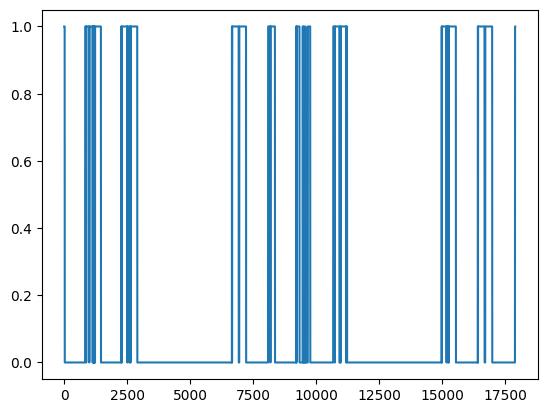

In [4]:
# visualize the data
df['Occupancy'].plot()
plt.show()

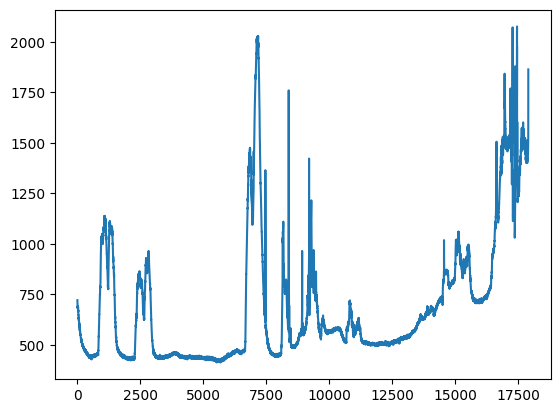

In [5]:
# visualize the data
df['CO2'].plot()
plt.show()

In [6]:
# drop the date column
df.drop(['date'], inplace=True, axis=1)
print(df.shape)
df.head()

(17895, 6)


,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
0,23.18,27.2720,426.0,721.25,0.004793,1
1,23.15,27.2675,429.5,714.00,0.004783,1
2,23.15,27.2450,426.0,713.50,0.004779,1
3,23.15,27.2000,426.0,708.25,0.004772,1
4,23.10,27.2000,426.0,704.50,0.004757,1


In [7]:
# prep data for modeling (multivariate)
# link: https://machinelearningmastery.com/how-to-develop-lstm-models-for-time-series-forecasting/

from numpy import array

# split a multivariate sequence into samples
def split_sequences(sequences, n_steps):
	X, y = list(), list()
	for i in np.arange(len(sequences)): # be careful of this line!
		# find the end of this pattern
		end_ix = i + n_steps
		# check if we are beyond the dataset
		if end_ix > len(sequences):
			break
		# gather input and output parts of the pattern
		seq_x, seq_y = sequences[i:end_ix, :-1], sequences[end_ix-1, -1]
		X.append(seq_x)
		y.append(seq_y)
	return np.array(X), np.array(y)

In [8]:
# we could split our data first, normalize it, then create sequences

In [9]:
# all we need to do is decide on is n_steps (what our lookback period is)
# since we have a bunch of data, why not n_steps=10? then try 30 later on.
n_steps = 50
raw_seq = np.array(df) #make sure your data is stored as a numpy array!
# let's ignore the date column and just use the temperature data
X, y = split_sequences(raw_seq, n_steps=50)

In [10]:
# take a peak at what it did
print(X.shape)
print(y.shape)

# scroll up and make sure you understand this!
# y is a function of X (the previous n_steps observations!)

(17846, 50, 5)
(17846,)


In [11]:
# split the data into train and test partitions
# we will use 50% of the data for train, and 50% for validation
train_pct_index = int(0.5 * len(X))
X_train, X_test = X[:train_pct_index], X[train_pct_index:]
y_train, y_test = y[:train_pct_index], y[train_pct_index:]

# pretty slick way of splitting your data using slicing!
# notice how we didn't do any shuffling (we don't want temporal leakage! keeps time series intact)

In [12]:
# check the shape to be sure
print(X.shape, X_train.shape, X_test.shape)
print(y.shape, y_train.shape, y_test.shape)

# verify that this all adds up!
# 2635 samples with 30 lookback and 6 columns

(17846, 50, 5) (8923, 50, 5) (8923, 50, 5)
(17846,) (8923,) (8923,)


# RNN one layer model (with Conv1D and pooling!)
With Conv1D and MaxPooling1D... don't forget that input shape needs to go in the first layer!

In [13]:
n_steps = X_train.shape[1] # lookback
n_features = X_train.shape[2] # columns

print(n_steps, n_features)

50 5


In [14]:
# now let's build a model

# define
n_steps = X_train.shape[1]
n_features = X_train.shape[2]


# define model
model = Sequential()
model.add(Conv1D(filters=32, kernel_size=3, input_shape=(n_steps,n_features))) # notice how input shape goes in first layer
model.add(MaxPooling1D(2))
model.add(SimpleRNN(30, activation='relu', recurrent_dropout=0.2))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy',metrics=['acc'])
model.summary()

es = EarlyStopping(monitor='val_acc', mode='max',
                   patience=10,
                   verbose=1,
                   restore_best_weights=True)

# fit model (uses early stopping)
model.fit(X_train, y_train,
          epochs=500,
          batch_size=64,
          validation_split=0.2, # val is a random 20% of the data since we set shuffle = True
          verbose=1,
          callbacks=[es],
          shuffle=True)

C:\Users\dww05002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 48, 32)         │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 30)             │         1,890 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,433 (9.50 KB)

 Trainable params: 2,433 (9.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 12:29 7s/step - acc: 0.4531 - loss: 51.5475

  6/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - acc: 0.5443 - loss: 28.6703 

 11/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - acc: 0.6534 - loss: 22.2333

 16/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - acc: 0.6768 - loss: 18.5173

 22/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.7223 - loss: 14.4937

 26/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.7452 - loss: 12.8871

 31/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.7666 - loss: 11.6747

 37/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.7829 - loss: 10.5202

 42/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.7932 - loss: 9.7593 

 46/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.7996 - loss: 9.2668

 51/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.8091 - loss: 8.5377

 56/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.8145 - loss: 8.0392

 62/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.8241 - loss: 7.4139

 67/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.8307 - loss: 6.9699

 71/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.8349 - loss: 6.6725

 75/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.8367 - loss: 6.4532

 79/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.8398 - loss: 6.1827

 84/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.8421 - loss: 5.9125

 90/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.8446 - loss: 5.6215

 96/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.8478 - loss: 5.3566

102/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.8516 - loss: 5.1202

107/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.8541 - loss: 4.9351

112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - acc: 0.8563 - loss: 4.7882 - val_acc: 0.9938 - val_loss: 0.1418


Epoch 2/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - acc: 0.8906 - loss: 0.9659

  7/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9308 - loss: 0.6697 

 13/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9291 - loss: 0.7062

 18/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9184 - loss: 0.7410

 24/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9219 - loss: 0.7387

 30/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9208 - loss: 0.7048

 36/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9206 - loss: 0.7483

 42/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9219 - loss: 0.7202

 49/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9247 - loss: 0.6729

 56/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9286 - loss: 0.6317

 63/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9311 - loss: 0.5865

 70/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9335 - loss: 0.5759

 78/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9345 - loss: 0.5541

 86/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9370 - loss: 0.5407

 93/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9377 - loss: 0.5203

100/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9391 - loss: 0.5123

107/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9381 - loss: 0.5137

112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - acc: 0.9392 - loss: 0.5013 - val_acc: 0.9782 - val_loss: 0.1788


Epoch 3/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - acc: 0.9219 - loss: 0.5617

  8/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9629 - loss: 0.3279 

 15/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9594 - loss: 0.3261

 22/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9638 - loss: 0.3012

 29/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9612 - loss: 0.3152

 37/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9557 - loss: 0.3794

 45/112 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9552 - loss: 0.4312

 53/112 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9578 - loss: 0.4093

 61/112 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9577 - loss: 0.3878

 69/112 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9604 - loss: 0.3634

 77/112 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9600 - loss: 0.3494

 85/112 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9607 - loss: 0.3373

 93/112 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9612 - loss: 0.3258

101/112 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9612 - loss: 0.3233

109/112 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9607 - loss: 0.3169

112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - acc: 0.9608 - loss: 0.3140 - val_acc: 0.9557 - val_loss: 0.2104


Epoch 4/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - acc: 0.9531 - loss: 0.4281

  7/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9732 - loss: 0.2116 

 14/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9754 - loss: 0.2154

 21/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9702 - loss: 0.1877

 28/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9637 - loss: 0.2666

 34/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9577 - loss: 0.3278

 41/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9585 - loss: 0.3462

 48/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9606 - loss: 0.3204

 54/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9621 - loss: 0.3058

 60/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9633 - loss: 0.2841

 67/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9639 - loss: 0.2749

 73/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9636 - loss: 0.2746

 79/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9636 - loss: 0.2778

 85/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9640 - loss: 0.2672

 90/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9644 - loss: 0.2591

 96/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9650 - loss: 0.2539

101/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9646 - loss: 0.2512

107/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9642 - loss: 0.2681

112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - acc: 0.9632 - loss: 0.2697 - val_acc: 0.9664 - val_loss: 0.1846


Epoch 5/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - acc: 0.9844 - loss: 0.1017

  7/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9799 - loss: 0.1875 

 14/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9710 - loss: 0.1744

 20/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9688 - loss: 0.1530

 27/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9716 - loss: 0.1655

 33/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9683 - loss: 0.1691

 39/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9655 - loss: 0.2048

 44/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9624 - loss: 0.2258

 50/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9634 - loss: 0.2265

 55/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9645 - loss: 0.2206

 61/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9657 - loss: 0.2118

 67/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9664 - loss: 0.2047

 73/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9666 - loss: 0.2028

 79/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9666 - loss: 0.2025

 85/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9656 - loss: 0.1966

 93/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9659 - loss: 0.1932

101/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9647 - loss: 0.2041

108/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9653 - loss: 0.2068

112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - acc: 0.9653 - loss: 0.2060 - val_acc: 0.9339 - val_loss: 0.2304


Epoch 6/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - acc: 0.9375 - loss: 0.1237

  9/112 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9809 - loss: 0.1282 

 16/112 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9697 - loss: 0.1681

 23/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9728 - loss: 0.1615

 30/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9703 - loss: 0.1705

 37/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9700 - loss: 0.1929

 45/112 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9677 - loss: 0.1922

 53/112 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9699 - loss: 0.1728

 61/112 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9718 - loss: 0.1593

 69/112 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9728 - loss: 0.1575

 77/112 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9708 - loss: 0.1623

 86/112 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9688 - loss: 0.1670

 95/112 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9678 - loss: 0.1740

104/112 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9672 - loss: 0.1759

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9661 - loss: 0.1799

112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - acc: 0.9661 - loss: 0.1799 - val_acc: 0.9899 - val_loss: 0.0839


Epoch 7/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - acc: 0.9844 - loss: 0.1687

  9/112 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9809 - loss: 0.1505 

 18/112 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9714 - loss: 0.1678

 27/112 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9757 - loss: 0.1505

 36/112 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9735 - loss: 0.1638

 45/112 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9726 - loss: 0.1582

 54/112 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9745 - loss: 0.1515

 63/112 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9764 - loss: 0.1372

 70/112 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9757 - loss: 0.1424

 77/112 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9740 - loss: 0.1500

 84/112 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9736 - loss: 0.1517

 92/112 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9727 - loss: 0.1541

100/112 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9725 - loss: 0.1540

107/112 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9714 - loss: 0.1606

112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - acc: 0.9717 - loss: 0.1594 - val_acc: 0.9798 - val_loss: 0.1020


Epoch 8/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - acc: 0.9688 - loss: 0.1452

  9/112 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9705 - loss: 0.1150 

 17/112 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9651 - loss: 0.1656

 24/112 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9655 - loss: 0.1764

 31/112 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9647 - loss: 0.1638

 38/112 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9655 - loss: 0.1892

 44/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9670 - loss: 0.1775

 49/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9691 - loss: 0.1624

 53/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9708 - loss: 0.1606

 59/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9719 - loss: 0.1549

 64/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9731 - loss: 0.1478

 69/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9733 - loss: 0.1534

 75/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9723 - loss: 0.1549

 83/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9731 - loss: 0.1503

 90/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9741 - loss: 0.1449

 97/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9742 - loss: 0.1442

104/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9743 - loss: 0.1421

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9742 - loss: 0.1412

112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - acc: 0.9742 - loss: 0.1412 - val_acc: 0.9944 - val_loss: 0.0513


Epoch 9/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 18s 163ms/step - acc: 0.9844 - loss: 0.1298

  7/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9732 - loss: 0.1491   

 13/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9748 - loss: 0.1531

 20/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9703 - loss: 0.1511

 27/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9693 - loss: 0.1802

 34/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9642 - loss: 0.1946

 41/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9649 - loss: 0.2056

 48/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9658 - loss: 0.1949

 55/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9679 - loss: 0.1840

 62/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9698 - loss: 0.1679

 70/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9701 - loss: 0.1667

 77/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9692 - loss: 0.1680

 83/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9689 - loss: 0.1718

 90/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9682 - loss: 0.1660

 97/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9681 - loss: 0.1656

104/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9675 - loss: 0.1672

111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9671 - loss: 0.1698

112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - acc: 0.9669 - loss: 0.1719 - val_acc: 0.9966 - val_loss: 0.0456


Epoch 10/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - acc: 0.9688 - loss: 0.2009

  7/112 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - acc: 0.9844 - loss: 0.1065

 14/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9799 - loss: 0.1474 

 20/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9797 - loss: 0.1295

 27/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9751 - loss: 0.1556

 33/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9706 - loss: 0.1546

 39/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9683 - loss: 0.1788

 46/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9671 - loss: 0.1776

 52/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9688 - loss: 0.1627

 58/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9704 - loss: 0.1548

 65/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9721 - loss: 0.1420

 72/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9727 - loss: 0.1393

 78/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9728 - loss: 0.1432

 85/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9732 - loss: 0.1437

 91/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9736 - loss: 0.1387

 97/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9723 - loss: 0.1414

103/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9727 - loss: 0.1461

109/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9710 - loss: 0.1492

112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - acc: 0.9711 - loss: 0.1491 - val_acc: 0.9944 - val_loss: 0.0968


Epoch 11/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 2:24 1s/step - acc: 0.9375 - loss: 0.3865

  6/112 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - acc: 0.9792 - loss: 0.1531

 11/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - acc: 0.9744 - loss: 0.1409

 17/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9752 - loss: 0.1527

 22/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.9751 - loss: 0.1403

 28/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9749 - loss: 0.1355

 34/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9729 - loss: 0.1399

 39/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9736 - loss: 0.1433

 43/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9717 - loss: 0.1440

 49/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.9710 - loss: 0.1392

 54/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.9722 - loss: 0.1355

 60/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.9729 - loss: 0.1291

 66/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.9747 - loss: 0.1222

 72/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9742 - loss: 0.1202

 78/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9746 - loss: 0.1205

 84/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9734 - loss: 0.1227

 89/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9728 - loss: 0.1194

 93/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9731 - loss: 0.1194

 98/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9723 - loss: 0.1217

104/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9722 - loss: 0.1288

110/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9702 - loss: 0.1334

112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - acc: 0.9702 - loss: 0.1346 - val_acc: 0.9961 - val_loss: 0.0657


Epoch 12/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - acc: 0.9531 - loss: 0.2704

 10/112 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9688 - loss: 0.1261 

 19/112 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9696 - loss: 0.1428

 28/112 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9743 - loss: 0.1283

 37/112 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9721 - loss: 0.1471

 46/112 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9711 - loss: 0.1454

 55/112 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9736 - loss: 0.1365

 64/112 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9749 - loss: 0.1240

 71/112 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9754 - loss: 0.1225

 78/112 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9754 - loss: 0.1235

 85/112 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9752 - loss: 0.1225

 92/112 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9755 - loss: 0.1197

100/112 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9753 - loss: 0.1224

108/112 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9740 - loss: 0.1263

112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - acc: 0.9744 - loss: 0.1259 - val_acc: 0.9944 - val_loss: 0.0662


Epoch 13/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - acc: 0.9688 - loss: 0.2239

 10/112 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9859 - loss: 0.0920 

 17/112 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9761 - loss: 0.1078

 24/112 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9772 - loss: 0.1125

 31/112 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9743 - loss: 0.1107

 38/112 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9741 - loss: 0.1312

 45/112 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9729 - loss: 0.1303

 52/112 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9748 - loss: 0.1213

 58/112 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9752 - loss: 0.1172

 64/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9763 - loss: 0.1128

 70/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9768 - loss: 0.1132

 76/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9762 - loss: 0.1161

 82/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9764 - loss: 0.1180

 89/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9759 - loss: 0.1134

 96/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9759 - loss: 0.1157

104/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9755 - loss: 0.1191

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9744 - loss: 0.1222

112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - acc: 0.9744 - loss: 0.1222 - val_acc: 0.9944 - val_loss: 0.0598


Epoch 14/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - acc: 0.9531 - loss: 0.3257

  8/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9688 - loss: 0.1484 

 15/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9729 - loss: 0.1473

 22/112 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9730 - loss: 0.1350

 28/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9732 - loss: 0.1415

 34/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9710 - loss: 0.1461

 40/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9719 - loss: 0.1474

 45/112 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.9726 - loss: 0.1417

 50/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9747 - loss: 0.1329

 54/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9760 - loss: 0.1262

 59/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9764 - loss: 0.1181

 64/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9773 - loss: 0.1116

 69/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9769 - loss: 0.1125

 75/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9762 - loss: 0.1137 

 81/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9772 - loss: 0.1120

 86/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9773 - loss: 0.1095

 91/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9775 - loss: 0.1094

 96/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9775 - loss: 0.1112

102/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9770 - loss: 0.1120

108/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9760 - loss: 0.1152

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9760 - loss: 0.1151

112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - acc: 0.9760 - loss: 0.1151 - val_acc: 0.9938 - val_loss: 0.0594


Epoch 15/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 8s 74ms/step - acc: 0.9688 - loss: 0.2331

  7/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9844 - loss: 0.1191 

 13/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9796 - loss: 0.1146

 19/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9803 - loss: 0.1059

 24/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9811 - loss: 0.1074

 30/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9792 - loss: 0.0999 

 36/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9792 - loss: 0.1098

 41/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9779 - loss: 0.1108

 46/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9776 - loss: 0.1066

 51/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9779 - loss: 0.1041

 55/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9781 - loss: 0.1003

 60/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9786 - loss: 0.0970

 65/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9796 - loss: 0.0920

 71/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9793 - loss: 0.0924

 75/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9783 - loss: 0.0953

 81/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9786 - loss: 0.0945

 86/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9784 - loss: 0.0943

 92/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9791 - loss: 0.0916

 96/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9790 - loss: 0.0923

101/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9788 - loss: 0.0931

106/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9777 - loss: 0.0986

111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9773 - loss: 0.0970

112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - acc: 0.9773 - loss: 0.0984 - val_acc: 0.9950 - val_loss: 0.0406


Epoch 16/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 2:02 1s/step - acc: 0.9844 - loss: 0.1828

  6/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - acc: 0.9844 - loss: 0.1231

 11/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - acc: 0.9830 - loss: 0.0971

 16/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - acc: 0.9795 - loss: 0.1124

 22/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.9751 - loss: 0.1196

 28/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.9727 - loss: 0.1361

 34/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9701 - loss: 0.1398

 40/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9695 - loss: 0.1450

 47/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9701 - loss: 0.1358

 54/112 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9731 - loss: 0.1236 

 59/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9743 - loss: 0.1162

 64/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9751 - loss: 0.1114

 68/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9754 - loss: 0.1114

 72/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9753 - loss: 0.1096

 77/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9756 - loss: 0.1118

 83/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9759 - loss: 0.1100

 90/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9762 - loss: 0.1060

 95/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9762 - loss: 0.1087

 99/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9766 - loss: 0.1056

104/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9763 - loss: 0.1086

109/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9751 - loss: 0.1117

112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - acc: 0.9755 - loss: 0.1107 - val_acc: 0.9961 - val_loss: 0.0347


Epoch 17/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - acc: 0.9844 - loss: 0.1158

  6/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - acc: 0.9844 - loss: 0.0872

 11/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - acc: 0.9830 - loss: 0.0753

 15/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - acc: 0.9792 - loss: 0.0980

 19/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - acc: 0.9778 - loss: 0.0923

 24/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - acc: 0.9746 - loss: 0.1070

 29/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - acc: 0.9736 - loss: 0.1048

 33/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9749 - loss: 0.0966

 39/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9748 - loss: 0.1120

 46/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.9728 - loss: 0.1123

 53/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.9752 - loss: 0.1058

 59/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.9762 - loss: 0.1014

 64/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.9766 - loss: 0.0960

 68/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.9766 - loss: 0.0992

 74/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.9759 - loss: 0.0997

 80/112 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.9762 - loss: 0.1033

 85/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.9759 - loss: 0.1030

 90/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.9764 - loss: 0.1012

 94/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.9759 - loss: 0.1059

 98/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.9756 - loss: 0.1057

102/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.9755 - loss: 0.1072

105/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.9753 - loss: 0.1083

109/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.9748 - loss: 0.1086

112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - acc: 0.9752 - loss: 0.1078 - val_acc: 0.9961 - val_loss: 0.0303


Epoch 18/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 1:37 875ms/step - acc: 0.9688 - loss: 0.1571

  6/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - acc: 0.9818 - loss: 0.1064   

 11/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - acc: 0.9844 - loss: 0.0865

 15/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - acc: 0.9792 - loss: 0.1136

 19/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - acc: 0.9794 - loss: 0.1061

 24/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - acc: 0.9779 - loss: 0.1144

 29/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - acc: 0.9774 - loss: 0.1150

 33/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9773 - loss: 0.1109

 37/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9751 - loss: 0.1310

 42/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9728 - loss: 0.1352

 47/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9737 - loss: 0.1301

 52/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9757 - loss: 0.1209

 58/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9758 - loss: 0.1155

 64/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9775 - loss: 0.1078

 70/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.9779 - loss: 0.1077

 77/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.9775 - loss: 0.1080

 83/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.9780 - loss: 0.1069

 89/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.9781 - loss: 0.1024

 95/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.9778 - loss: 0.1039

101/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.9776 - loss: 0.1025

107/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.9763 - loss: 0.1061

111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.9768 - loss: 0.1037

112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - acc: 0.9767 - loss: 0.1050 - val_acc: 0.9955 - val_loss: 0.0378


Epoch 19/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 2:04 1s/step - acc: 0.9688 - loss: 0.1410

  6/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - acc: 0.9818 - loss: 0.1052

 10/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - acc: 0.9781 - loss: 0.0876

 14/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - acc: 0.9777 - loss: 0.1186

 18/112 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - acc: 0.9748 - loss: 0.1104

 23/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - acc: 0.9755 - loss: 0.1131

 28/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - acc: 0.9727 - loss: 0.1194

 33/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9740 - loss: 0.1119

 38/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9737 - loss: 0.1272

 43/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9724 - loss: 0.1215

 48/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9740 - loss: 0.1163

 51/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9752 - loss: 0.1124

 56/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9760 - loss: 0.1120

 60/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9766 - loss: 0.1071

 65/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9769 - loss: 0.1025

 70/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9770 - loss: 0.1045

 76/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9766 - loss: 0.1041

 81/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9770 - loss: 0.1048

 87/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9765 - loss: 0.1043

 91/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9766 - loss: 0.1038

 96/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9766 - loss: 0.1054

100/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9762 - loss: 0.1041

104/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9763 - loss: 0.1054

108/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9751 - loss: 0.1082

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9752 - loss: 0.1081

112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - acc: 0.9752 - loss: 0.1081 - val_acc: 0.9938 - val_loss: 0.0480


Epoch 19: early stopping


Restoring model weights from the end of the best epoch: 9.


In [15]:
# show scatterplots of actual vs. predicted for train and test
# make a prediction
pred = model.predict(X_test)# the pred
print(pred) # round them!

pred = np.round(pred,0)
pred # run all if you get an error...

  1/279 ━━━━━━━━━━━━━━━━━━━━ 3:31 760ms/step

 12/279 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step    

 22/279 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

 33/279 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

 42/279 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

 54/279 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

 66/279 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

 76/279 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

 88/279 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

100/279 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

109/279 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

119/279 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

127/279 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

134/279 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

143/279 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

152/279 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

159/279 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

167/279 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

177/279 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

183/279 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

193/279 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

204/279 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

214/279 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

226/279 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

239/279 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

252/279 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

263/279 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

274/279 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

279/279 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

279/279 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


[[1.9347812e-11]
 [2.1251240e-11]
 [3.5617377e-11]
 ...
 [1.0000000e+00]
 [1.0000000e+00]
 [1.0000000e+00]]


array([[0.],
       [0.],
       [0.],
       ...,
       [1.],
       [1.],
       [1.]], shape=(8923, 1), dtype=float32)

In [16]:
# confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
print(confusion_matrix(y_test, pred)) # looks pretty good!
print(classification_report(y_test, pred))

[[6879  209]
 [  21 1814]]
              precision    recall  f1-score   support

         0.0       1.00      0.97      0.98      7088
         1.0       0.90      0.99      0.94      1835

    accuracy                           0.97      8923
   macro avg       0.95      0.98      0.96      8923
weighted avg       0.98      0.97      0.97      8923



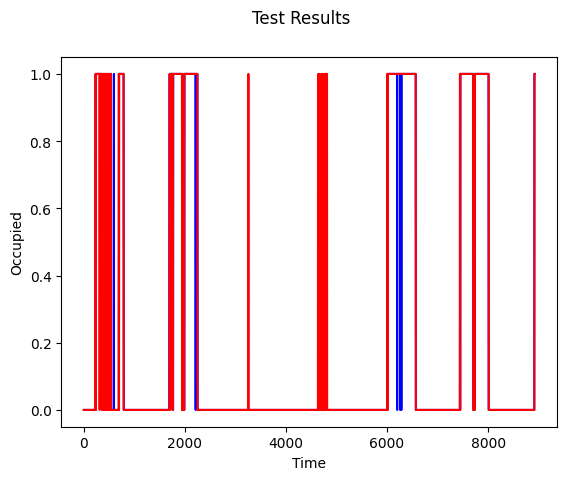

In [17]:
# show timeseries plot on the train and validation data
plt.plot(np.arange(X_test.shape[0]), y_test, color='blue') # actual data
plt.plot(np.arange(X_test.shape[0]), pred, color='red') # predicted data
plt.suptitle('Test Results')
plt.xlabel('Time')
plt.ylabel('Occupied')
plt.show()

  1/279 ━━━━━━━━━━━━━━━━━━━━ 33s 122ms/step

  6/279 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step  

 14/279 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step 

 25/279 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

 36/279 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

 50/279 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

 61/279 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

 72/279 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

 83/279 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

 94/279 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

108/279 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

121/279 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

136/279 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

148/279 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

159/279 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

171/279 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

182/279 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

192/279 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

201/279 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

210/279 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

219/279 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

226/279 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

234/279 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

243/279 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

253/279 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

264/279 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

275/279 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

279/279 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


[[1.9347812e-11]
 [2.1251240e-11]
 [3.5617377e-11]
 ...
 [1.0000000e+00]
 [1.0000000e+00]
 [1.0000000e+00]]
[[0.]
 [0.]
 [0.]
 ...
 [1.]
 [1.]
 [1.]]
[[6879  209]
 [  21 1814]]
              precision    recall  f1-score   support

         0.0       1.00      0.97      0.98      7088
         1.0       0.90      0.99      0.94      1835

    accuracy                           0.97      8923
   macro avg       0.95      0.98      0.96      8923
weighted avg       0.98      0.97      0.97      8923



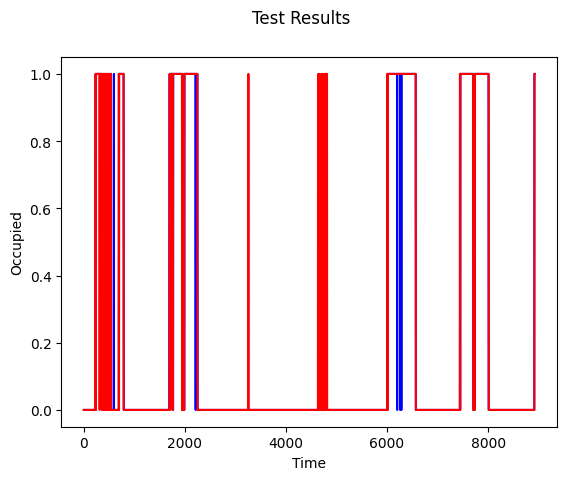

In [18]:
# put it all together for other models

# make a prediction
pred = model.predict(X_test)# the pred
print(pred) # round them!

pred = np.round(pred,0)
print(pred) # run all if you get an error...

# confusion matrix - put this at the top!
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
print(confusion_matrix(y_test, pred)) # looks pretty good!
print(classification_report(y_test, pred))

# show timeseries plot on the train and validation data
plt.plot(np.arange(X_test.shape[0]), y_test, color='blue') # actual data
plt.plot(np.arange(X_test.shape[0]), pred, color='red') # predicted data
plt.suptitle('Test Results')
plt.xlabel('Time')
plt.ylabel('Occupied')
plt.show()

# RNN two layer model
Don't forget to set return_sequences=True!

In [19]:
# now let's build a model

# define
n_steps = X_train.shape[1]
n_features = X_train.shape[2]


# define model
model = Sequential()
model.add(Conv1D(filters=32, kernel_size=3, input_shape=(n_steps,n_features))) # notice how input shape goes in first layer
model.add(MaxPooling1D(2))
model.add(Bidirectional(SimpleRNN(30, return_sequences=True, recurrent_dropout=0.2))) # don't forget to return_sequences!
model.add(Bidirectional(SimpleRNN(30, recurrent_dropout=0.2)))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy',metrics=['acc'])
model.summary()

es = EarlyStopping(monitor='val_acc', mode='max',
                   patience=10,
                   verbose=1,
                   restore_best_weights=True)

# fit model (uses early stopping)
model.fit(X_train, y_train,
          epochs=500,
          batch_size=64,
          validation_split=0.2, # val is a random 20% of the data since we set shuffle = True
          verbose=1,
          callbacks=[es],
          shuffle=True)

C:\Users\dww05002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 48, 32)         │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 24, 60)         │         3,780 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 60)             │         5,460 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            61 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,813 (38.33 KB)

 Trainable params: 9,813 (38.33 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 37:57 21s/step - acc: 0.5938 - loss: 0.6534

  4/112 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - acc: 0.7773 - loss: 0.4876  

  7/112 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - acc: 0.8058 - loss: 0.4279

 10/112 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - acc: 0.8234 - loss: 0.3905

 13/112 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - acc: 0.8269 - loss: 0.3671

 15/112 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - acc: 0.8323 - loss: 0.3559

 17/112 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - acc: 0.8419 - loss: 0.3389

 19/112 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - acc: 0.8512 - loss: 0.3253

 21/112 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - acc: 0.8564 - loss: 0.3125

 24/112 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - acc: 0.8613 - loss: 0.3077

 27/112 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - acc: 0.8652 - loss: 0.2986

 30/112 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - acc: 0.8667 - loss: 0.2926

 33/112 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - acc: 0.8693 - loss: 0.2897

 36/112 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - acc: 0.8702 - loss: 0.2857

 39/112 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - acc: 0.8714 - loss: 0.2814

 42/112 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - acc: 0.8735 - loss: 0.2766

 45/112 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - acc: 0.8747 - loss: 0.2756

 48/112 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - acc: 0.8763 - loss: 0.2708

 51/112 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - acc: 0.8784 - loss: 0.2668

 54/112 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - acc: 0.8805 - loss: 0.2638

 57/112 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - acc: 0.8829 - loss: 0.2590

 59/112 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - acc: 0.8837 - loss: 0.2573

 61/112 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - acc: 0.8847 - loss: 0.2570

 64/112 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - acc: 0.8865 - loss: 0.2522

 66/112 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - acc: 0.8873 - loss: 0.2501

 69/112 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - acc: 0.8888 - loss: 0.2471

 72/112 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - acc: 0.8904 - loss: 0.2441

 75/112 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - acc: 0.8915 - loss: 0.2421

 78/112 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - acc: 0.8930 - loss: 0.2389

 81/112 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - acc: 0.8935 - loss: 0.2377

 84/112 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - acc: 0.8943 - loss: 0.2365

 87/112 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - acc: 0.8958 - loss: 0.2334

 90/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.8969 - loss: 0.2320

 93/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.8980 - loss: 0.2295

 96/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9004 - loss: 0.2259

 98/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9019 - loss: 0.2240

100/112 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - acc: 0.9030 - loss: 0.2220

103/112 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - acc: 0.9037 - loss: 0.2216

105/112 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - acc: 0.9049 - loss: 0.2191

107/112 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - acc: 0.9054 - loss: 0.2180

109/112 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - acc: 0.9065 - loss: 0.2160

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - acc: 0.9059 - loss: 0.2173

112/112 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - acc: 0.9059 - loss: 0.2173 - val_acc: 0.9608 - val_loss: 0.0665


Epoch 2/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - acc: 0.8750 - loss: 0.2518

  4/112 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - acc: 0.9141 - loss: 0.1898

  7/112 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - acc: 0.9129 - loss: 0.2095

 10/112 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - acc: 0.9172 - loss: 0.1977

 13/112 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - acc: 0.9123 - loss: 0.2066

 16/112 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - acc: 0.9072 - loss: 0.2126

 19/112 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - acc: 0.9128 - loss: 0.2067

 22/112 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - acc: 0.9162 - loss: 0.1957

 24/112 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9173 - loss: 0.1949

 26/112 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9189 - loss: 0.1877

 29/112 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9170 - loss: 0.1890

 31/112 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9178 - loss: 0.1886

 34/112 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9182 - loss: 0.1928

 37/112 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9193 - loss: 0.1888

 40/112 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9180 - loss: 0.1883

 43/112 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9201 - loss: 0.1845

 46/112 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9226 - loss: 0.1813

 49/112 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9238 - loss: 0.1795

 52/112 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9258 - loss: 0.1755

 55/112 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9276 - loss: 0.1723

 58/112 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9297 - loss: 0.1678

 61/112 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9303 - loss: 0.1666

 64/112 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9319 - loss: 0.1628

 67/112 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.9328 - loss: 0.1611

 70/112 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.9339 - loss: 0.1579

 73/112 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.9354 - loss: 0.1559

 76/112 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.9365 - loss: 0.1538

 78/112 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.9375 - loss: 0.1519

 81/112 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.9385 - loss: 0.1499

 84/112 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.9392 - loss: 0.1484

 87/112 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.9407 - loss: 0.1456

 90/112 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.9410 - loss: 0.1456

 93/112 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.9424 - loss: 0.1433

 96/112 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.9430 - loss: 0.1427

 99/112 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.9440 - loss: 0.1410

102/112 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.9441 - loss: 0.1417

105/112 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.9445 - loss: 0.1410

108/112 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.9452 - loss: 0.1406

111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.9461 - loss: 0.1383

112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - acc: 0.9461 - loss: 0.1387 - val_acc: 0.9720 - val_loss: 0.0654


Epoch 3/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - acc: 0.9844 - loss: 0.0676

  3/112 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - acc: 0.9844 - loss: 0.0627 

  6/112 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - acc: 0.9870 - loss: 0.0646

  8/112 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - acc: 0.9863 - loss: 0.0666

 11/112 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - acc: 0.9830 - loss: 0.0650

 14/112 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - acc: 0.9632 - loss: 0.1189

 16/112 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - acc: 0.9463 - loss: 0.1551

 19/112 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - acc: 0.9375 - loss: 0.1639

 22/112 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - acc: 0.9347 - loss: 0.1829

 24/112 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - acc: 0.9251 - loss: 0.2118

 27/112 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - acc: 0.9236 - loss: 0.2168

 30/112 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - acc: 0.9250 - loss: 0.2116

 33/112 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - acc: 0.9167 - loss: 0.2168

 34/112 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9168 - loss: 0.2168

 36/112 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.9175 - loss: 0.2137

 38/112 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.9186 - loss: 0.2116

 41/112 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.9219 - loss: 0.2039

 44/112 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.9205 - loss: 0.2087

 47/112 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.9215 - loss: 0.2050

 50/112 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.9231 - loss: 0.2001

 53/112 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9257 - loss: 0.1948

 55/112 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.9270 - loss: 0.1924

 58/112 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9294 - loss: 0.1867

 61/112 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9303 - loss: 0.1843

 63/112 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9318 - loss: 0.1805

 66/112 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9330 - loss: 0.1767

 69/112 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9339 - loss: 0.1741

 72/112 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - acc: 0.9347 - loss: 0.1715

 75/112 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - acc: 0.9352 - loss: 0.1694

 78/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9363 - loss: 0.1668

 80/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9367 - loss: 0.1657

 83/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9381 - loss: 0.1630

 86/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9397 - loss: 0.1601

 89/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9410 - loss: 0.1572

 92/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9423 - loss: 0.1551

 94/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9427 - loss: 0.1542

 97/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9422 - loss: 0.1542

 99/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9426 - loss: 0.1528

102/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9416 - loss: 0.1571

105/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9411 - loss: 0.1593

107/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9400 - loss: 0.1621

109/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9394 - loss: 0.1638

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9377 - loss: 0.1669

112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - acc: 0.9377 - loss: 0.1669 - val_acc: 0.9877 - val_loss: 0.0866


Epoch 4/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - acc: 0.7812 - loss: 0.3275

  4/112 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - acc: 0.8867 - loss: 0.1985

  6/112 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - acc: 0.8958 - loss: 0.1978

  9/112 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - acc: 0.9184 - loss: 0.1690

 12/112 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - acc: 0.9284 - loss: 0.1600

 15/112 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - acc: 0.9333 - loss: 0.1548

 18/112 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - acc: 0.9384 - loss: 0.1472

 21/112 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9464 - loss: 0.1346

 24/112 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9460 - loss: 0.1342

 27/112 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9462 - loss: 0.1304

 30/112 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9479 - loss: 0.1257

 32/112 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9473 - loss: 0.1308

 35/112 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9464 - loss: 0.1358

 37/112 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - acc: 0.9455 - loss: 0.1384

 40/112 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - acc: 0.9461 - loss: 0.1395

 43/112 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - acc: 0.9451 - loss: 0.1430

 45/112 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - acc: 0.9451 - loss: 0.1436

 47/112 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - acc: 0.9441 - loss: 0.1451

 50/112 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - acc: 0.9450 - loss: 0.1438

 53/112 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - acc: 0.9455 - loss: 0.1427

 55/112 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - acc: 0.9457 - loss: 0.1422

 58/112 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - acc: 0.9477 - loss: 0.1383

 61/112 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - acc: 0.9485 - loss: 0.1372

 64/112 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - acc: 0.9502 - loss: 0.1330

 67/112 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - acc: 0.9513 - loss: 0.1309

 70/112 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - acc: 0.9520 - loss: 0.1293

 73/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9529 - loss: 0.1267

 75/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9531 - loss: 0.1263

 78/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9545 - loss: 0.1236

 81/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9547 - loss: 0.1241

 83/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9546 - loss: 0.1242

 86/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9549 - loss: 0.1234

 89/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9558 - loss: 0.1221

 91/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9554 - loss: 0.1225

 93/112 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - acc: 0.9561 - loss: 0.1208

 95/112 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - acc: 0.9554 - loss: 0.1228

 97/112 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - acc: 0.9559 - loss: 0.1217

100/112 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - acc: 0.9558 - loss: 0.1230

102/112 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - acc: 0.9556 - loss: 0.1238

105/112 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - acc: 0.9558 - loss: 0.1238

108/112 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - acc: 0.9557 - loss: 0.1237

110/112 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - acc: 0.9560 - loss: 0.1234

112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - acc: 0.9559 - loss: 0.1247 - val_acc: 0.9188 - val_loss: 0.2030


Epoch 5/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 2:50 2s/step - acc: 0.9531 - loss: 0.1269

  4/112 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - acc: 0.9805 - loss: 0.0700

  6/112 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - acc: 0.9740 - loss: 0.0947

  9/112 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - acc: 0.9757 - loss: 0.0861

 12/112 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - acc: 0.9727 - loss: 0.0911

 15/112 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - acc: 0.9698 - loss: 0.1008

 16/112 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - acc: 0.9707 - loss: 0.1005

 18/112 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - acc: 0.9740 - loss: 0.0931

 21/112 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - acc: 0.9769 - loss: 0.0847

 23/112 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - acc: 0.9755 - loss: 0.0857

 25/112 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - acc: 0.9750 - loss: 0.0847

 28/112 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - acc: 0.9760 - loss: 0.0823

 31/112 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - acc: 0.9763 - loss: 0.0818

 33/112 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - acc: 0.9759 - loss: 0.0829

 36/112 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - acc: 0.9753 - loss: 0.0857

 38/112 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - acc: 0.9737 - loss: 0.0884

 39/112 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - acc: 0.9744 - loss: 0.0866

 41/112 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - acc: 0.9745 - loss: 0.0858

 44/112 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - acc: 0.9716 - loss: 0.0936

 46/112 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - acc: 0.9725 - loss: 0.0925

 48/112 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - acc: 0.9714 - loss: 0.0942

 49/112 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - acc: 0.9700 - loss: 0.0971

 50/112 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - acc: 0.9703 - loss: 0.0962

 52/112 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - acc: 0.9709 - loss: 0.0957

 54/112 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - acc: 0.9714 - loss: 0.0946

 57/112 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - acc: 0.9723 - loss: 0.0927

 59/112 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - acc: 0.9722 - loss: 0.0928

 62/112 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - acc: 0.9728 - loss: 0.0920

 64/112 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - acc: 0.9731 - loss: 0.0906

 65/112 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - acc: 0.9736 - loss: 0.0895

 67/112 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - acc: 0.9734 - loss: 0.0901

 69/112 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - acc: 0.9733 - loss: 0.0898

 72/112 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - acc: 0.9735 - loss: 0.0896

 75/112 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - acc: 0.9737 - loss: 0.0893

 77/112 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - acc: 0.9736 - loss: 0.0889

 79/112 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - acc: 0.9737 - loss: 0.0887

 80/112 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - acc: 0.9740 - loss: 0.0879

 82/112 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - acc: 0.9741 - loss: 0.0875

 85/112 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - acc: 0.9744 - loss: 0.0871

 88/112 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - acc: 0.9751 - loss: 0.0857

 91/112 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - acc: 0.9753 - loss: 0.0851

 94/112 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - acc: 0.9751 - loss: 0.0856

 96/112 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - acc: 0.9753 - loss: 0.0848

 99/112 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - acc: 0.9752 - loss: 0.0847

101/112 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - acc: 0.9749 - loss: 0.0846

103/112 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - acc: 0.9744 - loss: 0.0865

106/112 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - acc: 0.9745 - loss: 0.0860

109/112 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - acc: 0.9745 - loss: 0.0857

111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - acc: 0.9748 - loss: 0.0852

112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - acc: 0.9746 - loss: 0.0860 - val_acc: 0.9742 - val_loss: 0.1012


Epoch 6/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 14s 127ms/step - acc: 0.9688 - loss: 0.0962

  4/112 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - acc: 0.9766 - loss: 0.0754  

  7/112 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - acc: 0.9665 - loss: 0.1184

  9/112 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - acc: 0.9688 - loss: 0.1061

 12/112 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - acc: 0.9635 - loss: 0.1255

 15/112 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - acc: 0.9615 - loss: 0.1288

 17/112 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - acc: 0.9596 - loss: 0.1296

 19/112 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - acc: 0.9597 - loss: 0.1294

 22/112 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - acc: 0.9616 - loss: 0.1251

 25/112 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - acc: 0.9606 - loss: 0.1260

 26/112 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - acc: 0.9603 - loss: 0.1259

 29/112 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - acc: 0.9612 - loss: 0.1219

 32/112 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - acc: 0.9624 - loss: 0.1199

 34/112 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - acc: 0.9619 - loss: 0.1241

 36/112 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - acc: 0.9622 - loss: 0.1214

 38/112 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - acc: 0.9613 - loss: 0.1224

 40/112 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - acc: 0.9625 - loss: 0.1186

 42/112 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - acc: 0.9635 - loss: 0.1165

 44/112 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - acc: 0.9638 - loss: 0.1162

 47/112 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - acc: 0.9631 - loss: 0.1185

 50/112 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - acc: 0.9641 - loss: 0.1148

 52/112 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - acc: 0.9651 - loss: 0.1126

 54/112 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - acc: 0.9659 - loss: 0.1110

 57/112 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - acc: 0.9671 - loss: 0.1078

 59/112 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - acc: 0.9677 - loss: 0.1067

 62/112 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - acc: 0.9685 - loss: 0.1045

 65/112 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - acc: 0.9697 - loss: 0.1011

 68/112 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - acc: 0.9701 - loss: 0.0992

 70/112 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - acc: 0.9703 - loss: 0.0989

 72/112 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - acc: 0.9707 - loss: 0.0976

 75/112 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - acc: 0.9712 - loss: 0.0963

 78/112 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - acc: 0.9720 - loss: 0.0947

 80/112 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - acc: 0.9717 - loss: 0.0953

 82/112 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - acc: 0.9720 - loss: 0.0942

 85/112 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - acc: 0.9724 - loss: 0.0929

 87/112 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - acc: 0.9729 - loss: 0.0916

 90/112 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - acc: 0.9715 - loss: 0.0944

 93/112 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - acc: 0.9709 - loss: 0.0955

 96/112 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - acc: 0.9696 - loss: 0.0987

 99/112 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - acc: 0.9670 - loss: 0.1026

101/112 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - acc: 0.9657 - loss: 0.1050

103/112 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - acc: 0.9640 - loss: 0.1080

105/112 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - acc: 0.9641 - loss: 0.1082

107/112 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - acc: 0.9628 - loss: 0.1103

110/112 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - acc: 0.9615 - loss: 0.1126

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - acc: 0.9609 - loss: 0.1139

112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - acc: 0.9609 - loss: 0.1139 - val_acc: 0.9944 - val_loss: 0.0669


Epoch 7/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 13s 123ms/step - acc: 0.9062 - loss: 0.2039

  4/112 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - acc: 0.9492 - loss: 0.1431  

  7/112 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - acc: 0.9464 - loss: 0.1480

  8/112 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - acc: 0.9492 - loss: 0.1386

 11/112 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - acc: 0.9560 - loss: 0.1267

 13/112 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - acc: 0.9531 - loss: 0.1326

 16/112 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - acc: 0.9531 - loss: 0.1373

 18/112 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - acc: 0.9557 - loss: 0.1325

 20/112 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - acc: 0.9578 - loss: 0.1291

 22/112 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - acc: 0.9588 - loss: 0.1246

 24/112 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - acc: 0.9570 - loss: 0.1292

 27/112 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - acc: 0.9578 - loss: 0.1257

 30/112 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - acc: 0.9594 - loss: 0.1218

 33/112 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - acc: 0.9574 - loss: 0.1244

 35/112 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - acc: 0.9576 - loss: 0.1247

 37/112 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - acc: 0.9578 - loss: 0.1244

 38/112 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - acc: 0.9539 - loss: 0.1332

 41/112 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - acc: 0.9562 - loss: 0.1288

 42/112 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - acc: 0.9554 - loss: 0.1310

 45/112 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - acc: 0.9524 - loss: 0.1424

 48/112 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - acc: 0.9508 - loss: 0.1462

 51/112 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - acc: 0.9488 - loss: 0.1488

 53/112 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - acc: 0.9484 - loss: 0.1500

 56/112 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - acc: 0.9459 - loss: 0.1529

 58/112 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - acc: 0.9450 - loss: 0.1537

 61/112 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - acc: 0.9436 - loss: 0.1558

 63/112 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - acc: 0.9435 - loss: 0.1558

 66/112 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - acc: 0.9418 - loss: 0.1585

 69/112 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - acc: 0.9418 - loss: 0.1584

 70/112 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - acc: 0.9411 - loss: 0.1598

 72/112 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - acc: 0.9403 - loss: 0.1605

 73/112 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - acc: 0.9403 - loss: 0.1602

 75/112 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - acc: 0.9392 - loss: 0.1623

 78/112 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - acc: 0.9397 - loss: 0.1614

 81/112 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - acc: 0.9387 - loss: 0.1629

 83/112 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - acc: 0.9384 - loss: 0.1629

 85/112 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - acc: 0.9386 - loss: 0.1616

 86/112 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - acc: 0.9388 - loss: 0.1613

 89/112 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - acc: 0.9389 - loss: 0.1608

 91/112 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - acc: 0.9389 - loss: 0.1603

 93/112 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - acc: 0.9393 - loss: 0.1596

 95/112 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - acc: 0.9387 - loss: 0.1603

 96/112 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - acc: 0.9393 - loss: 0.1590

 99/112 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - acc: 0.9402 - loss: 0.1581

101/112 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - acc: 0.9406 - loss: 0.1579

103/112 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - acc: 0.9404 - loss: 0.1582

104/112 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - acc: 0.9410 - loss: 0.1571

106/112 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - acc: 0.9412 - loss: 0.1567

108/112 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - acc: 0.9408 - loss: 0.1575

111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - acc: 0.9412 - loss: 0.1567

112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - acc: 0.9413 - loss: 0.1563 - val_acc: 0.9810 - val_loss: 0.1028


Epoch 8/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 2:07 1s/step - acc: 0.9375 - loss: 0.1797

  4/112 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - acc: 0.9648 - loss: 0.1097

  6/112 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - acc: 0.9583 - loss: 0.1195

  9/112 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - acc: 0.9653 - loss: 0.1040

 12/112 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - acc: 0.9648 - loss: 0.1072

 15/112 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - acc: 0.9656 - loss: 0.1054

 16/112 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - acc: 0.9668 - loss: 0.1035

 19/112 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - acc: 0.9655 - loss: 0.1097

 22/112 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - acc: 0.9638 - loss: 0.1140

 25/112 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - acc: 0.9519 - loss: 0.1444

 27/112 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - acc: 0.9462 - loss: 0.1560

 29/112 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - acc: 0.9461 - loss: 0.1555

 32/112 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - acc: 0.9414 - loss: 0.1626

 34/112 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - acc: 0.9361 - loss: 0.1678

 36/112 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - acc: 0.9327 - loss: 0.1759

 39/112 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - acc: 0.9251 - loss: 0.1840

 41/112 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - acc: 0.9238 - loss: 0.1842

 43/112 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - acc: 0.9215 - loss: 0.1872

 45/112 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - acc: 0.9177 - loss: 0.1918

 47/112 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - acc: 0.9156 - loss: 0.1966

 50/112 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - acc: 0.9141 - loss: 0.1972

 53/112 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - acc: 0.9113 - loss: 0.2002

 56/112 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - acc: 0.9090 - loss: 0.2022

 57/112 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - acc: 0.9090 - loss: 0.2022

 59/112 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - acc: 0.9092 - loss: 0.2021

 61/112 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - acc: 0.9093 - loss: 0.2009

 64/112 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - acc: 0.9102 - loss: 0.1987

 66/112 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - acc: 0.9093 - loss: 0.2001

 68/112 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - acc: 0.9106 - loss: 0.1977

 70/112 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - acc: 0.9103 - loss: 0.1990

 73/112 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - acc: 0.9107 - loss: 0.1994

 74/112 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - acc: 0.9113 - loss: 0.1991

 77/112 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - acc: 0.9117 - loss: 0.1995

 79/112 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - acc: 0.9114 - loss: 0.1999

 82/112 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - acc: 0.9114 - loss: 0.2007

 85/112 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - acc: 0.9121 - loss: 0.1999

 88/112 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - acc: 0.9132 - loss: 0.1985

 90/112 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - acc: 0.9134 - loss: 0.1986

 93/112 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - acc: 0.9140 - loss: 0.1976

 96/112 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - acc: 0.9142 - loss: 0.1967

 99/112 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - acc: 0.9146 - loss: 0.1961

100/112 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - acc: 0.9147 - loss: 0.1964

103/112 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - acc: 0.9146 - loss: 0.1965

106/112 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - acc: 0.9155 - loss: 0.1948

109/112 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - acc: 0.9149 - loss: 0.1947

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - acc: 0.9150 - loss: 0.1951

112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - acc: 0.9150 - loss: 0.1951 - val_acc: 0.9955 - val_loss: 0.0556


Epoch 9/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 3:30 2s/step - acc: 0.9375 - loss: 0.1653

  4/112 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - acc: 0.9609 - loss: 0.1215

  6/112 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - acc: 0.9531 - loss: 0.1418

  9/112 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - acc: 0.9583 - loss: 0.1292

 11/112 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - acc: 0.9602 - loss: 0.1255

 13/112 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - acc: 0.9579 - loss: 0.1302

 15/112 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - acc: 0.9594 - loss: 0.1281

 17/112 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - acc: 0.9586 - loss: 0.1253

 20/112 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - acc: 0.9625 - loss: 0.1199

 22/112 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - acc: 0.9638 - loss: 0.1185

 25/112 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - acc: 0.9625 - loss: 0.1202

 28/112 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - acc: 0.9609 - loss: 0.1210

 30/112 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - acc: 0.9615 - loss: 0.1213

 33/112 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - acc: 0.9593 - loss: 0.1271

 35/112 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.9576 - loss: 0.1303

 37/112 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.9561 - loss: 0.1347

 40/112 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.9551 - loss: 0.1338

 43/112 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.9535 - loss: 0.1392

 46/112 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.9524 - loss: 0.1405

 49/112 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.9525 - loss: 0.1402

 52/112 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9528 - loss: 0.1397

 55/112 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9537 - loss: 0.1377

 58/112 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9547 - loss: 0.1344

 61/112 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9552 - loss: 0.1338

 64/112 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - acc: 0.9570 - loss: 0.1294

 67/112 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - acc: 0.9580 - loss: 0.1266

 70/112 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - acc: 0.9583 - loss: 0.1245

 73/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9589 - loss: 0.1232

 76/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9599 - loss: 0.1212

 79/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9595 - loss: 0.1220

 81/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9597 - loss: 0.1219

 83/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9593 - loss: 0.1224

 85/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9594 - loss: 0.1225

 88/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9597 - loss: 0.1221

 91/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9593 - loss: 0.1228

 93/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9595 - loss: 0.1229

 96/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9591 - loss: 0.1233

 99/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9593 - loss: 0.1231

102/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9588 - loss: 0.1238

105/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9591 - loss: 0.1233

107/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9587 - loss: 0.1231

109/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9590 - loss: 0.1222

111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9596 - loss: 0.1208

112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - acc: 0.9595 - loss: 0.1212 - val_acc: 0.9742 - val_loss: 0.1041


Epoch 10/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 8s 74ms/step - acc: 0.9844 - loss: 0.0984

  4/112 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - acc: 0.9922 - loss: 0.0593

  7/112 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - acc: 0.9821 - loss: 0.0856

 10/112 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - acc: 0.9844 - loss: 0.0788

 13/112 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - acc: 0.9772 - loss: 0.0857

 16/112 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - acc: 0.9785 - loss: 0.0813

 19/112 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9819 - loss: 0.0741

 21/112 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9836 - loss: 0.0692

 24/112 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9811 - loss: 0.0769

 27/112 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9815 - loss: 0.0739

 30/112 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9818 - loss: 0.0714

 33/112 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9815 - loss: 0.0726

 36/112 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9800 - loss: 0.0770

 38/112 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9782 - loss: 0.0796

 41/112 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9790 - loss: 0.0765

 43/112 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9786 - loss: 0.0775

 46/112 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9779 - loss: 0.0779

 49/112 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9777 - loss: 0.0772

 51/112 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9782 - loss: 0.0758

 53/112 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - acc: 0.9776 - loss: 0.0766

 56/112 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - acc: 0.9763 - loss: 0.0798

 58/112 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - acc: 0.9766 - loss: 0.0791

 61/112 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - acc: 0.9769 - loss: 0.0794

 64/112 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - acc: 0.9778 - loss: 0.0773

 67/112 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - acc: 0.9783 - loss: 0.0764

 70/112 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - acc: 0.9781 - loss: 0.0758

 73/112 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - acc: 0.9782 - loss: 0.0753

 75/112 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - acc: 0.9779 - loss: 0.0761

 77/112 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - acc: 0.9781 - loss: 0.0761

 80/112 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - acc: 0.9779 - loss: 0.0767

 83/112 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - acc: 0.9782 - loss: 0.0763

 86/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9787 - loss: 0.0749

 89/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9793 - loss: 0.0739

 92/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9793 - loss: 0.0735

 95/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9791 - loss: 0.0735

 98/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9794 - loss: 0.0728

101/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9796 - loss: 0.0722

104/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9796 - loss: 0.0726

107/112 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.9791 - loss: 0.0734

110/112 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.9795 - loss: 0.0723

112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - acc: 0.9795 - loss: 0.0723 - val_acc: 0.9765 - val_loss: 0.0952


Epoch 11/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - acc: 0.9844 - loss: 0.0621

  4/112 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - acc: 0.9922 - loss: 0.0430

  7/112 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - acc: 0.9888 - loss: 0.0547

 10/112 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - acc: 0.9891 - loss: 0.0526

 12/112 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - acc: 0.9883 - loss: 0.0512

 15/112 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - acc: 0.9854 - loss: 0.0583

 18/112 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - acc: 0.9870 - loss: 0.0540

 21/112 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - acc: 0.9888 - loss: 0.0487

 24/112 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - acc: 0.9850 - loss: 0.0571

 26/112 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - acc: 0.9856 - loss: 0.0554

 28/112 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9860 - loss: 0.0532

 31/112 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9859 - loss: 0.0534

 34/112 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9853 - loss: 0.0564

 36/112 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9839 - loss: 0.0594

 38/112 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9827 - loss: 0.0618

 40/112 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9832 - loss: 0.0598

 43/112 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9840 - loss: 0.0587

 46/112 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9844 - loss: 0.0575

 48/112 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9844 - loss: 0.0568

 51/112 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9844 - loss: 0.0558

 52/112 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - acc: 0.9832 - loss: 0.0583

 55/112 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - acc: 0.9824 - loss: 0.0597

 58/112 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9828 - loss: 0.0585

 61/112 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - acc: 0.9828 - loss: 0.0597

 64/112 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - acc: 0.9834 - loss: 0.0585

 67/112 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9830 - loss: 0.0605

 70/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9817 - loss: 0.0623

 73/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9818 - loss: 0.0636

 76/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9807 - loss: 0.0681

 79/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9802 - loss: 0.0688

 82/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9796 - loss: 0.0711

 85/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9783 - loss: 0.0736

 88/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9778 - loss: 0.0755

 91/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9770 - loss: 0.0779

 94/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9754 - loss: 0.0801

 97/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9747 - loss: 0.0820

100/112 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.9742 - loss: 0.0837

103/112 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.9733 - loss: 0.0860

106/112 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.9732 - loss: 0.0864

109/112 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.9720 - loss: 0.0885

112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - acc: 0.9717 - loss: 0.0896 - val_acc: 0.9944 - val_loss: 0.0421


Epoch 12/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - acc: 0.9531 - loss: 0.1367

  5/112 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - acc: 0.9781 - loss: 0.0864

  9/112 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - acc: 0.9826 - loss: 0.0782

 13/112 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - acc: 0.9808 - loss: 0.0774

 16/112 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - acc: 0.9805 - loss: 0.0779

 19/112 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - acc: 0.9836 - loss: 0.0690

 22/112 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - acc: 0.9837 - loss: 0.0694

 25/112 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - acc: 0.9825 - loss: 0.0716

 28/112 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - acc: 0.9833 - loss: 0.0676

 31/112 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - acc: 0.9819 - loss: 0.0697

 34/112 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - acc: 0.9793 - loss: 0.0739

 37/112 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - acc: 0.9785 - loss: 0.0742

 40/112 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - acc: 0.9777 - loss: 0.0751

 43/112 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - acc: 0.9778 - loss: 0.0762

 46/112 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - acc: 0.9776 - loss: 0.0763

 49/112 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - acc: 0.9770 - loss: 0.0770

 52/112 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - acc: 0.9763 - loss: 0.0797

 55/112 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - acc: 0.9756 - loss: 0.0809

 58/112 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - acc: 0.9755 - loss: 0.0812

 61/112 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - acc: 0.9746 - loss: 0.0839

 64/112 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - acc: 0.9749 - loss: 0.0834

 67/112 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - acc: 0.9748 - loss: 0.0838

 70/112 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - acc: 0.9752 - loss: 0.0833

 73/112 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - acc: 0.9758 - loss: 0.0829

 76/112 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - acc: 0.9762 - loss: 0.0827

 79/112 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - acc: 0.9763 - loss: 0.0826

 82/112 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - acc: 0.9760 - loss: 0.0831

 85/112 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - acc: 0.9759 - loss: 0.0832

 89/112 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - acc: 0.9768 - loss: 0.0807

 92/112 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - acc: 0.9769 - loss: 0.0802

 95/112 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - acc: 0.9766 - loss: 0.0802

 98/112 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - acc: 0.9770 - loss: 0.0790

101/112 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - acc: 0.9773 - loss: 0.0783

104/112 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - acc: 0.9772 - loss: 0.0782

107/112 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - acc: 0.9768 - loss: 0.0791

110/112 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - acc: 0.9770 - loss: 0.0779

112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - acc: 0.9770 - loss: 0.0776 - val_acc: 0.9143 - val_loss: 0.2585


Epoch 13/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 31s 281ms/step - acc: 0.9844 - loss: 0.0742

  4/112 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - acc: 0.9844 - loss: 0.0660  

  7/112 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - acc: 0.9866 - loss: 0.0678

 10/112 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - acc: 0.9875 - loss: 0.0617

 13/112 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - acc: 0.9808 - loss: 0.0777

 16/112 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - acc: 0.9766 - loss: 0.0868

 19/112 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - acc: 0.9786 - loss: 0.0830

 22/112 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - acc: 0.9780 - loss: 0.0833

 25/112 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - acc: 0.9756 - loss: 0.0886

 28/112 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - acc: 0.9743 - loss: 0.0892

 31/112 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - acc: 0.9728 - loss: 0.0920

 34/112 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - acc: 0.9724 - loss: 0.0949

 36/112 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - acc: 0.9727 - loss: 0.0949

 39/112 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9732 - loss: 0.0938

 42/112 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9728 - loss: 0.0936

 45/112 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9729 - loss: 0.0935

 47/112 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9721 - loss: 0.0940

 50/112 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9731 - loss: 0.0905

 52/112 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9733 - loss: 0.0898

 54/112 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9734 - loss: 0.0890

 57/112 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9737 - loss: 0.0874

 59/112 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9740 - loss: 0.0870

 61/112 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9739 - loss: 0.0870

 64/112 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9744 - loss: 0.0856

 67/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9743 - loss: 0.0860

 70/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9743 - loss: 0.0850

 73/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9747 - loss: 0.0842

 76/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9747 - loss: 0.0842

 79/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9739 - loss: 0.0857

 82/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9735 - loss: 0.0863

 85/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9739 - loss: 0.0853

 88/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9746 - loss: 0.0840

 91/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9746 - loss: 0.0838

 94/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9749 - loss: 0.0837

 97/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9750 - loss: 0.0832

100/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9745 - loss: 0.0844

103/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9739 - loss: 0.0856

106/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9741 - loss: 0.0854

109/112 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.9742 - loss: 0.0848

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.9744 - loss: 0.0841

112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - acc: 0.9744 - loss: 0.0841 - val_acc: 0.8913 - val_loss: 0.2961


Epoch 14/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - acc: 0.9844 - loss: 0.0756

  4/112 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - acc: 0.9805 - loss: 0.0609

  7/112 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - acc: 0.9844 - loss: 0.0685

 10/112 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - acc: 0.9859 - loss: 0.0616

 12/112 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - acc: 0.9805 - loss: 0.0759

 15/112 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - acc: 0.9771 - loss: 0.0854

 18/112 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9774 - loss: 0.0831

 21/112 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9807 - loss: 0.0746

 24/112 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9792 - loss: 0.0757

 27/112 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9803 - loss: 0.0712

 30/112 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9812 - loss: 0.0690

 32/112 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9810 - loss: 0.0698

 35/112 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9804 - loss: 0.0713

 38/112 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9794 - loss: 0.0726

 41/112 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9806 - loss: 0.0698

 44/112 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9798 - loss: 0.0702

 47/112 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9804 - loss: 0.0678

 50/112 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9812 - loss: 0.0660

 53/112 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9808 - loss: 0.0663

 56/112 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9813 - loss: 0.0650

 59/112 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9817 - loss: 0.0649

 62/112 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9816 - loss: 0.0660

 65/112 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9820 - loss: 0.0654

 68/112 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.9814 - loss: 0.0660

 71/112 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.9809 - loss: 0.0671

 74/112 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.9812 - loss: 0.0661

 77/112 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.9811 - loss: 0.0662

 79/112 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.9810 - loss: 0.0666

 82/112 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.9813 - loss: 0.0657

 85/112 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.9814 - loss: 0.0654

 87/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9817 - loss: 0.0643

 90/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9819 - loss: 0.0638

 92/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9820 - loss: 0.0635

 95/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9819 - loss: 0.0636

 98/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9821 - loss: 0.0630

101/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9822 - loss: 0.0627

104/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9820 - loss: 0.0633

106/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9817 - loss: 0.0638

108/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9816 - loss: 0.0638

111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9820 - loss: 0.0628

112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - acc: 0.9819 - loss: 0.0630 - val_acc: 0.9821 - val_loss: 0.0514


Epoch 15/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 4:24 2s/step - acc: 0.9844 - loss: 0.0563

  4/112 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - acc: 0.9922 - loss: 0.0435

  6/112 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - acc: 0.9896 - loss: 0.0569

  8/112 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - acc: 0.9883 - loss: 0.0541

 11/112 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - acc: 0.9901 - loss: 0.0482

 14/112 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - acc: 0.9866 - loss: 0.0566

 16/112 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - acc: 0.9873 - loss: 0.0545

 19/112 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - acc: 0.9893 - loss: 0.0482

 22/112 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - acc: 0.9893 - loss: 0.0473

 25/112 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9887 - loss: 0.0487

 28/112 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9894 - loss: 0.0460

 31/112 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - acc: 0.9889 - loss: 0.0459

 33/112 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - acc: 0.9886 - loss: 0.0453

 35/112 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - acc: 0.9879 - loss: 0.0487

 37/112 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - acc: 0.9869 - loss: 0.0499

 39/112 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - acc: 0.9868 - loss: 0.0514

 40/112 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9867 - loss: 0.0512

 43/112 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9873 - loss: 0.0507

 44/112 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.9872 - loss: 0.0510

 46/112 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - acc: 0.9874 - loss: 0.0502

 49/112 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - acc: 0.9879 - loss: 0.0491

 52/112 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.9880 - loss: 0.0485

 55/112 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - acc: 0.9878 - loss: 0.0487

 57/112 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - acc: 0.9879 - loss: 0.0483

 59/112 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - acc: 0.9881 - loss: 0.0484

 61/112 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - acc: 0.9880 - loss: 0.0484

 64/112 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - acc: 0.9885 - loss: 0.0468

 66/112 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - acc: 0.9886 - loss: 0.0465

 68/112 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - acc: 0.9883 - loss: 0.0474

 69/112 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - acc: 0.9882 - loss: 0.0473

 71/112 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - acc: 0.9879 - loss: 0.0471

 72/112 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - acc: 0.9878 - loss: 0.0467

 75/112 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - acc: 0.9877 - loss: 0.0472

 77/112 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - acc: 0.9874 - loss: 0.0475

 79/112 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - acc: 0.9871 - loss: 0.0484

 81/112 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - acc: 0.9875 - loss: 0.0477

 84/112 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - acc: 0.9874 - loss: 0.0478

 86/112 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - acc: 0.9875 - loss: 0.0480

 88/112 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - acc: 0.9876 - loss: 0.0479

 91/112 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - acc: 0.9875 - loss: 0.0480

 92/112 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - acc: 0.9876 - loss: 0.0477

 94/112 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - acc: 0.9874 - loss: 0.0481

 97/112 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - acc: 0.9873 - loss: 0.0476

100/112 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - acc: 0.9872 - loss: 0.0477

103/112 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - acc: 0.9867 - loss: 0.0496

104/112 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - acc: 0.9868 - loss: 0.0492

107/112 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - acc: 0.9861 - loss: 0.0502

109/112 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - acc: 0.9860 - loss: 0.0502

111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - acc: 0.9862 - loss: 0.0497

112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - acc: 0.9860 - loss: 0.0506 - val_acc: 0.9401 - val_loss: 0.2287


Epoch 16/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - acc: 0.9688 - loss: 0.0852

  4/112 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - acc: 0.9766 - loss: 0.0663 

  6/112 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - acc: 0.9792 - loss: 0.0702

  9/112 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - acc: 0.9826 - loss: 0.0583

 11/112 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - acc: 0.9830 - loss: 0.0612

 14/112 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - acc: 0.9766 - loss: 0.0833

 17/112 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - acc: 0.9752 - loss: 0.0910

 19/112 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - acc: 0.9770 - loss: 0.0871

 21/112 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - acc: 0.9769 - loss: 0.0862

 24/112 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - acc: 0.9720 - loss: 0.0952

 27/112 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - acc: 0.9751 - loss: 0.0890

 29/112 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - acc: 0.9736 - loss: 0.0896

 32/112 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - acc: 0.9746 - loss: 0.0882

 35/112 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - acc: 0.9746 - loss: 0.0875

 38/112 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - acc: 0.9729 - loss: 0.0904

 41/112 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - acc: 0.9745 - loss: 0.0857

 44/112 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - acc: 0.9755 - loss: 0.0839

 47/112 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - acc: 0.9761 - loss: 0.0814

 50/112 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - acc: 0.9769 - loss: 0.0794

 53/112 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - acc: 0.9776 - loss: 0.0764

 56/112 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - acc: 0.9780 - loss: 0.0748

 58/112 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - acc: 0.9784 - loss: 0.0736

 60/112 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - acc: 0.9786 - loss: 0.0739

 62/112 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - acc: 0.9791 - loss: 0.0725

 65/112 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - acc: 0.9800 - loss: 0.0698

 68/112 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - acc: 0.9802 - loss: 0.0696

 70/112 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - acc: 0.9797 - loss: 0.0696

 72/112 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - acc: 0.9800 - loss: 0.0687

 74/112 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - acc: 0.9804 - loss: 0.0678

 76/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9805 - loss: 0.0680

 78/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9808 - loss: 0.0669

 79/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9804 - loss: 0.0679

 82/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9804 - loss: 0.0679

 84/112 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - acc: 0.9805 - loss: 0.0675

 86/112 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - acc: 0.9806 - loss: 0.0675

 89/112 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9810 - loss: 0.0669

 90/112 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - acc: 0.9811 - loss: 0.0669

 92/112 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - acc: 0.9811 - loss: 0.0666

 94/112 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - acc: 0.9811 - loss: 0.0668

 96/112 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - acc: 0.9811 - loss: 0.0661

 99/112 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - acc: 0.9814 - loss: 0.0653

100/112 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - acc: 0.9814 - loss: 0.0653

103/112 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - acc: 0.9812 - loss: 0.0666

106/112 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - acc: 0.9811 - loss: 0.0665

108/112 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - acc: 0.9810 - loss: 0.0661

110/112 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - acc: 0.9811 - loss: 0.0656

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - acc: 0.9811 - loss: 0.0655

112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - acc: 0.9811 - loss: 0.0655 - val_acc: 0.9737 - val_loss: 0.0903


Epoch 17/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 3:16 2s/step - acc: 0.9844 - loss: 0.0849

  4/112 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - acc: 0.9844 - loss: 0.0495

  7/112 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - acc: 0.9866 - loss: 0.0589

 10/112 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - acc: 0.9875 - loss: 0.0554

 13/112 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - acc: 0.9868 - loss: 0.0559

 16/112 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - acc: 0.9863 - loss: 0.0589

 19/112 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9885 - loss: 0.0520

 22/112 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9886 - loss: 0.0501

 25/112 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - acc: 0.9881 - loss: 0.0497

 28/112 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - acc: 0.9888 - loss: 0.0467

 31/112 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - acc: 0.9884 - loss: 0.0465

 34/112 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - acc: 0.9876 - loss: 0.0486

 37/112 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - acc: 0.9865 - loss: 0.0502

 40/112 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - acc: 0.9863 - loss: 0.0511

 43/112 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - acc: 0.9869 - loss: 0.0502

 46/112 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - acc: 0.9871 - loss: 0.0502

 49/112 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - acc: 0.9872 - loss: 0.0490

 52/112 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - acc: 0.9865 - loss: 0.0510

 54/112 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - acc: 0.9864 - loss: 0.0504

 57/112 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - acc: 0.9857 - loss: 0.0517

 60/112 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - acc: 0.9859 - loss: 0.0520

 63/112 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.9864 - loss: 0.0509

 66/112 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.9867 - loss: 0.0503

 69/112 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.9864 - loss: 0.0503

 71/112 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.9861 - loss: 0.0502

 73/112 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.9861 - loss: 0.0504

 75/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9860 - loss: 0.0510

 78/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9854 - loss: 0.0533

 81/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9838 - loss: 0.0581

 84/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9823 - loss: 0.0614

 87/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9815 - loss: 0.0636

 90/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9793 - loss: 0.0674

 92/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9783 - loss: 0.0693

 95/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9766 - loss: 0.0737

 98/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9766 - loss: 0.0742

101/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9757 - loss: 0.0771

104/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9751 - loss: 0.0781

107/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9739 - loss: 0.0800

110/112 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9730 - loss: 0.0820

112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - acc: 0.9723 - loss: 0.0834 - val_acc: 0.9927 - val_loss: 0.0525


Epoch 18/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - acc: 0.9375 - loss: 0.2161

  4/112 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - acc: 0.9688 - loss: 0.1136

  7/112 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - acc: 0.9643 - loss: 0.1206

  9/112 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - acc: 0.9688 - loss: 0.1046

 11/112 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - acc: 0.9716 - loss: 0.0951

 13/112 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - acc: 0.9724 - loss: 0.0922

 16/112 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - acc: 0.9639 - loss: 0.1150

 19/112 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - acc: 0.9655 - loss: 0.1117

 22/112 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - acc: 0.9609 - loss: 0.1242

 24/112 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - acc: 0.9505 - loss: 0.1484

 27/112 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - acc: 0.9473 - loss: 0.1557

 30/112 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - acc: 0.9432 - loss: 0.1579

 33/112 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9380 - loss: 0.1639

 36/112 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9362 - loss: 0.1662

 38/112 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9330 - loss: 0.1709

 39/112 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - acc: 0.9347 - loss: 0.1684

 42/112 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9345 - loss: 0.1699

 45/112 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9337 - loss: 0.1723

 48/112 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9342 - loss: 0.1713

 51/112 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9338 - loss: 0.1700

 53/112 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9346 - loss: 0.1694

 56/112 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9350 - loss: 0.1689

 58/112 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9364 - loss: 0.1658

 60/112 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9370 - loss: 0.1660

 63/112 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9387 - loss: 0.1624

 65/112 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9394 - loss: 0.1607

 67/112 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9401 - loss: 0.1591

 70/112 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - acc: 0.9404 - loss: 0.1582

 73/112 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - acc: 0.9411 - loss: 0.1554

 76/112 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - acc: 0.9428 - loss: 0.1527

 78/112 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - acc: 0.9441 - loss: 0.1501

 80/112 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - acc: 0.9449 - loss: 0.1483

 82/112 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - acc: 0.9459 - loss: 0.1462

 85/112 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - acc: 0.9472 - loss: 0.1433

 87/112 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - acc: 0.9483 - loss: 0.1405

 89/112 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - acc: 0.9493 - loss: 0.1385

 91/112 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - acc: 0.9497 - loss: 0.1377

 93/112 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - acc: 0.9508 - loss: 0.1351

 96/112 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - acc: 0.9515 - loss: 0.1335

 98/112 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - acc: 0.9522 - loss: 0.1318

101/112 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - acc: 0.9531 - loss: 0.1299

104/112 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - acc: 0.9539 - loss: 0.1284

106/112 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - acc: 0.9542 - loss: 0.1282

109/112 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - acc: 0.9548 - loss: 0.1262

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - acc: 0.9557 - loss: 0.1243

112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - acc: 0.9557 - loss: 0.1243 - val_acc: 0.9832 - val_loss: 0.0389


Epoch 18: early stopping


Restoring model weights from the end of the best epoch: 8.


  1/279 ━━━━━━━━━━━━━━━━━━━━ 8:44 2s/step

  9/279 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step 

 17/279 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

 25/279 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

 33/279 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

 40/279 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

 47/279 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

 54/279 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

 62/279 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

 70/279 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

 77/279 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

 83/279 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

 91/279 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

 99/279 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

107/279 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

114/279 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

122/279 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

130/279 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

138/279 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

146/279 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

153/279 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

160/279 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

167/279 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

175/279 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

183/279 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

191/279 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

199/279 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

207/279 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

215/279 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

222/279 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

230/279 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

237/279 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

244/279 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

251/279 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

259/279 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

267/279 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

275/279 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

279/279 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

279/279 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step


[[0.00091724]
 [0.00091724]
 [0.00091724]
 ...
 [0.22778545]
 [0.30025035]
 [0.3288676 ]]
[[0.]
 [0.]
 [0.]
 ...
 [0.]
 [0.]
 [0.]]
[[6744  344]
 [  35 1800]]
              precision    recall  f1-score   support

         0.0       0.99      0.95      0.97      7088
         1.0       0.84      0.98      0.90      1835

    accuracy                           0.96      8923
   macro avg       0.92      0.97      0.94      8923
weighted avg       0.96      0.96      0.96      8923



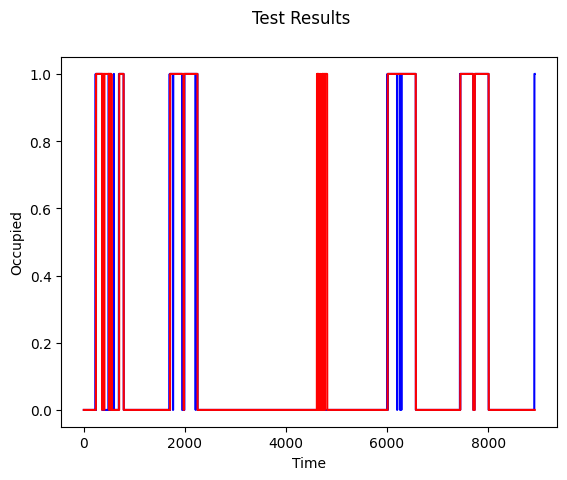

In [20]:
# put it all together for other models

# make a prediction
pred = model.predict(X_test)# the pred
print(pred) # round them!

pred = np.round(pred,0)
print(pred) # run all if you get an error...

# confusion matrix - put this at the top!
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
print(confusion_matrix(y_test, pred)) # looks pretty good!
print(classification_report(y_test, pred))

# show timeseries plot on the train and validation data
plt.plot(np.arange(X_test.shape[0]), y_test, color='blue') # actual data
plt.plot(np.arange(X_test.shape[0]), pred, color='red') # predicted data
plt.suptitle('Test Results')
plt.xlabel('Time')
plt.ylabel('Occupied')
plt.show()

# LSTM one layer model
Literally, just grab the code above and change SimpleRNN to LSTM and boom! you have a more sophisticated model.

In [21]:
# define shape
n_steps = X_train.shape[1]
n_features = X_train.shape[2]


# define model
model = Sequential()
model.add(Conv1D(filters=32, kernel_size=3, input_shape=(n_steps,n_features))) # notice how input shape goes in first layer
model.add(MaxPooling1D())
model.add(LSTM(30, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy',metrics=['acc'])
model.summary()

es = EarlyStopping(monitor='val_acc', mode='max',
                   patience=10,
                   verbose=1,
                   restore_best_weights=True)

# fit model (uses early stopping)
model.fit(X_train, y_train,
          epochs=500,
          batch_size=64,
          validation_split=0.2, # val is a random 20% of the data since we set shuffle = True
          verbose=1,
          callbacks=[es],
          shuffle=True)

C:\Users\dww05002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 48, 32)         │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 30)             │         7,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,103 (31.65 KB)

 Trainable params: 8,103 (31.65 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 12:44 7s/step - acc: 0.1719 - loss: 230.9068

  5/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - acc: 0.1688 - loss: 121.1880 

  9/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - acc: 0.4392 - loss: 88.2860 

 13/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - acc: 0.5373 - loss: 76.4578

 17/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - acc: 0.5974 - loss: 66.2595

 21/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - acc: 0.6205 - loss: 60.2561

 25/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - acc: 0.6494 - loss: 53.3626

 29/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - acc: 0.6708 - loss: 47.8486

 33/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - acc: 0.6847 - loss: 43.2076

 37/112 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - acc: 0.7023 - loss: 39.4771

 40/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.7176 - loss: 36.9057

 44/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.7344 - loss: 33.9933

 48/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.7529 - loss: 31.3766

 52/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.7662 - loss: 29.3174

 56/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.7804 - loss: 27.3978

 60/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.7919 - loss: 25.7863

 64/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.8035 - loss: 24.3613

 68/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.8125 - loss: 23.1617

 72/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.8190 - loss: 22.1114

 76/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.8257 - loss: 21.1461

 80/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.8316 - loss: 20.2772

 84/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.8378 - loss: 19.5022

 88/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.8430 - loss: 18.7457

 92/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.8470 - loss: 18.0126

 96/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.8498 - loss: 17.3630

100/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.8523 - loss: 16.7972

104/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.8559 - loss: 16.2542

108/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.8581 - loss: 15.7790

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.8591 - loss: 15.4472

112/112 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - acc: 0.8591 - loss: 15.4472 - val_acc: 0.9552 - val_loss: 1.8736


Epoch 2/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 8s 75ms/step - acc: 0.8906 - loss: 7.1529

  5/112 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - acc: 0.9187 - loss: 4.3422

  9/112 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - acc: 0.9288 - loss: 3.7226

 13/112 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - acc: 0.9279 - loss: 3.9194

 17/112 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - acc: 0.9301 - loss: 4.0878

 21/112 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - acc: 0.9353 - loss: 4.0485

 25/112 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - acc: 0.9331 - loss: 3.9410

 29/112 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - acc: 0.9321 - loss: 4.0198

 33/112 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - acc: 0.9304 - loss: 4.0358

 37/112 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - acc: 0.9291 - loss: 4.1823

 41/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9280 - loss: 4.3912

 45/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9253 - loss: 4.2176

 49/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9225 - loss: 4.3147

 53/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9245 - loss: 4.2229

 57/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9257 - loss: 4.0633

 61/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9278 - loss: 3.8802

 65/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9286 - loss: 3.8957

 69/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9287 - loss: 3.8521

 73/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9285 - loss: 3.7512

 77/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9265 - loss: 3.7806

 81/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9263 - loss: 3.8300

 85/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9261 - loss: 3.8406

 89/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9264 - loss: 3.7990

 92/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9273 - loss: 3.8440

 96/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9284 - loss: 3.8465

100/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9286 - loss: 3.8205

104/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9292 - loss: 3.7738

108/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9285 - loss: 3.7584

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9266 - loss: 3.7307

112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - acc: 0.9266 - loss: 3.7307 - val_acc: 0.8672 - val_loss: 3.1595


Epoch 3/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 1:06 601ms/step - acc: 0.8438 - loss: 6.3700

  5/112 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - acc: 0.8281 - loss: 5.8062   

  9/112 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - acc: 0.8333 - loss: 5.4027

 13/112 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - acc: 0.8510 - loss: 4.9944

 17/112 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - acc: 0.8704 - loss: 4.4686

 21/112 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - acc: 0.8869 - loss: 4.1243

 25/112 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - acc: 0.8931 - loss: 4.0241

 29/112 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - acc: 0.8971 - loss: 3.9002

 33/112 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - acc: 0.8987 - loss: 3.9240

 36/112 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - acc: 0.9010 - loss: 3.9687

 40/112 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - acc: 0.9043 - loss: 4.0257

 44/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9048 - loss: 3.9028

 48/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9076 - loss: 3.7440

 52/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9084 - loss: 3.7168

 56/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9090 - loss: 3.6105

 60/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9120 - loss: 3.4469

 63/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9137 - loss: 3.4431

 67/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9153 - loss: 3.3338

 71/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9166 - loss: 3.3153

 75/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9173 - loss: 3.2271

 79/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9175 - loss: 3.2347

 83/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9181 - loss: 3.1863

 87/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9199 - loss: 3.1258

 91/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9205 - loss: 3.1875

 95/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9219 - loss: 3.1161

 99/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9238 - loss: 3.0608

103/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9238 - loss: 3.0214

107/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9242 - loss: 2.9834

111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9236 - loss: 2.9595

112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - acc: 0.9235 - loss: 2.9584 - val_acc: 0.9541 - val_loss: 1.2474


Epoch 4/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - acc: 0.8438 - loss: 4.1490

  5/112 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - acc: 0.9187 - loss: 1.7255

  9/112 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - acc: 0.9201 - loss: 1.6940

 13/112 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - acc: 0.9219 - loss: 1.8733

 17/112 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - acc: 0.9274 - loss: 1.8359

 20/112 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - acc: 0.9336 - loss: 1.6792

 24/112 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - acc: 0.9336 - loss: 1.8466

 28/112 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - acc: 0.9336 - loss: 1.8144

 32/112 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - acc: 0.9307 - loss: 1.8716

 36/112 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - acc: 0.9310 - loss: 1.8913

 39/112 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - acc: 0.9319 - loss: 1.9367

 43/112 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - acc: 0.9284 - loss: 1.9378

 47/112 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.9289 - loss: 1.8924

 51/112 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.9280 - loss: 1.9020

 55/112 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.9281 - loss: 1.8725

 59/112 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.9309 - loss: 1.7896

 63/112 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.9320 - loss: 1.8024

 67/112 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.9335 - loss: 1.7633

 71/112 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.9333 - loss: 1.7654

 75/112 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.9333 - loss: 1.7370

 79/112 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.9322 - loss: 1.7621

 83/112 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.9315 - loss: 1.7639

 87/112 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.9321 - loss: 1.7363

 91/112 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.9318 - loss: 1.7644

 95/112 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.9331 - loss: 1.7268

 99/112 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.9343 - loss: 1.7003

103/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9343 - loss: 1.6960

107/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9344 - loss: 1.6943

111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9338 - loss: 1.6951

112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - acc: 0.9337 - loss: 1.6996 - val_acc: 0.9451 - val_loss: 1.3073


Epoch 5/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 1:03 575ms/step - acc: 0.9062 - loss: 2.0684

  6/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - acc: 0.9323 - loss: 0.9778   

 11/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - acc: 0.9304 - loss: 1.1355

 16/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - acc: 0.9316 - loss: 1.2520

 21/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - acc: 0.9405 - loss: 1.2320

 26/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - acc: 0.9393 - loss: 1.2835

 30/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - acc: 0.9375 - loss: 1.3378

 35/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9357 - loss: 1.3721

 40/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9359 - loss: 1.5029

 44/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9343 - loss: 1.4728

 49/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9330 - loss: 1.4971

 53/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9348 - loss: 1.4445

 57/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9361 - loss: 1.3946

 61/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9383 - loss: 1.3434

 65/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9389 - loss: 1.3532

 70/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9388 - loss: 1.3334

 74/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9390 - loss: 1.3032

 78/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9387 - loss: 1.2977

 82/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9373 - loss: 1.3254

 86/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9371 - loss: 1.3227

 90/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9380 - loss: 1.3024

 94/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9387 - loss: 1.2972

 98/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9397 - loss: 1.2881

103/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9398 - loss: 1.2750

108/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9392 - loss: 1.2789

112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - acc: 0.9388 - loss: 1.2873 - val_acc: 0.9451 - val_loss: 1.1836


Epoch 6/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - acc: 0.8438 - loss: 1.5669

  6/112 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - acc: 0.9193 - loss: 0.7687

 11/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - acc: 0.9361 - loss: 0.8151

 17/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - acc: 0.9393 - loss: 0.8672

 22/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.9425 - loss: 0.9147

 27/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.9416 - loss: 0.9658

 31/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.9390 - loss: 0.9954

 36/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.9397 - loss: 1.0228

 41/112 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.9379 - loss: 1.0583

 45/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9389 - loss: 1.0157

 49/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9372 - loss: 1.0706

 53/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9390 - loss: 1.0300

 57/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9400 - loss: 0.9899

 61/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9419 - loss: 0.9616

 65/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9423 - loss: 0.9679

 69/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9427 - loss: 0.9508

 73/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9424 - loss: 0.9425

 77/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9418 - loss: 0.9546

 81/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9416 - loss: 0.9491

 85/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9406 - loss: 0.9672

 89/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9401 - loss: 0.9593

 93/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9410 - loss: 0.9377

 97/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9415 - loss: 0.9416

101/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9415 - loss: 0.9352

106/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9419 - loss: 0.9294

111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9416 - loss: 0.9375

112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - acc: 0.9414 - loss: 0.9426 - val_acc: 0.9440 - val_loss: 1.1237


Epoch 7/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - acc: 0.8750 - loss: 1.0657

  6/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - acc: 0.9323 - loss: 0.5546

 11/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - acc: 0.9432 - loss: 0.5977

 15/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - acc: 0.9417 - loss: 0.7246

 19/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - acc: 0.9465 - loss: 0.6494

 23/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - acc: 0.9470 - loss: 0.6829

 27/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - acc: 0.9456 - loss: 0.7279

 31/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - acc: 0.9420 - loss: 0.7498

 35/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9411 - loss: 0.7803

 39/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9407 - loss: 0.7934

 43/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9390 - loss: 0.8009

 47/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9412 - loss: 0.7887

 51/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9412 - loss: 0.8116

 56/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9417 - loss: 0.7821

 60/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9432 - loss: 0.7610

 64/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9438 - loss: 0.7500

 68/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9444 - loss: 0.7441

 73/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9443 - loss: 0.7292

 77/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9444 - loss: 0.7354

 81/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9448 - loss: 0.7292

 85/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9443 - loss: 0.7465

 89/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9449 - loss: 0.7451

 93/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9461 - loss: 0.7264

 97/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9467 - loss: 0.7317

101/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9468 - loss: 0.7283

105/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9464 - loss: 0.7238

109/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9460 - loss: 0.7276

112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - acc: 0.9456 - loss: 0.7356 - val_acc: 0.9417 - val_loss: 1.0348


Epoch 8/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - acc: 0.8750 - loss: 0.7242

  5/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - acc: 0.9531 - loss: 0.3337

  9/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - acc: 0.9514 - loss: 0.4658

 13/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - acc: 0.9531 - loss: 0.4576

 17/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - acc: 0.9531 - loss: 0.5126

 22/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - acc: 0.9545 - loss: 0.5264

 27/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - acc: 0.9525 - loss: 0.5618

 31/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - acc: 0.9501 - loss: 0.5797

 36/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9492 - loss: 0.5998

 41/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9470 - loss: 0.6320

 45/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9483 - loss: 0.6049

 50/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9475 - loss: 0.6332

 55/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9472 - loss: 0.6157

 60/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9487 - loss: 0.5932

 65/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9493 - loss: 0.5863

 70/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9493 - loss: 0.5740

 75/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9492 - loss: 0.5680

 80/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9492 - loss: 0.5662

 85/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9491 - loss: 0.5797

 90/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9502 - loss: 0.5704

 95/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9510 - loss: 0.5623

100/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9517 - loss: 0.5630

104/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9516 - loss: 0.5615

109/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9508 - loss: 0.5697

112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - acc: 0.9504 - loss: 0.5748 - val_acc: 0.9429 - val_loss: 0.8358


Epoch 9/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 1:44 944ms/step - acc: 0.8594 - loss: 0.6871

  6/112 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - acc: 0.9479 - loss: 0.3680   

 11/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - acc: 0.9531 - loss: 0.3898

 16/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - acc: 0.9502 - loss: 0.4589

 21/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - acc: 0.9561 - loss: 0.4183

 26/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - acc: 0.9537 - loss: 0.4384

 31/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9506 - loss: 0.4644

 35/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9504 - loss: 0.4717

 40/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9492 - loss: 0.5033

 45/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9510 - loss: 0.4775

 50/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9491 - loss: 0.5044

 55/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9489 - loss: 0.4897

 60/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9503 - loss: 0.4740

 65/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9510 - loss: 0.4632

 70/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9511 - loss: 0.4530

 74/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9510 - loss: 0.4425

 78/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9515 - loss: 0.4422

 83/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9505 - loss: 0.4554

 87/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9511 - loss: 0.4475

 92/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9523 - loss: 0.4439

 97/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9533 - loss: 0.4445

101/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9537 - loss: 0.4435

105/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9537 - loss: 0.4458

109/112 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - acc: 0.9534 - loss: 0.4479

112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - acc: 0.9533 - loss: 0.4507 - val_acc: 0.9423 - val_loss: 0.7710


Epoch 10/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 14s 129ms/step - acc: 0.9531 - loss: 0.3567

  5/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - acc: 0.9625 - loss: 0.2225  

  9/112 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - acc: 0.9566 - loss: 0.3183

 13/112 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - acc: 0.9555 - loss: 0.3140

 17/112 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - acc: 0.9568 - loss: 0.3364

 21/112 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - acc: 0.9598 - loss: 0.3198

 25/112 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - acc: 0.9563 - loss: 0.3416

 29/112 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - acc: 0.9553 - loss: 0.3450

 33/112 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - acc: 0.9541 - loss: 0.3594

 36/112 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - acc: 0.9531 - loss: 0.3687

 40/112 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - acc: 0.9516 - loss: 0.3905

 44/112 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - acc: 0.9528 - loss: 0.3743

 48/112 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.9525 - loss: 0.3812

 52/112 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.9513 - loss: 0.3927

 55/112 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.9517 - loss: 0.3836

 59/112 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.9531 - loss: 0.3738

 63/112 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.9536 - loss: 0.3648

 67/112 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.9536 - loss: 0.3597

 71/112 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.9531 - loss: 0.3555

 75/112 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.9529 - loss: 0.3546

 79/112 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.9527 - loss: 0.3569

 82/112 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.9524 - loss: 0.3618

 86/112 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.9524 - loss: 0.3590

 90/112 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.9538 - loss: 0.3547

 93/112 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.9543 - loss: 0.3491

 97/112 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.9549 - loss: 0.3566

101/112 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.9551 - loss: 0.3573

105/112 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.9549 - loss: 0.3599

109/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9548 - loss: 0.3603

112/112 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - acc: 0.9550 - loss: 0.3611 - val_acc: 0.9429 - val_loss: 0.7136


Epoch 11/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 20s 181ms/step - acc: 0.9531 - loss: 0.3167

  5/112 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - acc: 0.9625 - loss: 0.1994  

  9/112 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - acc: 0.9601 - loss: 0.2839

 13/112 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - acc: 0.9579 - loss: 0.2837

 17/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - acc: 0.9596 - loss: 0.2965

 22/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - acc: 0.9609 - loss: 0.2895

 26/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - acc: 0.9615 - loss: 0.2807

 30/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - acc: 0.9583 - loss: 0.3078

 34/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - acc: 0.9573 - loss: 0.3172

 39/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9567 - loss: 0.3268

 43/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9564 - loss: 0.3266

 47/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9558 - loss: 0.3278

 51/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9544 - loss: 0.3405

 55/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9543 - loss: 0.3340

 60/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9555 - loss: 0.3277

 65/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9560 - loss: 0.3160

 69/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9561 - loss: 0.3058

 73/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9553 - loss: 0.3092

 77/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9556 - loss: 0.3103

 81/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9558 - loss: 0.3074

 85/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9555 - loss: 0.3155

 89/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9566 - loss: 0.3145

 92/112 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - acc: 0.9574 - loss: 0.3095

 95/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9579 - loss: 0.3097

 99/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9586 - loss: 0.3117

102/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9582 - loss: 0.3149

105/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9582 - loss: 0.3191

108/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9576 - loss: 0.3235

110/112 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - acc: 0.9575 - loss: 0.3259

112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - acc: 0.9573 - loss: 0.3271 - val_acc: 0.9501 - val_loss: 0.5468


Epoch 11: early stopping


Restoring model weights from the end of the best epoch: 1.


  1/279 ━━━━━━━━━━━━━━━━━━━━ 11:15 2s/step

 10/279 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step  

 19/279 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

 29/279 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

 34/279 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

 44/279 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

 53/279 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

 62/279 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

 72/279 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

 82/279 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

 91/279 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

 96/279 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

103/279 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

112/279 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

121/279 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

129/279 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

138/279 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

148/279 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

159/279 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

167/279 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

176/279 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

184/279 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

193/279 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

204/279 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

209/279 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

217/279 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

225/279 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

234/279 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

244/279 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

250/279 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

259/279 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

265/279 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

272/279 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

279/279 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

279/279 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step


[[1.0889709e-20]
 [1.1012359e-20]
 [1.3084985e-20]
 ...
 [0.0000000e+00]
 [0.0000000e+00]
 [0.0000000e+00]]
[[0.]
 [0.]
 [0.]
 ...
 [0.]
 [0.]
 [0.]]
[[7019   69]
 [ 279 1556]]
              precision    recall  f1-score   support

         0.0       0.96      0.99      0.98      7088
         1.0       0.96      0.85      0.90      1835

    accuracy                           0.96      8923
   macro avg       0.96      0.92      0.94      8923
weighted avg       0.96      0.96      0.96      8923



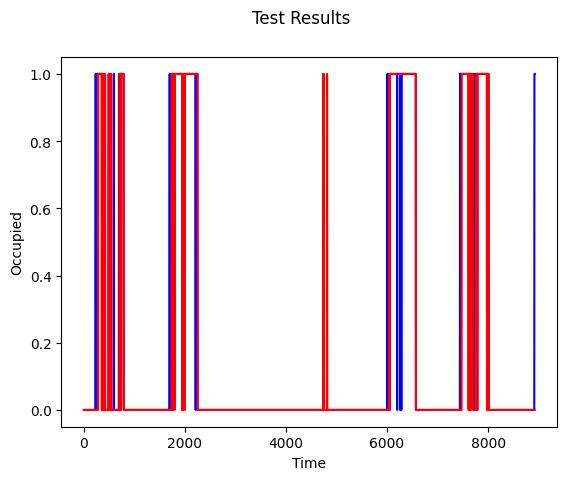

In [22]:
# put it all together for other models

# make a prediction
pred = model.predict(X_test)# the pred
print(pred) # round them!

pred = np.round(pred,0)
print(pred) # run all if you get an error...

# confusion matrix - put this at the top!
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
print(confusion_matrix(y_test, pred)) # looks pretty good!
print(classification_report(y_test, pred))

# show timeseries plot on the train and validation data
plt.plot(np.arange(X_test.shape[0]), y_test, color='blue') # actual data
plt.plot(np.arange(X_test.shape[0]), pred, color='red') # predicted data
plt.suptitle('Test Results')
plt.xlabel('Time')
plt.ylabel('Occupied')
plt.show()

# LSTM two layer model

In [23]:
# now let's build a model

# since this is a univariate problem, n_features will be 1 (we also defined this before)

# define model
model = Sequential()
model.add(Conv1D(filters=128, kernel_size=3, input_shape=(n_steps,n_features))) # notice how input shape goes in first layer
model.add(MaxPooling1D(2))
model.add(Bidirectional(LSTM(30,
                            return_sequences=True, # remember, if stacking layers, you need to return sequences!
                            activation='relu',
                            recurrent_dropout=0.2)))
model.add(GRU(20, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy',metrics=['acc'])
model.summary()

es = EarlyStopping(monitor='val_acc', mode='max',
                   patience=10,
                   verbose=1,
                   restore_best_weights=True)

# fit model (uses early stopping)
model.fit(X_train, y_train,
          epochs=500,
          batch_size=64,
          validation_split=0.2, # val is a random 20% of the data since we set shuffle = True
          verbose=1,
          callbacks=[es],
          shuffle=True)

C:\Users\dww05002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 48, 128)        │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 24, 60)         │        38,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 20)             │         4,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,149 (176.36 KB)

 Trainable params: 45,149 (176.36 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 46:04 25s/step - acc: 0.5469 - loss: 186.6793

  3/112 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - acc: 0.4792 - loss: 128.2205  

  5/112 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - acc: 0.4906 - loss: 102.9998

  6/112 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - acc: 0.5078 - loss: 93.9350 

  7/112 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - acc: 0.4888 - loss: 97.8645

  9/112 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - acc: 0.4792 - loss: 96.8041

 10/112 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - acc: 0.4781 - loss: 92.8636

 11/112 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - acc: 0.4673 - loss: 88.5287

 12/112 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - acc: 0.4622 - loss: 84.8950

 14/112 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - acc: 0.4319 - loss: 82.4937

 15/112 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - acc: 0.4198 - loss: 82.5387

 17/112 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - acc: 0.4026 - loss: 78.2911

 19/112 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - acc: 0.4013 - loss: 77.5471

 21/112 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - acc: 0.3884 - loss: 73.4475

 22/112 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - acc: 0.3835 - loss: 71.8888

 23/112 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - acc: 0.3852 - loss: 70.5549

 25/112 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - acc: 0.3825 - loss: 67.3253

 27/112 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - acc: 0.3900 - loss: 63.5642

 29/112 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - acc: 0.3831 - loss: 61.2421

 31/112 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - acc: 0.3836 - loss: 58.3973

 33/112 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - acc: 0.3793 - loss: 55.9985

 35/112 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - acc: 0.3835 - loss: 53.4892

 37/112 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - acc: 0.3872 - loss: 51.2402

 39/112 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - acc: 0.3998 - loss: 49.1595

 40/112 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - acc: 0.4043 - loss: 48.1397

 42/112 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - acc: 0.4148 - loss: 55.1639

 43/112 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - acc: 0.4201 - loss: 54.4851

 44/112 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - acc: 0.4226 - loss: 53.9443

 46/112 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - acc: 0.4307 - loss: 52.3656

 48/112 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - acc: 0.4385 - loss: 51.0737

 50/112 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - acc: 0.4450 - loss: 49.3508

 52/112 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - acc: 0.4456 - loss: 47.7468

 53/112 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - acc: 0.4422 - loss: 47.0550

 55/112 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - acc: 0.4403 - loss: 45.7041

 57/112 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - acc: 0.4342 - loss: 44.5913

 59/112 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - acc: 0.4296 - loss: 43.5685

 60/112 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - acc: 0.4268 - loss: 42.9972

 61/112 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - acc: 0.4252 - loss: 42.5284

 63/112 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - acc: 0.4261 - loss: 41.3719

 64/112 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - acc: 0.4280 - loss: 40.8652

 65/112 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - acc: 0.4320 - loss: 40.8534

 67/112 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - acc: 0.4387 - loss: 39.8910

 69/112 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - acc: 0.4461 - loss: 39.0605

 71/112 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - acc: 0.4527 - loss: 38.3055

 73/112 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - acc: 0.4585 - loss: 37.7212

 75/112 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - acc: 0.4660 - loss: 36.8595

 77/112 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - acc: 0.4728 - loss: 36.2080

 79/112 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - acc: 0.4818 - loss: 35.6196

 81/112 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - acc: 0.4869 - loss: 35.1047

 83/112 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - acc: 0.4940 - loss: 34.4315

 85/112 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - acc: 0.5007 - loss: 34.2405

 87/112 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - acc: 0.5061 - loss: 33.5463

 89/112 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - acc: 0.5123 - loss: 33.1449

 91/112 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - acc: 0.5173 - loss: 32.5323

 93/112 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - acc: 0.5217 - loss: 32.0229

 95/112 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - acc: 0.5281 - loss: 31.4911

 97/112 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - acc: 0.5316 - loss: 30.9658

 99/112 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - acc: 0.5360 - loss: 30.3780

101/112 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - acc: 0.5384 - loss: 29.8165

103/112 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - acc: 0.5429 - loss: 29.5002

105/112 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - acc: 0.5467 - loss: 29.0337

107/112 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - acc: 0.5508 - loss: 28.5591

109/112 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - acc: 0.5550 - loss: 28.0549

110/112 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - acc: 0.5561 - loss: 27.8251

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - acc: 0.5577 - loss: 27.4811

112/112 ━━━━━━━━━━━━━━━━━━━━ 35s 94ms/step - acc: 0.5577 - loss: 27.4811 - val_acc: 0.8050 - val_loss: 1.0508


Epoch 2/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 14s 133ms/step - acc: 0.6875 - loss: 6.1879

  3/112 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - acc: 0.7500 - loss: 2.7702  

  4/112 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - acc: 0.7383 - loss: 2.6143

  6/112 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - acc: 0.7552 - loss: 2.2061

  8/112 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - acc: 0.7422 - loss: 1.9565

 10/112 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - acc: 0.7359 - loss: 1.8390

 12/112 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - acc: 0.7305 - loss: 3.0749

 14/112 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - acc: 0.7377 - loss: 3.3144

 16/112 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - acc: 0.7441 - loss: 3.0855

 17/112 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - acc: 0.7426 - loss: 2.9723

 19/112 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - acc: 0.7319 - loss: 3.1461

 20/112 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - acc: 0.7344 - loss: 3.0280

 21/112 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - acc: 0.7336 - loss: 2.9347

 22/112 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - acc: 0.7408 - loss: 2.8295

 24/112 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - acc: 0.7389 - loss: 2.8345

 26/112 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - acc: 0.7440 - loss: 2.6793

 28/112 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - acc: 0.7433 - loss: 3.0547

 30/112 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - acc: 0.7448 - loss: 3.0528

 32/112 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - acc: 0.7432 - loss: 3.0811

 33/112 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - acc: 0.7438 - loss: 3.1521

 35/112 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - acc: 0.7460 - loss: 3.0756

 37/112 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - acc: 0.7479 - loss: 2.9459

 38/112 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - acc: 0.7484 - loss: 2.8902

 39/112 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - acc: 0.7464 - loss: 2.8354

 41/112 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - acc: 0.7450 - loss: 2.7546

 43/112 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - acc: 0.7431 - loss: 2.6637

 44/112 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - acc: 0.7447 - loss: 2.6171

 45/112 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - acc: 0.7444 - loss: 2.5737

 46/112 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - acc: 0.7435 - loss: 2.7034

 48/112 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - acc: 0.7428 - loss: 2.6430

 50/112 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - acc: 0.7466 - loss: 2.5681

 52/112 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - acc: 0.7431 - loss: 2.5840

 54/112 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - acc: 0.7433 - loss: 2.5621

 56/112 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - acc: 0.7444 - loss: 2.4939

 58/112 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - acc: 0.7452 - loss: 2.4439

 60/112 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - acc: 0.7443 - loss: 2.7694

 62/112 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - acc: 0.7445 - loss: 2.7605

 64/112 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - acc: 0.7444 - loss: 2.6966

 66/112 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - acc: 0.7464 - loss: 2.6322

 67/112 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - acc: 0.7456 - loss: 2.6410

 68/112 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - acc: 0.7466 - loss: 2.6103

 69/112 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - acc: 0.7477 - loss: 2.5830

 71/112 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - acc: 0.7487 - loss: 2.5288

 73/112 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - acc: 0.7485 - loss: 2.4769

 75/112 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - acc: 0.7487 - loss: 2.4488

 77/112 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - acc: 0.7482 - loss: 2.4675

 79/112 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - acc: 0.7504 - loss: 2.5774

 81/112 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - acc: 0.7490 - loss: 2.5678

 83/112 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - acc: 0.7500 - loss: 2.5246

 84/112 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - acc: 0.7513 - loss: 2.5003

 85/112 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - acc: 0.7515 - loss: 2.4794

 87/112 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - acc: 0.7520 - loss: 2.4490

 89/112 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - acc: 0.7526 - loss: 2.4511

 91/112 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - acc: 0.7524 - loss: 2.6939

 93/112 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - acc: 0.7518 - loss: 2.6812

 95/112 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - acc: 0.7533 - loss: 2.6394

 97/112 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - acc: 0.7521 - loss: 2.7362

 98/112 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - acc: 0.7529 - loss: 2.7481

100/112 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - acc: 0.7517 - loss: 2.7156

102/112 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - acc: 0.7520 - loss: 2.7461

104/112 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - acc: 0.7520 - loss: 2.8353

106/112 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - acc: 0.7525 - loss: 2.7952

108/112 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - acc: 0.7536 - loss: 2.7660

110/112 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - acc: 0.7536 - loss: 2.7975

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - acc: 0.7527 - loss: 2.7726

112/112 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - acc: 0.7527 - loss: 2.7726 - val_acc: 0.8106 - val_loss: 0.6890


Epoch 3/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 20s 186ms/step - acc: 0.7188 - loss: 1.0860

  2/112 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - acc: 0.7422 - loss: 0.8974  

  4/112 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - acc: 0.7578 - loss: 0.8484

  6/112 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - acc: 0.7786 - loss: 1.1072

  8/112 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - acc: 0.7676 - loss: 0.9754

 10/112 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - acc: 0.7578 - loss: 0.9214

 12/112 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - acc: 0.7539 - loss: 1.1696

 13/112 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - acc: 0.7608 - loss: 1.1864

 14/112 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - acc: 0.7612 - loss: 1.2062

 16/112 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - acc: 0.7676 - loss: 1.2902

 18/112 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - acc: 0.7552 - loss: 1.2531

 20/112 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - acc: 0.7523 - loss: 1.1814

 22/112 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - acc: 0.7571 - loss: 1.1349

 24/112 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - acc: 0.7572 - loss: 1.4145

 26/112 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - acc: 0.7614 - loss: 1.3561

 27/112 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - acc: 0.7610 - loss: 1.4393

 28/112 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - acc: 0.7617 - loss: 1.4135

 30/112 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - acc: 0.7641 - loss: 1.3967

 32/112 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - acc: 0.7642 - loss: 1.6011

 34/112 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - acc: 0.7661 - loss: 1.7223

 36/112 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - acc: 0.7661 - loss: 1.7065

 38/112 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - acc: 0.7677 - loss: 1.8393

 39/112 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - acc: 0.7656 - loss: 2.0484

 41/112 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - acc: 0.7641 - loss: 2.0645

 43/112 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - acc: 0.7627 - loss: 2.2669

 45/112 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - acc: 0.7622 - loss: 2.4627

 47/112 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - acc: 0.7596 - loss: 2.3891

 48/112 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - acc: 0.7601 - loss: 2.3504

 49/112 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - acc: 0.7599 - loss: 2.4013

 51/112 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - acc: 0.7613 - loss: 2.4706

 52/112 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - acc: 0.7584 - loss: 2.4667

 54/112 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - acc: 0.7587 - loss: 2.4987

 56/112 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - acc: 0.7584 - loss: 2.4437

 57/112 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - acc: 0.7590 - loss: 2.4700

 58/112 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - acc: 0.7600 - loss: 2.4413

 59/112 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - acc: 0.7595 - loss: 2.5831

 61/112 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - acc: 0.7592 - loss: 2.6374

 63/112 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - acc: 0.7582 - loss: 2.5769

 65/112 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - acc: 0.7591 - loss: 2.5352

 67/112 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - acc: 0.7593 - loss: 2.4773

 69/112 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - acc: 0.7604 - loss: 2.4801

 71/112 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - acc: 0.7606 - loss: 2.4347

 72/112 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - acc: 0.7611 - loss: 2.4074

 74/112 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - acc: 0.7606 - loss: 2.3633

 76/112 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - acc: 0.7599 - loss: 2.5799

 78/112 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - acc: 0.7606 - loss: 2.6014

 80/112 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - acc: 0.7609 - loss: 2.5519

 82/112 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - acc: 0.7595 - loss: 2.6588

 84/112 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - acc: 0.7610 - loss: 2.6097

 86/112 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - acc: 0.7605 - loss: 2.5936

 87/112 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - acc: 0.7610 - loss: 2.5707

 88/112 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - acc: 0.7610 - loss: 2.6036

 90/112 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - acc: 0.7601 - loss: 2.6262

 92/112 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - acc: 0.7588 - loss: 2.5996

 94/112 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - acc: 0.7601 - loss: 2.5648

 96/112 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - acc: 0.7604 - loss: 2.5535

 97/112 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - acc: 0.7589 - loss: 2.5595

 99/112 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - acc: 0.7587 - loss: 2.5537

100/112 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - acc: 0.7575 - loss: 2.5608

102/112 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - acc: 0.7577 - loss: 2.5338

104/112 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - acc: 0.7577 - loss: 2.5332

105/112 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - acc: 0.7579 - loss: 2.5150

107/112 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - acc: 0.7588 - loss: 2.5486

109/112 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - acc: 0.7593 - loss: 2.5306

110/112 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - acc: 0.7591 - loss: 2.5140

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - acc: 0.7583 - loss: 2.4882

112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - acc: 0.7583 - loss: 2.4882 - val_acc: 0.8011 - val_loss: 0.5921


Epoch 4/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 16s 147ms/step - acc: 0.6875 - loss: 1.3170

  2/112 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - acc: 0.7344 - loss: 0.8852  

  3/112 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - acc: 0.7656 - loss: 0.7414

  5/112 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - acc: 0.7500 - loss: 0.7390

  6/112 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - acc: 0.7734 - loss: 0.6936

  8/112 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - acc: 0.7617 - loss: 0.7030

 10/112 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - acc: 0.7547 - loss: 0.7072

 12/112 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - acc: 0.7487 - loss: 0.8351

 13/112 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - acc: 0.7572 - loss: 0.8407

 15/112 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - acc: 0.7594 - loss: 0.7971

 17/112 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - acc: 0.7610 - loss: 0.7611

 19/112 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - acc: 0.7484 - loss: 0.7400

 21/112 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - acc: 0.7485 - loss: 0.7369

 22/112 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - acc: 0.7550 - loss: 0.7280

 24/112 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - acc: 0.7520 - loss: 0.8785

 26/112 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - acc: 0.7572 - loss: 0.8458

 28/112 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - acc: 0.7584 - loss: 0.8246

 29/112 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - acc: 0.7581 - loss: 0.8294

 31/112 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - acc: 0.7621 - loss: 0.8116

 33/112 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - acc: 0.7599 - loss: 0.7967

 35/112 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - acc: 0.7607 - loss: 0.8500

 37/112 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - acc: 0.7614 - loss: 0.8295

 39/112 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - acc: 0.7600 - loss: 0.8135

 41/112 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - acc: 0.7588 - loss: 0.8319

 43/112 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - acc: 0.7562 - loss: 0.8215

 45/112 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - acc: 0.7563 - loss: 0.8116

 47/112 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - acc: 0.7547 - loss: 0.8021

 49/112 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - acc: 0.7551 - loss: 0.8560

 50/112 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - acc: 0.7581 - loss: 0.8517

 51/112 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - acc: 0.7580 - loss: 0.8457

 53/112 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - acc: 0.7550 - loss: 0.8354

 55/112 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - acc: 0.7560 - loss: 0.8243

 57/112 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - acc: 0.7569 - loss: 0.8132

 59/112 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - acc: 0.7577 - loss: 0.8016

 60/112 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - acc: 0.7576 - loss: 0.7963

 62/112 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - acc: 0.7578 - loss: 0.7878

 63/112 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - acc: 0.7574 - loss: 0.7835

 65/112 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - acc: 0.7584 - loss: 0.7768

 67/112 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - acc: 0.7586 - loss: 0.7767

 69/112 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - acc: 0.7604 - loss: 0.7738

 70/112 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - acc: 0.7609 - loss: 0.7699

 72/112 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - acc: 0.7615 - loss: 0.7615

 74/112 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - acc: 0.7608 - loss: 0.7551

 76/112 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - acc: 0.7605 - loss: 0.7597

 78/112 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - acc: 0.7614 - loss: 0.7524

 79/112 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - acc: 0.7625 - loss: 0.7488

 81/112 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - acc: 0.7610 - loss: 0.7429

 82/112 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - acc: 0.7612 - loss: 0.7397

 84/112 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - acc: 0.7630 - loss: 0.7326

 86/112 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - acc: 0.7629 - loss: 0.7272

 88/112 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - acc: 0.7637 - loss: 0.7218

 90/112 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - acc: 0.7639 - loss: 0.7168

 91/112 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - acc: 0.7637 - loss: 0.7144

 93/112 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - acc: 0.7633 - loss: 0.7100

 95/112 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - acc: 0.7648 - loss: 0.7049

 97/112 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - acc: 0.7637 - loss: 0.7010

 99/112 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - acc: 0.7639 - loss: 0.6962

100/112 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - acc: 0.7630 - loss: 0.6945

102/112 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - acc: 0.7636 - loss: 0.6909

104/112 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - acc: 0.7634 - loss: 0.6880

106/112 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - acc: 0.7640 - loss: 0.6837

108/112 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - acc: 0.7649 - loss: 0.6798

110/112 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - acc: 0.7649 - loss: 0.6784

111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - acc: 0.7645 - loss: 0.6770

112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - acc: 0.7644 - loss: 0.6766 - val_acc: 0.8112 - val_loss: 0.5147


Epoch 5/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 24s 220ms/step - acc: 0.7031 - loss: 0.5369

  2/112 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - acc: 0.7344 - loss: 0.5871  

  3/112 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - acc: 0.7604 - loss: 0.6074

  5/112 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - acc: 0.7563 - loss: 0.5685

  6/112 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - acc: 0.7786 - loss: 0.5430

  8/112 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - acc: 0.7676 - loss: 0.5294

 10/112 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - acc: 0.7609 - loss: 0.5197

 12/112 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - acc: 0.7565 - loss: 0.5153

 14/112 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - acc: 0.7645 - loss: 0.5068

 16/112 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - acc: 0.7715 - loss: 0.5021

 17/112 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - acc: 0.7684 - loss: 0.5031

 18/112 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - acc: 0.7595 - loss: 0.5123

 20/112 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - acc: 0.7555 - loss: 0.5131

 22/112 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - acc: 0.7607 - loss: 0.5082

 24/112 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - acc: 0.7611 - loss: 0.5089

 25/112 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - acc: 0.7625 - loss: 0.5127

 27/112 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - acc: 0.7645 - loss: 0.5096

 29/112 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - acc: 0.7645 - loss: 0.5181

 31/112 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - acc: 0.7686 - loss: 0.5143

 33/112 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - acc: 0.7661 - loss: 0.5331

 35/112 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - acc: 0.7679 - loss: 0.5300

 36/112 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - acc: 0.7682 - loss: 0.5294

 37/112 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - acc: 0.7690 - loss: 0.5272

 39/112 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - acc: 0.7672 - loss: 0.5247

 40/112 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - acc: 0.7680 - loss: 0.5223

 42/112 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - acc: 0.7656 - loss: 0.5219

 44/112 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - acc: 0.7646 - loss: 0.5216

 46/112 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - acc: 0.7626 - loss: 0.5209

 47/112 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - acc: 0.7613 - loss: 0.5207

 49/112 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - acc: 0.7621 - loss: 0.5191

 51/112 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - acc: 0.7650 - loss: 0.5160

 52/112 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - acc: 0.7620 - loss: 0.5177

 53/112 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - acc: 0.7621 - loss: 0.5168

 54/112 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - acc: 0.7624 - loss: 0.5164

 56/112 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - acc: 0.7626 - loss: 0.5155

 57/112 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - acc: 0.7629 - loss: 0.5167

 59/112 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - acc: 0.7630 - loss: 0.5176

 61/112 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - acc: 0.7628 - loss: 0.5207

 63/112 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - acc: 0.7619 - loss: 0.5228

 64/112 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - acc: 0.7622 - loss: 0.5221

 65/112 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - acc: 0.7627 - loss: 0.5211

 67/112 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - acc: 0.7631 - loss: 0.5196

 69/112 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - acc: 0.7647 - loss: 0.5252

 71/112 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - acc: 0.7654 - loss: 0.5246

 72/112 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - acc: 0.7656 - loss: 0.5234

 73/112 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - acc: 0.7648 - loss: 0.5236

 75/112 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - acc: 0.7656 - loss: 0.5217

 76/112 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - acc: 0.7650 - loss: 0.5214

 77/112 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - acc: 0.7648 - loss: 0.5211

 78/112 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - acc: 0.7656 - loss: 0.5237

 80/112 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - acc: 0.7662 - loss: 0.5223

 82/112 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - acc: 0.7652 - loss: 0.5239

 84/112 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - acc: 0.7667 - loss: 0.5281

 86/112 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - acc: 0.7667 - loss: 0.5265

 87/112 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - acc: 0.7671 - loss: 0.5270

 88/112 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - acc: 0.7672 - loss: 0.5269

 89/112 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - acc: 0.7676 - loss: 0.5263

 90/112 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - acc: 0.7674 - loss: 0.5258

 92/112 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - acc: 0.7665 - loss: 0.5256

 94/112 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - acc: 0.7678 - loss: 0.5243

 96/112 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - acc: 0.7684 - loss: 0.5230

 97/112 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - acc: 0.7671 - loss: 0.5236

 98/112 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - acc: 0.7675 - loss: 0.5230

 99/112 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - acc: 0.7674 - loss: 0.5225

100/112 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - acc: 0.7664 - loss: 0.5227

101/112 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - acc: 0.7658 - loss: 0.5225

103/112 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - acc: 0.7668 - loss: 0.5233

105/112 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - acc: 0.7673 - loss: 0.5222

106/112 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - acc: 0.7674 - loss: 0.5216

108/112 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - acc: 0.7681 - loss: 0.5214

110/112 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - acc: 0.7683 - loss: 0.5200

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - acc: 0.7679 - loss: 0.5196

112/112 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - acc: 0.7679 - loss: 0.5196 - val_acc: 0.8118 - val_loss: 0.4685


Epoch 6/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 18s 168ms/step - acc: 0.7188 - loss: 0.4892

  2/112 ━━━━━━━━━━━━━━━━━━━━ 9s 82ms/step - acc: 0.7500 - loss: 0.4676  

  3/112 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step - acc: 0.7760 - loss: 0.4548

  5/112 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - acc: 0.7625 - loss: 0.4686

  6/112 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - acc: 0.7839 - loss: 0.4604

  7/112 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - acc: 0.7679 - loss: 0.4688

  9/112 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - acc: 0.7639 - loss: 0.4678

 11/112 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - acc: 0.7670 - loss: 0.4706

 13/112 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - acc: 0.7656 - loss: 0.4744

 15/112 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - acc: 0.7677 - loss: 0.4721

 17/112 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - acc: 0.7693 - loss: 0.4696

 19/112 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - acc: 0.7558 - loss: 0.4779

 20/112 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - acc: 0.7570 - loss: 0.4780

 22/112 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - acc: 0.7621 - loss: 0.4725

 24/112 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - acc: 0.7624 - loss: 0.4724

 26/112 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - acc: 0.7668 - loss: 0.4686

 28/112 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - acc: 0.7673 - loss: 0.4696

 30/112 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - acc: 0.7693 - loss: 0.4666

 32/112 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - acc: 0.7676 - loss: 0.4685

 34/112 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - acc: 0.7711 - loss: 0.4652

 36/112 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - acc: 0.7708 - loss: 0.4660

 38/112 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - acc: 0.7710 - loss: 0.4675

 40/112 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - acc: 0.7699 - loss: 0.4680

 41/112 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - acc: 0.7679 - loss: 0.4892

 42/112 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - acc: 0.7675 - loss: 0.4888

 44/112 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - acc: 0.7663 - loss: 0.4901

 46/112 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - acc: 0.7646 - loss: 0.4897

 47/112 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - acc: 0.7633 - loss: 0.4914

 49/112 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - acc: 0.7640 - loss: 0.4897

 50/112 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - acc: 0.7672 - loss: 0.4873

 52/112 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - acc: 0.7641 - loss: 0.4977

 54/112 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - acc: 0.7648 - loss: 0.4962

 55/112 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - acc: 0.7651 - loss: 0.4950

 57/112 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - acc: 0.7656 - loss: 0.4936

 59/112 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - acc: 0.7659 - loss: 0.4918

 60/112 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - acc: 0.7656 - loss: 0.4917

 61/112 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - acc: 0.7659 - loss: 0.4909

 62/112 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - acc: 0.7656 - loss: 0.4906

 64/112 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - acc: 0.7654 - loss: 0.4899

 65/112 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - acc: 0.7659 - loss: 0.4935

 67/112 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - acc: 0.7661 - loss: 0.4922

 69/112 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - acc: 0.7677 - loss: 0.4910

 70/112 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - acc: 0.7681 - loss: 0.4904

 72/112 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - acc: 0.7682 - loss: 0.4903

 74/112 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - acc: 0.7673 - loss: 0.4907

 75/112 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - acc: 0.7677 - loss: 0.4962

 77/112 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - acc: 0.7668 - loss: 0.5083

 79/112 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - acc: 0.7688 - loss: 0.5056

 81/112 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - acc: 0.7672 - loss: 0.5058

 82/112 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - acc: 0.7671 - loss: 0.5071

 83/112 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - acc: 0.7677 - loss: 0.5064

 85/112 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - acc: 0.7686 - loss: 0.5043

 86/112 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - acc: 0.7684 - loss: 0.5053

 87/112 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - acc: 0.7689 - loss: 0.5047

 89/112 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - acc: 0.7691 - loss: 0.5035

 91/112 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - acc: 0.7685 - loss: 0.5027

 93/112 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - acc: 0.7680 - loss: 0.5019

 95/112 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - acc: 0.7694 - loss: 0.5004

 97/112 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - acc: 0.7682 - loss: 0.5001

 98/112 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - acc: 0.7688 - loss: 0.4993

 99/112 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - acc: 0.7686 - loss: 0.4986

101/112 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - acc: 0.7670 - loss: 0.4995

102/112 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - acc: 0.7684 - loss: 0.4984

103/112 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - acc: 0.7682 - loss: 0.5002

104/112 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - acc: 0.7682 - loss: 0.4995

105/112 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - acc: 0.7685 - loss: 0.5000

106/112 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - acc: 0.7686 - loss: 0.4992

107/112 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - acc: 0.7694 - loss: 0.4984

109/112 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - acc: 0.7699 - loss: 0.4970

110/112 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - acc: 0.7695 - loss: 0.4986

111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - acc: 0.7690 - loss: 0.4985

112/112 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - acc: 0.7690 - loss: 0.4984 - val_acc: 0.8213 - val_loss: 0.4297


Epoch 7/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 15s 137ms/step - acc: 0.7188 - loss: 0.5047

  3/112 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - acc: 0.7760 - loss: 0.4510  

  4/112 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - acc: 0.7617 - loss: 0.4516

  6/112 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - acc: 0.7865 - loss: 0.4517

  7/112 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - acc: 0.7701 - loss: 0.4581

  8/112 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - acc: 0.7715 - loss: 0.4858

 10/112 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - acc: 0.7641 - loss: 0.4953

 12/112 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - acc: 0.7578 - loss: 0.4950

 13/112 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - acc: 0.7656 - loss: 0.4862

 14/112 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - acc: 0.7656 - loss: 0.4854

 15/112 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - acc: 0.7667 - loss: 0.4827

 17/112 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - acc: 0.7675 - loss: 0.4765

 18/112 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - acc: 0.7595 - loss: 0.4805

 20/112 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - acc: 0.7547 - loss: 0.4826

 22/112 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - acc: 0.7599 - loss: 0.4786

 23/112 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - acc: 0.7595 - loss: 0.4801

 24/112 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - acc: 0.7591 - loss: 0.4817

 26/112 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - acc: 0.7632 - loss: 0.4814

 27/112 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - acc: 0.7633 - loss: 0.4816

 28/112 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - acc: 0.7634 - loss: 0.5028

 29/112 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - acc: 0.7635 - loss: 0.5028

 30/112 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - acc: 0.7656 - loss: 0.5010

 31/112 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - acc: 0.7676 - loss: 0.5010

 33/112 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - acc: 0.7656 - loss: 0.4987

 35/112 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - acc: 0.7674 - loss: 0.4940

 37/112 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - acc: 0.7686 - loss: 0.4893

 39/112 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - acc: 0.7672 - loss: 0.4884

 41/112 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - acc: 0.7664 - loss: 0.4879

 43/112 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - acc: 0.7638 - loss: 0.4947

 45/112 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - acc: 0.7639 - loss: 0.4925

 47/112 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - acc: 0.7620 - loss: 0.4916

 48/112 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - acc: 0.7624 - loss: 0.4905

 49/112 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - acc: 0.7628 - loss: 0.4885

 51/112 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - acc: 0.7656 - loss: 0.4847

 53/112 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - acc: 0.7627 - loss: 0.4852

 54/112 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - acc: 0.7633 - loss: 0.4845

 55/112 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - acc: 0.7636 - loss: 0.4840

 57/112 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - acc: 0.7640 - loss: 0.4830

 59/112 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - acc: 0.7648 - loss: 0.4810

 60/112 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - acc: 0.7646 - loss: 0.4805

 62/112 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - acc: 0.7646 - loss: 0.4793

 63/112 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - acc: 0.7639 - loss: 0.4807

 65/112 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - acc: 0.7647 - loss: 0.4798

 66/112 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - acc: 0.7656 - loss: 0.4784

 67/112 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - acc: 0.7649 - loss: 0.4785

 69/112 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - acc: 0.7668 - loss: 0.4763

 71/112 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - acc: 0.7674 - loss: 0.4755

 73/112 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - acc: 0.7667 - loss: 0.4746

 75/112 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - acc: 0.7675 - loss: 0.4736

 77/112 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - acc: 0.7666 - loss: 0.4743

 79/112 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - acc: 0.7686 - loss: 0.4719

 80/112 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - acc: 0.7682 - loss: 0.4719

 81/112 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - acc: 0.7670 - loss: 0.4747

 83/112 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - acc: 0.7677 - loss: 0.4731

 85/112 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - acc: 0.7686 - loss: 0.4756

 87/112 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - acc: 0.7690 - loss: 0.4741

 88/112 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - acc: 0.7692 - loss: 0.4737

 89/112 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - acc: 0.7695 - loss: 0.4732

 91/112 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - acc: 0.7691 - loss: 0.4726

 93/112 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - acc: 0.7685 - loss: 0.4724

 95/112 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - acc: 0.7699 - loss: 0.4711

 97/112 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - acc: 0.7687 - loss: 0.4706

 99/112 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - acc: 0.7689 - loss: 0.4697

101/112 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - acc: 0.7672 - loss: 0.4710

103/112 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - acc: 0.7685 - loss: 0.4691

105/112 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - acc: 0.7689 - loss: 0.4681

107/112 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - acc: 0.7696 - loss: 0.4693

108/112 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - acc: 0.7697 - loss: 0.4689

110/112 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - acc: 0.7699 - loss: 0.4678

111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - acc: 0.7693 - loss: 0.4702

112/112 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - acc: 0.7691 - loss: 0.4698 - val_acc: 0.8230 - val_loss: 0.3879


Epoch 8/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 7:21 4s/step - acc: 0.7188 - loss: 0.4638

  2/112 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - acc: 0.7422 - loss: 0.4965

  3/112 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - acc: 0.7708 - loss: 0.4614

  4/112 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - acc: 0.7578 - loss: 0.4609

  6/112 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - acc: 0.7839 - loss: 0.4424

  7/112 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - acc: 0.7679 - loss: 0.4469

  9/112 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - acc: 0.7656 - loss: 0.4415

 10/112 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - acc: 0.7656 - loss: 0.4382

 11/112 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - acc: 0.7685 - loss: 0.4361

 12/112 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - acc: 0.7591 - loss: 0.4434

 13/112 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - acc: 0.7668 - loss: 0.4375

 15/112 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - acc: 0.7688 - loss: 0.4362

 17/112 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - acc: 0.7702 - loss: 0.4338

 19/112 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - acc: 0.7566 - loss: 0.4412

 20/112 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - acc: 0.7570 - loss: 0.4417

 21/112 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - acc: 0.7560 - loss: 0.4413

 22/112 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - acc: 0.7621 - loss: 0.4369

 24/112 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - acc: 0.7624 - loss: 0.4378

 25/112 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - acc: 0.7644 - loss: 0.4356

 27/112 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - acc: 0.7668 - loss: 0.4333

 28/112 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - acc: 0.7673 - loss: 0.4327

 30/112 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - acc: 0.7682 - loss: 0.4389

 31/112 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - acc: 0.7702 - loss: 0.4378

 32/112 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - acc: 0.7666 - loss: 0.4401

 33/112 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - acc: 0.7680 - loss: 0.4372

 34/112 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - acc: 0.7698 - loss: 0.4466

 35/112 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - acc: 0.7692 - loss: 0.4455

 36/112 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - acc: 0.7695 - loss: 0.4453

 37/112 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - acc: 0.7703 - loss: 0.4438

 39/112 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - acc: 0.7688 - loss: 0.4447

 41/112 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - acc: 0.7675 - loss: 0.4445

 42/112 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - acc: 0.7667 - loss: 0.4510

 43/112 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - acc: 0.7649 - loss: 0.4524

 44/112 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - acc: 0.7656 - loss: 0.4513

 46/112 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - acc: 0.7639 - loss: 0.4520

 47/112 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - acc: 0.7626 - loss: 0.4524

 48/112 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - acc: 0.7630 - loss: 0.4529

 50/112 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - acc: 0.7666 - loss: 0.4490

 52/112 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - acc: 0.7635 - loss: 0.4499

 54/112 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - acc: 0.7639 - loss: 0.4568

 55/112 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - acc: 0.7642 - loss: 0.4570

 57/112 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - acc: 0.7648 - loss: 0.4564

 58/112 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - acc: 0.7656 - loss: 0.4551

 59/112 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - acc: 0.7651 - loss: 0.4553

 61/112 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - acc: 0.7651 - loss: 0.4541

 62/112 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - acc: 0.7649 - loss: 0.4539

 64/112 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - acc: 0.7646 - loss: 0.4531

 65/112 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - acc: 0.7654 - loss: 0.4520

 66/112 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - acc: 0.7663 - loss: 0.4510

 67/112 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - acc: 0.7656 - loss: 0.4507

 69/112 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - acc: 0.7674 - loss: 0.4491

 70/112 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - acc: 0.7679 - loss: 0.4486

 72/112 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - acc: 0.7682 - loss: 0.4478

 74/112 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - acc: 0.7673 - loss: 0.4473

 75/112 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - acc: 0.7679 - loss: 0.4466

 77/112 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - acc: 0.7670 - loss: 0.4475

 79/112 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - acc: 0.7690 - loss: 0.4455

 81/112 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - acc: 0.7674 - loss: 0.4456

 83/112 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - acc: 0.7681 - loss: 0.4444

 84/112 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - acc: 0.7692 - loss: 0.4432

 85/112 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - acc: 0.7691 - loss: 0.4429

 87/112 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - acc: 0.7696 - loss: 0.4423

 88/112 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - acc: 0.7697 - loss: 0.4418

 89/112 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - acc: 0.7700 - loss: 0.4414

 90/112 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - acc: 0.7698 - loss: 0.4413

 91/112 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - acc: 0.7696 - loss: 0.4410

 93/112 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - acc: 0.7690 - loss: 0.4407

 94/112 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - acc: 0.7701 - loss: 0.4397

 95/112 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - acc: 0.7704 - loss: 0.4395

 96/112 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - acc: 0.7707 - loss: 0.4387

 98/112 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - acc: 0.7698 - loss: 0.4435

100/112 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - acc: 0.7686 - loss: 0.4436

101/112 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - acc: 0.7679 - loss: 0.4440

103/112 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - acc: 0.7691 - loss: 0.4424

104/112 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - acc: 0.7691 - loss: 0.4419

105/112 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - acc: 0.7695 - loss: 0.4415

106/112 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - acc: 0.7696 - loss: 0.4410

107/112 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - acc: 0.7703 - loss: 0.4405

109/112 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - acc: 0.7708 - loss: 0.4396

111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - acc: 0.7700 - loss: 0.4398

112/112 ━━━━━━━━━━━━━━━━━━━━ 12s 69ms/step - acc: 0.7700 - loss: 0.4398 - val_acc: 0.8235 - val_loss: 0.3570


Epoch 9/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 5:20 3s/step - acc: 0.7031 - loss: 0.5947

  2/112 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - acc: 0.7422 - loss: 0.4913

  3/112 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - acc: 0.7708 - loss: 0.4495

  5/112 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - acc: 0.7625 - loss: 0.4387

  7/112 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - acc: 0.7679 - loss: 0.4315

  8/112 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - acc: 0.7715 - loss: 0.4273

 10/112 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - acc: 0.7656 - loss: 0.4206

 12/112 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - acc: 0.7591 - loss: 0.4233

 13/112 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - acc: 0.7668 - loss: 0.4182

 14/112 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - acc: 0.7667 - loss: 0.4186

 16/112 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - acc: 0.7734 - loss: 0.4128

 18/112 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - acc: 0.7622 - loss: 0.4193

 19/112 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - acc: 0.7566 - loss: 0.4211

 20/112 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - acc: 0.7578 - loss: 0.4202

 22/112 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - acc: 0.7621 - loss: 0.4220

 23/112 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - acc: 0.7622 - loss: 0.4211

 24/112 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - acc: 0.7630 - loss: 0.4217

 25/112 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - acc: 0.7650 - loss: 0.4186

 26/112 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - acc: 0.7674 - loss: 0.4157

 28/112 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - acc: 0.7679 - loss: 0.4144

 30/112 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - acc: 0.7698 - loss: 0.4128

 32/112 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - acc: 0.7681 - loss: 0.4147

 33/112 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - acc: 0.7694 - loss: 0.4139

 35/112 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - acc: 0.7710 - loss: 0.4135

 36/112 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - acc: 0.7713 - loss: 0.4135

 38/112 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - acc: 0.7722 - loss: 0.4123

 39/112 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - acc: 0.7704 - loss: 0.4133

 40/112 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - acc: 0.7711 - loss: 0.4126

 41/112 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - acc: 0.7694 - loss: 0.4133

 43/112 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - acc: 0.7671 - loss: 0.4162

 45/112 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - acc: 0.7667 - loss: 0.4159

 46/112 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - acc: 0.7656 - loss: 0.4168

 48/112 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - acc: 0.7650 - loss: 0.4173

 49/112 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - acc: 0.7653 - loss: 0.4169

 51/112 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - acc: 0.7681 - loss: 0.4153

 53/112 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - acc: 0.7650 - loss: 0.4189

 54/112 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - acc: 0.7656 - loss: 0.4196

 56/112 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - acc: 0.7659 - loss: 0.4194

 58/112 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - acc: 0.7672 - loss: 0.4177

 60/112 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - acc: 0.7664 - loss: 0.4174

 62/112 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - acc: 0.7664 - loss: 0.4165

 63/112 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - acc: 0.7659 - loss: 0.4162

 64/112 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - acc: 0.7661 - loss: 0.4157

 66/112 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - acc: 0.7678 - loss: 0.4146

 68/112 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - acc: 0.7677 - loss: 0.4143

 70/112 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - acc: 0.7690 - loss: 0.4142

 72/112 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - acc: 0.7693 - loss: 0.4139

 74/112 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - acc: 0.7684 - loss: 0.4142

 75/112 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - acc: 0.7690 - loss: 0.4136

 77/112 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - acc: 0.7681 - loss: 0.4141

 79/112 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - acc: 0.7700 - loss: 0.4121

 80/112 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - acc: 0.7695 - loss: 0.4123

 81/112 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - acc: 0.7683 - loss: 0.4135

 83/112 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - acc: 0.7690 - loss: 0.4122

 84/112 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - acc: 0.7701 - loss: 0.4111

 86/112 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - acc: 0.7700 - loss: 0.4110

 87/112 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - acc: 0.7705 - loss: 0.4104

 89/112 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - acc: 0.7709 - loss: 0.4102

 91/112 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - acc: 0.7704 - loss: 0.4105

 93/112 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - acc: 0.7698 - loss: 0.4110

 95/112 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - acc: 0.7712 - loss: 0.4096

 97/112 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - acc: 0.7701 - loss: 0.4119

 98/112 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - acc: 0.7706 - loss: 0.4116

100/112 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - acc: 0.7694 - loss: 0.4122

102/112 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - acc: 0.7699 - loss: 0.4122

104/112 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - acc: 0.7698 - loss: 0.4121

106/112 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - acc: 0.7703 - loss: 0.4115

107/112 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - acc: 0.7710 - loss: 0.4108

108/112 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - acc: 0.7711 - loss: 0.4106

109/112 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - acc: 0.7715 - loss: 0.4102

110/112 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - acc: 0.7712 - loss: 0.4104

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - acc: 0.7707 - loss: 0.4108

112/112 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - acc: 0.7707 - loss: 0.4108 - val_acc: 0.8263 - val_loss: 0.3246


Epoch 10/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 32s 296ms/step - acc: 0.7188 - loss: 0.4495

  2/112 ━━━━━━━━━━━━━━━━━━━━ 8s 73ms/step - acc: 0.7500 - loss: 0.4157  

  3/112 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - acc: 0.7760 - loss: 0.3894

  4/112 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - acc: 0.7617 - loss: 0.3943

  5/112 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - acc: 0.7656 - loss: 0.4006

  6/112 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - acc: 0.7865 - loss: 0.3853

  7/112 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - acc: 0.7701 - loss: 0.3970

  9/112 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - acc: 0.7674 - loss: 0.3974

 10/112 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - acc: 0.7672 - loss: 0.3973

 12/112 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - acc: 0.7604 - loss: 0.4021

 14/112 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - acc: 0.7679 - loss: 0.4034

 16/112 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - acc: 0.7744 - loss: 0.3968

 17/112 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - acc: 0.7711 - loss: 0.3985

 18/112 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - acc: 0.7630 - loss: 0.4046

 19/112 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - acc: 0.7574 - loss: 0.4078

 21/112 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step - acc: 0.7574 - loss: 0.4064

 22/112 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - acc: 0.7635 - loss: 0.4020

 24/112 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - acc: 0.7643 - loss: 0.4031

 26/112 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - acc: 0.7686 - loss: 0.3983

 28/112 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - acc: 0.7690 - loss: 0.3982

 30/112 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - acc: 0.7708 - loss: 0.3966

 32/112 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - acc: 0.7690 - loss: 0.3996

 34/112 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - acc: 0.7725 - loss: 0.4098

 35/112 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - acc: 0.7719 - loss: 0.4101

 36/112 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - acc: 0.7721 - loss: 0.4102

 38/112 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - acc: 0.7730 - loss: 0.4089

 40/112 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - acc: 0.7719 - loss: 0.4082

 42/112 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - acc: 0.7697 - loss: 0.4089

 44/112 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - acc: 0.7685 - loss: 0.4097

 46/112 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - acc: 0.7663 - loss: 0.4110

 48/112 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - acc: 0.7656 - loss: 0.4111

 49/112 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - acc: 0.7659 - loss: 0.4102

 50/112 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - acc: 0.7691 - loss: 0.4077

 52/112 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - acc: 0.7662 - loss: 0.4096

 53/112 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - acc: 0.7662 - loss: 0.4089

 55/112 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - acc: 0.7670 - loss: 0.4103

 56/112 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - acc: 0.7670 - loss: 0.4106

 57/112 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - acc: 0.7675 - loss: 0.4097

 59/112 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - acc: 0.7677 - loss: 0.4094

 60/112 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - acc: 0.7674 - loss: 0.4094

 62/112 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - acc: 0.7674 - loss: 0.4084

 63/112 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - acc: 0.7669 - loss: 0.4087

 64/112 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - acc: 0.7671 - loss: 0.4083

 65/112 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - acc: 0.7678 - loss: 0.4075

 66/112 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - acc: 0.7687 - loss: 0.4063

 68/112 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - acc: 0.7686 - loss: 0.4058

 70/112 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - acc: 0.7701 - loss: 0.4051

 72/112 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - acc: 0.7704 - loss: 0.4042

 73/112 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - acc: 0.7695 - loss: 0.4045

 74/112 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - acc: 0.7694 - loss: 0.4043

 76/112 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - acc: 0.7693 - loss: 0.4039

 78/112 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - acc: 0.7700 - loss: 0.4024

 80/112 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - acc: 0.7705 - loss: 0.4014

 82/112 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - acc: 0.7694 - loss: 0.4018

 83/112 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - acc: 0.7700 - loss: 0.4012

 85/112 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - acc: 0.7710 - loss: 0.3997

 86/112 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - acc: 0.7709 - loss: 0.3993

 87/112 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - acc: 0.7714 - loss: 0.3988

 88/112 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - acc: 0.7715 - loss: 0.3987

 90/112 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - acc: 0.7715 - loss: 0.3981

 92/112 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - acc: 0.7706 - loss: 0.3989

 94/112 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - acc: 0.7718 - loss: 0.3980

 95/112 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - acc: 0.7720 - loss: 0.3978

 97/112 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - acc: 0.7709 - loss: 0.3980

 99/112 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - acc: 0.7710 - loss: 0.3977

101/112 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - acc: 0.7693 - loss: 0.3987

102/112 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - acc: 0.7705 - loss: 0.3979

104/112 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - acc: 0.7704 - loss: 0.3972

106/112 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - acc: 0.7709 - loss: 0.3962

107/112 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - acc: 0.7716 - loss: 0.3958

109/112 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - acc: 0.7721 - loss: 0.3951

111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - acc: 0.7713 - loss: 0.3955

112/112 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step - acc: 0.7712 - loss: 0.3956 - val_acc: 0.8347 - val_loss: 0.2876


Epoch 11/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 14s 134ms/step - acc: 0.7188 - loss: 0.4548

  3/112 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - acc: 0.7760 - loss: 0.3797  

  5/112 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - acc: 0.7656 - loss: 0.3903

  7/112 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - acc: 0.7701 - loss: 0.3827

  9/112 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - acc: 0.7674 - loss: 0.3802

 11/112 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - acc: 0.7699 - loss: 0.3720

 13/112 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - acc: 0.7680 - loss: 0.3763

 15/112 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - acc: 0.7698 - loss: 0.3768

 17/112 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - acc: 0.7711 - loss: 0.3755

 19/112 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - acc: 0.7574 - loss: 0.3853

 21/112 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - acc: 0.7574 - loss: 0.3858

 23/112 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - acc: 0.7636 - loss: 0.3811

 25/112 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - acc: 0.7663 - loss: 0.3799

 27/112 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - acc: 0.7685 - loss: 0.3790

 28/112 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - acc: 0.7690 - loss: 0.3778

 29/112 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - acc: 0.7689 - loss: 0.3777

 31/112 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - acc: 0.7727 - loss: 0.3749

 33/112 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - acc: 0.7704 - loss: 0.3764

 34/112 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - acc: 0.7725 - loss: 0.3751

 36/112 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - acc: 0.7717 - loss: 0.3792

 37/112 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - acc: 0.7724 - loss: 0.3779

 38/112 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - acc: 0.7726 - loss: 0.3778

 40/112 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - acc: 0.7715 - loss: 0.3773

 41/112 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - acc: 0.7698 - loss: 0.3778

 43/112 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - acc: 0.7674 - loss: 0.3808

 44/112 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - acc: 0.7681 - loss: 0.3805

 46/112 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - acc: 0.7660 - loss: 0.3826

 47/112 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - acc: 0.7650 - loss: 0.3830

 48/112 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - acc: 0.7653 - loss: 0.3820

 50/112 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - acc: 0.7688 - loss: 0.3791

 51/112 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - acc: 0.7687 - loss: 0.3791

 52/112 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - acc: 0.7659 - loss: 0.3808

 53/112 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - acc: 0.7659 - loss: 0.3807

 55/112 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - acc: 0.7668 - loss: 0.3799

 57/112 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - acc: 0.7673 - loss: 0.3793

 58/112 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - acc: 0.7680 - loss: 0.3778

 60/112 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - acc: 0.7672 - loss: 0.3790

 62/112 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - acc: 0.7671 - loss: 0.3788

 63/112 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - acc: 0.7666 - loss: 0.3788

 65/112 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - acc: 0.7675 - loss: 0.3776

 66/112 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - acc: 0.7685 - loss: 0.3769

 68/112 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - acc: 0.7684 - loss: 0.3768

 70/112 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - acc: 0.7699 - loss: 0.3763

 71/112 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - acc: 0.7700 - loss: 0.3761

 72/112 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - acc: 0.7702 - loss: 0.3759

 73/112 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - acc: 0.7693 - loss: 0.3767

 75/112 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - acc: 0.7698 - loss: 0.3768

 77/112 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - acc: 0.7689 - loss: 0.3773

 79/112 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - acc: 0.7708 - loss: 0.3757

 81/112 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - acc: 0.7691 - loss: 0.3769

 82/112 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - acc: 0.7692 - loss: 0.3766

 83/112 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - acc: 0.7698 - loss: 0.3763

 85/112 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - acc: 0.7708 - loss: 0.3750

 87/112 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - acc: 0.7712 - loss: 0.3745

 89/112 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - acc: 0.7716 - loss: 0.3743

 90/112 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - acc: 0.7714 - loss: 0.3746

 92/112 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - acc: 0.7704 - loss: 0.3751

 94/112 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - acc: 0.7716 - loss: 0.3747

 95/112 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - acc: 0.7719 - loss: 0.3749

 96/112 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - acc: 0.7721 - loss: 0.3743

 98/112 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - acc: 0.7712 - loss: 0.3748

100/112 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - acc: 0.7700 - loss: 0.3754

101/112 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - acc: 0.7693 - loss: 0.3759

102/112 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - acc: 0.7705 - loss: 0.3752

104/112 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - acc: 0.7704 - loss: 0.3744

106/112 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - acc: 0.7709 - loss: 0.3735

108/112 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - acc: 0.7717 - loss: 0.3729

109/112 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - acc: 0.7721 - loss: 0.3724

111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - acc: 0.7713 - loss: 0.3733

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - acc: 0.7712 - loss: 0.3734

112/112 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - acc: 0.7712 - loss: 0.3734 - val_acc: 0.8347 - val_loss: 0.2646


Epoch 12/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 7:01 4s/step - acc: 0.7188 - loss: 0.4108

  2/112 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - acc: 0.7500 - loss: 0.3796

  4/112 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - acc: 0.7617 - loss: 0.3728

  6/112 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - acc: 0.7865 - loss: 0.3629

  7/112 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - acc: 0.7701 - loss: 0.3722

  9/112 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - acc: 0.7674 - loss: 0.3727

 10/112 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - acc: 0.7672 - loss: 0.3714

 12/112 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - acc: 0.7604 - loss: 0.3752

 13/112 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - acc: 0.7680 - loss: 0.3712

 14/112 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - acc: 0.7679 - loss: 0.3740

 15/112 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - acc: 0.7698 - loss: 0.3711

 17/112 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - acc: 0.7711 - loss: 0.3667

 19/112 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - acc: 0.7574 - loss: 0.3760

 21/112 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - acc: 0.7574 - loss: 0.3770

 23/112 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - acc: 0.7636 - loss: 0.3710

 25/112 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - acc: 0.7663 - loss: 0.3695

 26/112 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - acc: 0.7686 - loss: 0.3671

 28/112 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - acc: 0.7690 - loss: 0.3657

 30/112 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - acc: 0.7708 - loss: 0.3635

 31/112 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - acc: 0.7727 - loss: 0.3634

 33/112 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - acc: 0.7704 - loss: 0.3862

 35/112 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - acc: 0.7719 - loss: 0.3837

 37/112 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - acc: 0.7728 - loss: 0.3807

 38/112 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - acc: 0.7730 - loss: 0.3805

 40/112 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - acc: 0.7719 - loss: 0.3795

 41/112 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - acc: 0.7702 - loss: 0.3792

 43/112 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - acc: 0.7678 - loss: 0.3811

 45/112 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - acc: 0.7674 - loss: 0.3816

 47/112 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - acc: 0.7653 - loss: 0.3832

 49/112 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - acc: 0.7659 - loss: 0.3831

 51/112 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - acc: 0.7690 - loss: 0.3795

 53/112 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - acc: 0.7662 - loss: 0.3804

 55/112 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - acc: 0.7670 - loss: 0.3795

 57/112 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - acc: 0.7675 - loss: 0.3776

 59/112 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - acc: 0.7677 - loss: 0.3774

 61/112 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - acc: 0.7677 - loss: 0.3771

 62/112 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - acc: 0.7674 - loss: 0.3769

 64/112 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - acc: 0.7671 - loss: 0.3757

 66/112 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - acc: 0.7687 - loss: 0.3739

 68/112 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - acc: 0.7686 - loss: 0.3732

 70/112 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - acc: 0.7701 - loss: 0.3719

 72/112 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - acc: 0.7704 - loss: 0.3707

 74/112 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - acc: 0.7694 - loss: 0.3708

 75/112 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - acc: 0.7700 - loss: 0.3704

 76/112 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - acc: 0.7693 - loss: 0.3705

 78/112 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - acc: 0.7700 - loss: 0.3691

 80/112 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - acc: 0.7705 - loss: 0.3691

 82/112 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - acc: 0.7694 - loss: 0.3691

 84/112 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - acc: 0.7710 - loss: 0.3674

 85/112 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - acc: 0.7710 - loss: 0.3670

 87/112 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - acc: 0.7714 - loss: 0.3663

 89/112 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - acc: 0.7718 - loss: 0.3658

 90/112 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - acc: 0.7715 - loss: 0.3659

 91/112 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - acc: 0.7713 - loss: 0.3658

 93/112 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - acc: 0.7707 - loss: 0.3659

 94/112 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - acc: 0.7718 - loss: 0.3651

 96/112 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - acc: 0.7723 - loss: 0.3642

 97/112 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - acc: 0.7709 - loss: 0.3651

 98/112 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - acc: 0.7714 - loss: 0.3647

100/112 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - acc: 0.7702 - loss: 0.3651

102/112 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - acc: 0.7707 - loss: 0.3651

104/112 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - acc: 0.7706 - loss: 0.3649

106/112 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - acc: 0.7711 - loss: 0.3640

108/112 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - acc: 0.7718 - loss: 0.3638

110/112 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - acc: 0.7719 - loss: 0.3637

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - acc: 0.7714 - loss: 0.3641

112/112 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step - acc: 0.7714 - loss: 0.3641 - val_acc: 0.8347 - val_loss: 0.2477


Epoch 13/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 16s 146ms/step - acc: 0.7188 - loss: 0.3908

  2/112 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step - acc: 0.7500 - loss: 0.3505  

  4/112 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - acc: 0.7617 - loss: 0.3334

  6/112 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - acc: 0.7865 - loss: 0.3285

  8/112 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - acc: 0.7715 - loss: 0.3653

 10/112 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - acc: 0.7656 - loss: 0.3627

 11/112 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - acc: 0.7685 - loss: 0.3604

 13/112 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - acc: 0.7668 - loss: 0.3617

 15/112 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - acc: 0.7688 - loss: 0.3592

 17/112 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - acc: 0.7702 - loss: 0.3574

 19/112 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - acc: 0.7566 - loss: 0.3645

 20/112 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - acc: 0.7578 - loss: 0.3640

 22/112 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - acc: 0.7628 - loss: 0.3606

 24/112 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - acc: 0.7630 - loss: 0.3716

 26/112 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - acc: 0.7674 - loss: 0.3671

 28/112 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - acc: 0.7679 - loss: 0.3661

 30/112 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - acc: 0.7698 - loss: 0.3635

 31/112 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - acc: 0.7717 - loss: 0.3640

 33/112 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - acc: 0.7689 - loss: 0.3680

 35/112 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - acc: 0.7705 - loss: 0.3658

 37/112 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - acc: 0.7715 - loss: 0.3635

 38/112 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - acc: 0.7718 - loss: 0.3635

 40/112 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - acc: 0.7707 - loss: 0.3637

 42/112 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - acc: 0.7686 - loss: 0.3652

 43/112 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - acc: 0.7667 - loss: 0.3668

 45/112 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - acc: 0.7663 - loss: 0.3666

 47/112 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - acc: 0.7643 - loss: 0.3679

 49/112 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - acc: 0.7650 - loss: 0.3669

 51/112 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - acc: 0.7681 - loss: 0.3640

 53/112 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - acc: 0.7653 - loss: 0.3655

 54/112 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - acc: 0.7659 - loss: 0.3655

 56/112 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - acc: 0.7662 - loss: 0.3642

 58/112 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - acc: 0.7675 - loss: 0.3619

 59/112 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - acc: 0.7669 - loss: 0.3626

 61/112 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - acc: 0.7669 - loss: 0.3617

 63/112 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - acc: 0.7661 - loss: 0.3617

 65/112 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - acc: 0.7671 - loss: 0.3604

 66/112 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - acc: 0.7680 - loss: 0.3595

 67/112 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - acc: 0.7673 - loss: 0.3596

 69/112 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - acc: 0.7690 - loss: 0.3629

 70/112 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - acc: 0.7694 - loss: 0.3627

 71/112 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - acc: 0.7696 - loss: 0.3620

 72/112 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - acc: 0.7697 - loss: 0.3612

 74/112 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - acc: 0.7688 - loss: 0.3613

 76/112 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - acc: 0.7687 - loss: 0.3609

 78/112 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - acc: 0.7694 - loss: 0.3599

 80/112 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - acc: 0.7699 - loss: 0.3593

 82/112 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - acc: 0.7689 - loss: 0.3591

 83/112 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - acc: 0.7694 - loss: 0.3588

 85/112 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - acc: 0.7704 - loss: 0.3570

 87/112 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - acc: 0.7708 - loss: 0.3558

 89/112 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - acc: 0.7712 - loss: 0.3553

 90/112 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - acc: 0.7710 - loss: 0.3555

 92/112 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - acc: 0.7700 - loss: 0.3560

 94/112 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - acc: 0.7713 - loss: 0.3548

 96/112 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - acc: 0.7718 - loss: 0.3541

 97/112 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - acc: 0.7705 - loss: 0.3550

 99/112 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - acc: 0.7707 - loss: 0.3538

101/112 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - acc: 0.7690 - loss: 0.3551

103/112 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - acc: 0.7702 - loss: 0.3541

104/112 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - acc: 0.7701 - loss: 0.3537

106/112 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - acc: 0.7706 - loss: 0.3525

108/112 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - acc: 0.7714 - loss: 0.3519

110/112 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - acc: 0.7713 - loss: 0.3524

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - acc: 0.7708 - loss: 0.3524

112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - acc: 0.7708 - loss: 0.3524 - val_acc: 0.8347 - val_loss: 0.2242


Epoch 14/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - acc: 0.7188 - loss: 0.3818

  3/112 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - acc: 0.7760 - loss: 0.3247

  4/112 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - acc: 0.7617 - loss: 0.3290

  6/112 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - acc: 0.7865 - loss: 0.3164

  8/112 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - acc: 0.7734 - loss: 0.3266

 10/112 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - acc: 0.7672 - loss: 0.3277

 12/112 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - acc: 0.7604 - loss: 0.3359

 14/112 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - acc: 0.7679 - loss: 0.3340

 16/112 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - acc: 0.7744 - loss: 0.3290

 18/112 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - acc: 0.7630 - loss: 0.3382

 20/112 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - acc: 0.7586 - loss: 0.3426

 22/112 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - acc: 0.7635 - loss: 0.3394

 24/112 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - acc: 0.7643 - loss: 0.3392

 26/112 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - acc: 0.7686 - loss: 0.3347

 28/112 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - acc: 0.7690 - loss: 0.3341

 29/112 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - acc: 0.7689 - loss: 0.3347

 31/112 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - acc: 0.7727 - loss: 0.3331

 33/112 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - acc: 0.7704 - loss: 0.3350

 35/112 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - acc: 0.7719 - loss: 0.3335

 36/112 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - acc: 0.7721 - loss: 0.3341

 38/112 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - acc: 0.7730 - loss: 0.3332

 40/112 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - acc: 0.7719 - loss: 0.3341

 42/112 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - acc: 0.7697 - loss: 0.3363

 44/112 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - acc: 0.7685 - loss: 0.3376

 46/112 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - acc: 0.7663 - loss: 0.3398

 48/112 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - acc: 0.7656 - loss: 0.3407

 50/112 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - acc: 0.7691 - loss: 0.3378

 52/112 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - acc: 0.7662 - loss: 0.3408

 54/112 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - acc: 0.7668 - loss: 0.3411

 56/112 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - acc: 0.7670 - loss: 0.3410

 58/112 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - acc: 0.7683 - loss: 0.3400

 60/112 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - acc: 0.7674 - loss: 0.3407

 62/112 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - acc: 0.7674 - loss: 0.3402

 64/112 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - acc: 0.7671 - loss: 0.3393

 66/112 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - acc: 0.7687 - loss: 0.3382

 68/112 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - acc: 0.7686 - loss: 0.3382

 70/112 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - acc: 0.7701 - loss: 0.3378

 71/112 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - acc: 0.7702 - loss: 0.3372

 73/112 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - acc: 0.7695 - loss: 0.3372

 75/112 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - acc: 0.7700 - loss: 0.3374

 76/112 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - acc: 0.7693 - loss: 0.3372

 78/112 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - acc: 0.7700 - loss: 0.3362

 79/112 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - acc: 0.7710 - loss: 0.3357

 81/112 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - acc: 0.7693 - loss: 0.3364

 83/112 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - acc: 0.7700 - loss: 0.3355

 85/112 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - acc: 0.7710 - loss: 0.3342

 87/112 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - acc: 0.7714 - loss: 0.3338

 89/112 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - acc: 0.7718 - loss: 0.3336

 91/112 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - acc: 0.7713 - loss: 0.3338

 92/112 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - acc: 0.7706 - loss: 0.3341

 94/112 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - acc: 0.7718 - loss: 0.3326

 95/112 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - acc: 0.7720 - loss: 0.3328

 97/112 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - acc: 0.7709 - loss: 0.3331

 99/112 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - acc: 0.7711 - loss: 0.3324

101/112 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - acc: 0.7695 - loss: 0.3336

103/112 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - acc: 0.7706 - loss: 0.3328

104/112 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - acc: 0.7706 - loss: 0.3327

106/112 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - acc: 0.7711 - loss: 0.3320

107/112 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - acc: 0.7718 - loss: 0.3316

109/112 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - acc: 0.7722 - loss: 0.3310

111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - acc: 0.7713 - loss: 0.3318

112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - acc: 0.7712 - loss: 0.3318 - val_acc: 0.8347 - val_loss: 0.2032


Epoch 15/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 13s 124ms/step - acc: 0.7188 - loss: 0.3691

  2/112 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - acc: 0.7500 - loss: 0.3286  

  3/112 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - acc: 0.7760 - loss: 0.3094

  5/112 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - acc: 0.7656 - loss: 0.3271

  7/112 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - acc: 0.7701 - loss: 0.3231

  8/112 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - acc: 0.7734 - loss: 0.3191

 10/112 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - acc: 0.7672 - loss: 0.3203

 12/112 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - acc: 0.7604 - loss: 0.3257

 14/112 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - acc: 0.7679 - loss: 0.3226

 16/112 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - acc: 0.7744 - loss: 0.3150

 17/112 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - acc: 0.7711 - loss: 0.3160

 19/112 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - acc: 0.7574 - loss: 0.3271

 21/112 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - acc: 0.7574 - loss: 0.3291

 23/112 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - acc: 0.7636 - loss: 0.3230

 25/112 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - acc: 0.7663 - loss: 0.3217

 27/112 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - acc: 0.7685 - loss: 0.3205

 29/112 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - acc: 0.7689 - loss: 0.3195

 31/112 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - acc: 0.7727 - loss: 0.3178

 33/112 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - acc: 0.7704 - loss: 0.3213

 35/112 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - acc: 0.7719 - loss: 0.3214

 37/112 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - acc: 0.7728 - loss: 0.3211

 39/112 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - acc: 0.7712 - loss: 0.3224

 41/112 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - acc: 0.7702 - loss: 0.3221

 43/112 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - acc: 0.7678 - loss: 0.3245

 45/112 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - acc: 0.7674 - loss: 0.3253

 47/112 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - acc: 0.7653 - loss: 0.3273

 48/112 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - acc: 0.7656 - loss: 0.3264

 50/112 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - acc: 0.7691 - loss: 0.3229

 52/112 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - acc: 0.7662 - loss: 0.3255

 54/112 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - acc: 0.7668 - loss: 0.3250

 56/112 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - acc: 0.7670 - loss: 0.3249

 58/112 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - acc: 0.7683 - loss: 0.3237

 60/112 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - acc: 0.7674 - loss: 0.3244

 62/112 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - acc: 0.7674 - loss: 0.3234

 64/112 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - acc: 0.7671 - loss: 0.3224

 65/112 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - acc: 0.7678 - loss: 0.3219

 67/112 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - acc: 0.7680 - loss: 0.3213

 69/112 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - acc: 0.7697 - loss: 0.3208

 70/112 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - acc: 0.7701 - loss: 0.3205

 72/112 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - acc: 0.7704 - loss: 0.3200

 74/112 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - acc: 0.7694 - loss: 0.3214

 76/112 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - acc: 0.7693 - loss: 0.3209

 77/112 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - acc: 0.7691 - loss: 0.3211

 79/112 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - acc: 0.7710 - loss: 0.3340

 81/112 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - acc: 0.7693 - loss: 0.3355

 83/112 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - acc: 0.7700 - loss: 0.3344

 85/112 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - acc: 0.7710 - loss: 0.3327

 87/112 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - acc: 0.7714 - loss: 0.3316

 89/112 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - acc: 0.7718 - loss: 0.3312

 91/112 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - acc: 0.7713 - loss: 0.3310

 93/112 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - acc: 0.7707 - loss: 0.3319

 95/112 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - acc: 0.7720 - loss: 0.3312

 97/112 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - acc: 0.7709 - loss: 0.3312

 98/112 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - acc: 0.7714 - loss: 0.3305

100/112 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - acc: 0.7702 - loss: 0.3309

102/112 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - acc: 0.7704 - loss: 0.3391

104/112 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - acc: 0.7703 - loss: 0.3381

106/112 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - acc: 0.7708 - loss: 0.3374

107/112 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - acc: 0.7715 - loss: 0.3368

109/112 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - acc: 0.7719 - loss: 0.3371

110/112 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - acc: 0.7716 - loss: 0.3372

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - acc: 0.7711 - loss: 0.3374

112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - acc: 0.7711 - loss: 0.3374 - val_acc: 0.8347 - val_loss: 0.1942


Epoch 16/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - acc: 0.7188 - loss: 0.6224

  3/112 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - acc: 0.7760 - loss: 0.3805

  5/112 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - acc: 0.7656 - loss: 0.3983

  7/112 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - acc: 0.7701 - loss: 0.4093

  9/112 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - acc: 0.7674 - loss: 0.4047

 11/112 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - acc: 0.7699 - loss: 0.4072

 12/112 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - acc: 0.7604 - loss: 0.4177

 14/112 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - acc: 0.7679 - loss: 0.4157

 16/112 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - acc: 0.7744 - loss: 0.4106

 18/112 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - acc: 0.7630 - loss: 0.4188

 20/112 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - acc: 0.7586 - loss: 0.4230

 22/112 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - acc: 0.7635 - loss: 0.4174

 24/112 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - acc: 0.7643 - loss: 0.4186

 26/112 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - acc: 0.7686 - loss: 0.4159

 28/112 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - acc: 0.7690 - loss: 0.4143

 29/112 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - acc: 0.7689 - loss: 0.4133

 30/112 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - acc: 0.7708 - loss: 0.4108

 32/112 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - acc: 0.7690 - loss: 0.4141

 34/112 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - acc: 0.7725 - loss: 0.4117

 36/112 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - acc: 0.7721 - loss: 0.4107

 38/112 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - acc: 0.7730 - loss: 0.4097

 40/112 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - acc: 0.7719 - loss: 0.4103

 42/112 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - acc: 0.7697 - loss: 0.4130

 44/112 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - acc: 0.7685 - loss: 0.4136

 46/112 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - acc: 0.7663 - loss: 0.4150

 48/112 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - acc: 0.7656 - loss: 0.4153

 50/112 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - acc: 0.7691 - loss: 0.4134

 52/112 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - acc: 0.7662 - loss: 0.4150

 53/112 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - acc: 0.7662 - loss: 0.4150

 54/112 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - acc: 0.7668 - loss: 0.4143

 56/112 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - acc: 0.7670 - loss: 0.4145

 58/112 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - acc: 0.7683 - loss: 0.4131

 60/112 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - acc: 0.7674 - loss: 0.4130

 62/112 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - acc: 0.7674 - loss: 0.4125

 64/112 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - acc: 0.7671 - loss: 0.4124

 65/112 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - acc: 0.7678 - loss: 0.4122

 67/112 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - acc: 0.7680 - loss: 0.4117

 68/112 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - acc: 0.7686 - loss: 0.4115

 69/112 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - acc: 0.7697 - loss: 0.4106

 71/112 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - acc: 0.7702 - loss: 0.4105

 73/112 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - acc: 0.7695 - loss: 0.4112

 75/112 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - acc: 0.7700 - loss: 0.4112

 77/112 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - acc: 0.7691 - loss: 0.4113

 79/112 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - acc: 0.7710 - loss: 0.4094

 80/112 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - acc: 0.7705 - loss: 0.4091

 82/112 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - acc: 0.7694 - loss: 0.4097

 84/112 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - acc: 0.7710 - loss: 0.4079

 86/112 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - acc: 0.7709 - loss: 0.4073

 88/112 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - acc: 0.7715 - loss: 0.4066

 89/112 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - acc: 0.7718 - loss: 0.4062

 90/112 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - acc: 0.7715 - loss: 0.4063

 91/112 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - acc: 0.7713 - loss: 0.4061

 92/112 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - acc: 0.7706 - loss: 0.4063

 94/112 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - acc: 0.7718 - loss: 0.4052

 95/112 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - acc: 0.7720 - loss: 0.4054

 97/112 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - acc: 0.7709 - loss: 0.4060

 99/112 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - acc: 0.7711 - loss: 0.4053

101/112 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - acc: 0.7695 - loss: 0.4064

103/112 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - acc: 0.7706 - loss: 0.4056

104/112 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - acc: 0.7706 - loss: 0.4057

106/112 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - acc: 0.7711 - loss: 0.4053

108/112 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - acc: 0.7718 - loss: 0.4049

110/112 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - acc: 0.7719 - loss: 0.4049

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - acc: 0.7714 - loss: 0.4058

112/112 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - acc: 0.7714 - loss: 0.4058 - val_acc: 0.8342 - val_loss: 0.3099


Epoch 17/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 16s 148ms/step - acc: 0.7188 - loss: 0.4626

  2/112 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - acc: 0.7500 - loss: 0.4097  

  4/112 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - acc: 0.7617 - loss: 0.3911

  6/112 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - acc: 0.7865 - loss: 0.3845

  8/112 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - acc: 0.7734 - loss: 0.3860

 10/112 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - acc: 0.7672 - loss: 0.3866

 12/112 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - acc: 0.7604 - loss: 0.3920

 14/112 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - acc: 0.7679 - loss: 0.3903

 15/112 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - acc: 0.7698 - loss: 0.3879

 16/112 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - acc: 0.7744 - loss: 0.3860

 18/112 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - acc: 0.7630 - loss: 0.3970

 20/112 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - acc: 0.7586 - loss: 0.4018

 21/112 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - acc: 0.7574 - loss: 0.4025

 23/112 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - acc: 0.7636 - loss: 0.3971

 24/112 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - acc: 0.7643 - loss: 0.3978

 25/112 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - acc: 0.7663 - loss: 0.3960

 27/112 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - acc: 0.7685 - loss: 0.3958

 28/112 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - acc: 0.7690 - loss: 0.3942

 30/112 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - acc: 0.7708 - loss: 0.3930

 31/112 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - acc: 0.7727 - loss: 0.3952

 33/112 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - acc: 0.7704 - loss: 0.3976

 35/112 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - acc: 0.7719 - loss: 0.3961

 36/112 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - acc: 0.7721 - loss: 0.3966

 38/112 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - acc: 0.7730 - loss: 0.3960

 40/112 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - acc: 0.7719 - loss: 0.3953

 42/112 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - acc: 0.7693 - loss: 0.3994

 44/112 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - acc: 0.7681 - loss: 0.4002

 45/112 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - acc: 0.7670 - loss: 0.4006

 47/112 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - acc: 0.7650 - loss: 0.4025

 49/112 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - acc: 0.7656 - loss: 0.4022

 50/112 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - acc: 0.7688 - loss: 0.4000

 52/112 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - acc: 0.7659 - loss: 0.4015

 54/112 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - acc: 0.7665 - loss: 0.4027

 55/112 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - acc: 0.7668 - loss: 0.4025

 56/112 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - acc: 0.7667 - loss: 0.4024

 57/112 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - acc: 0.7673 - loss: 0.4012

 59/112 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - acc: 0.7675 - loss: 0.4000

 60/112 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - acc: 0.7672 - loss: 0.3999

 62/112 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - acc: 0.7671 - loss: 0.3985

 63/112 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - acc: 0.7666 - loss: 0.3985

 64/112 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - acc: 0.7668 - loss: 0.3980

 66/112 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - acc: 0.7685 - loss: 0.3967

 67/112 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - acc: 0.7677 - loss: 0.3964

 68/112 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - acc: 0.7684 - loss: 0.3953

 69/112 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - acc: 0.7695 - loss: 0.3946

 70/112 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - acc: 0.7699 - loss: 0.3943

 71/112 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - acc: 0.7700 - loss: 0.3943

 72/112 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - acc: 0.7702 - loss: 0.3937

 73/112 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - acc: 0.7693 - loss: 0.3939

 74/112 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - acc: 0.7692 - loss: 0.3936

 75/112 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - acc: 0.7698 - loss: 0.3933

 76/112 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - acc: 0.7691 - loss: 0.3934

 78/112 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - acc: 0.7698 - loss: 0.3925

 79/112 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - acc: 0.7708 - loss: 0.3920

 80/112 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - acc: 0.7703 - loss: 0.3921

 81/112 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - acc: 0.7691 - loss: 0.3934

 82/112 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - acc: 0.7692 - loss: 0.3927

 84/112 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - acc: 0.7708 - loss: 0.3908

 86/112 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - acc: 0.7707 - loss: 0.3901

 88/112 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - acc: 0.7713 - loss: 0.3890

 89/112 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - acc: 0.7716 - loss: 0.3883

 91/112 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - acc: 0.7711 - loss: 0.3887

 92/112 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - acc: 0.7704 - loss: 0.3889

 94/112 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - acc: 0.7716 - loss: 0.3889

 96/112 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - acc: 0.7721 - loss: 0.3879

 98/112 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - acc: 0.7712 - loss: 0.3883

100/112 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - acc: 0.7700 - loss: 0.3887

102/112 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - acc: 0.7705 - loss: 0.3886

104/112 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - acc: 0.7704 - loss: 0.3879

106/112 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - acc: 0.7709 - loss: 0.3874

107/112 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - acc: 0.7716 - loss: 0.3868

109/112 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - acc: 0.7721 - loss: 0.3860

111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - acc: 0.7713 - loss: 0.3864

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - acc: 0.7712 - loss: 0.3865

112/112 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - acc: 0.7712 - loss: 0.3865 - val_acc: 0.8342 - val_loss: 0.2638


Epoch 18/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 26s 242ms/step - acc: 0.7188 - loss: 0.4065

  2/112 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - acc: 0.7500 - loss: 0.3768  

  3/112 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - acc: 0.7760 - loss: 0.3398

  5/112 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - acc: 0.7656 - loss: 0.3666

  7/112 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - acc: 0.7701 - loss: 0.3572

  8/112 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - acc: 0.7734 - loss: 0.3531

  9/112 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - acc: 0.7674 - loss: 0.3548

 10/112 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - acc: 0.7672 - loss: 0.3528

 12/112 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - acc: 0.7604 - loss: 0.3674

 14/112 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - acc: 0.7679 - loss: 0.3656

 16/112 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - acc: 0.7744 - loss: 0.3603

 18/112 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - acc: 0.7630 - loss: 0.3700

 19/112 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - acc: 0.7574 - loss: 0.3704

 21/112 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - acc: 0.7567 - loss: 0.3742

 23/112 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - acc: 0.7629 - loss: 0.3687

 25/112 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - acc: 0.7656 - loss: 0.3659

 27/112 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - acc: 0.7679 - loss: 0.3640

 29/112 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - acc: 0.7683 - loss: 0.3639

 31/112 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - acc: 0.7722 - loss: 0.3605

 32/112 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - acc: 0.7686 - loss: 0.3635

 33/112 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - acc: 0.7699 - loss: 0.3648

 34/112 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - acc: 0.7721 - loss: 0.3640

 35/112 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - acc: 0.7714 - loss: 0.3656

 36/112 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - acc: 0.7717 - loss: 0.3658

 37/112 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - acc: 0.7724 - loss: 0.3650

 38/112 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - acc: 0.7726 - loss: 0.3661

 39/112 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - acc: 0.7708 - loss: 0.3676

 40/112 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - acc: 0.7715 - loss: 0.3675

 41/112 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - acc: 0.7698 - loss: 0.3676

 42/112 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - acc: 0.7693 - loss: 0.3680

 44/112 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - acc: 0.7681 - loss: 0.3681

 46/112 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - acc: 0.7660 - loss: 0.3691

 47/112 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - acc: 0.7650 - loss: 0.3699

 49/112 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - acc: 0.7656 - loss: 0.3686

 50/112 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - acc: 0.7688 - loss: 0.3664

 51/112 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - acc: 0.7687 - loss: 0.3663

 52/112 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - acc: 0.7659 - loss: 0.3677

 54/112 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - acc: 0.7665 - loss: 0.3669

 55/112 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - acc: 0.7668 - loss: 0.3666

 56/112 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - acc: 0.7667 - loss: 0.3659

 57/112 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - acc: 0.7673 - loss: 0.3659

 58/112 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - acc: 0.7680 - loss: 0.3648

 60/112 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - acc: 0.7672 - loss: 0.3647

 61/112 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - acc: 0.7674 - loss: 0.3643

 63/112 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - acc: 0.7666 - loss: 0.3642

 65/112 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - acc: 0.7675 - loss: 0.3647

 67/112 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - acc: 0.7677 - loss: 0.3641

 69/112 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - acc: 0.7695 - loss: 0.3621

 70/112 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - acc: 0.7699 - loss: 0.3618

 71/112 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - acc: 0.7700 - loss: 0.3616

 73/112 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - acc: 0.7693 - loss: 0.3616

 74/112 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - acc: 0.7692 - loss: 0.3624

 76/112 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - acc: 0.7691 - loss: 0.3624

 78/112 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - acc: 0.7698 - loss: 0.3611

 80/112 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - acc: 0.7703 - loss: 0.3611

 81/112 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - acc: 0.7691 - loss: 0.3620

 83/112 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - acc: 0.7698 - loss: 0.3606

 85/112 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - acc: 0.7708 - loss: 0.3589

 86/112 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - acc: 0.7707 - loss: 0.3584

 87/112 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - acc: 0.7712 - loss: 0.3578

 88/112 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - acc: 0.7713 - loss: 0.3577

 90/112 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - acc: 0.7714 - loss: 0.3576

 92/112 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - acc: 0.7704 - loss: 0.3582

 93/112 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - acc: 0.7705 - loss: 0.3577

 95/112 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - acc: 0.7719 - loss: 0.3566

 97/112 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - acc: 0.7708 - loss: 0.3568

 99/112 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - acc: 0.7710 - loss: 0.3562

101/112 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - acc: 0.7693 - loss: 0.3570

103/112 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - acc: 0.7705 - loss: 0.3566

105/112 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - acc: 0.7708 - loss: 0.3555

107/112 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - acc: 0.7716 - loss: 0.3547

108/112 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - acc: 0.7717 - loss: 0.3545

110/112 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - acc: 0.7717 - loss: 0.3539

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - acc: 0.7712 - loss: 0.3546

112/112 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - acc: 0.7712 - loss: 0.3546 - val_acc: 0.8336 - val_loss: 0.2361


Epoch 19/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 6:24 3s/step - acc: 0.7188 - loss: 0.3887

  2/112 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - acc: 0.7500 - loss: 0.3610

  3/112 ━━━━━━━━━━━━━━━━━━━━ 7s 66ms/step - acc: 0.7760 - loss: 0.3327

  4/112 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - acc: 0.7617 - loss: 0.3442

  6/112 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - acc: 0.7865 - loss: 0.3298

  8/112 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - acc: 0.7734 - loss: 0.3353

  9/112 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - acc: 0.7674 - loss: 0.3370

 10/112 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - acc: 0.7672 - loss: 0.3331

 11/112 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - acc: 0.7699 - loss: 0.3305

 13/112 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - acc: 0.7680 - loss: 0.3363

 14/112 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - acc: 0.7679 - loss: 0.3405

 15/112 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - acc: 0.7698 - loss: 0.3393

 16/112 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - acc: 0.7744 - loss: 0.3354

 17/112 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - acc: 0.7711 - loss: 0.3388

 19/112 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - acc: 0.7574 - loss: 0.3482

 20/112 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - acc: 0.7586 - loss: 0.3467

 22/112 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - acc: 0.7635 - loss: 0.3419

 23/112 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - acc: 0.7636 - loss: 0.3421

 25/112 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - acc: 0.7663 - loss: 0.3401

 26/112 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - acc: 0.7686 - loss: 0.3401

 27/112 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - acc: 0.7685 - loss: 0.3411

 28/112 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - acc: 0.7690 - loss: 0.3421

 30/112 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - acc: 0.7708 - loss: 0.3397

 31/112 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - acc: 0.7727 - loss: 0.3393

 32/112 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - acc: 0.7690 - loss: 0.3429

 33/112 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - acc: 0.7704 - loss: 0.3436

 34/112 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - acc: 0.7725 - loss: 0.3422

 36/112 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - acc: 0.7721 - loss: 0.3437

 38/112 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - acc: 0.7730 - loss: 0.3432

 39/112 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - acc: 0.7712 - loss: 0.3444

 41/112 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - acc: 0.7702 - loss: 0.3447

 42/112 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - acc: 0.7697 - loss: 0.3459

 44/112 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - acc: 0.7685 - loss: 0.3466

 45/112 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - acc: 0.7674 - loss: 0.3475

 46/112 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - acc: 0.7663 - loss: 0.3483

 47/112 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - acc: 0.7653 - loss: 0.3493

 48/112 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - acc: 0.7656 - loss: 0.3493

 49/112 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - acc: 0.7659 - loss: 0.3490

 50/112 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - acc: 0.7691 - loss: 0.3466

 51/112 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - acc: 0.7690 - loss: 0.3459

 53/112 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - acc: 0.7662 - loss: 0.3478

 54/112 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - acc: 0.7668 - loss: 0.3476

 55/112 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - acc: 0.7670 - loss: 0.3477

 57/112 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - acc: 0.7675 - loss: 0.3472

 58/112 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - acc: 0.7683 - loss: 0.3456

 59/112 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - acc: 0.7677 - loss: 0.3465

 60/112 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - acc: 0.7674 - loss: 0.3468

 61/112 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - acc: 0.7677 - loss: 0.3457

 62/112 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - acc: 0.7674 - loss: 0.3458

 63/112 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - acc: 0.7669 - loss: 0.3454

 64/112 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - acc: 0.7671 - loss: 0.3448

 65/112 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - acc: 0.7678 - loss: 0.3436

 66/112 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - acc: 0.7687 - loss: 0.3427

 67/112 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - acc: 0.7680 - loss: 0.3430

 68/112 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - acc: 0.7686 - loss: 0.3422

 69/112 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - acc: 0.7697 - loss: 0.3412

 70/112 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - acc: 0.7701 - loss: 0.3408

 71/112 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - acc: 0.7702 - loss: 0.3414

 72/112 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - acc: 0.7704 - loss: 0.3410

 73/112 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - acc: 0.7695 - loss: 0.3415

 74/112 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - acc: 0.7694 - loss: 0.3418

 75/112 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - acc: 0.7700 - loss: 0.3417

 76/112 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - acc: 0.7693 - loss: 0.3416

 77/112 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - acc: 0.7691 - loss: 0.3415

 78/112 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - acc: 0.7700 - loss: 0.3407

 79/112 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - acc: 0.7710 - loss: 0.3395

 80/112 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - acc: 0.7705 - loss: 0.3395

 81/112 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - acc: 0.7693 - loss: 0.3405

 82/112 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - acc: 0.7694 - loss: 0.3402

 83/112 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - acc: 0.7700 - loss: 0.3395

 84/112 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - acc: 0.7710 - loss: 0.3380

 85/112 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - acc: 0.7710 - loss: 0.3377

 86/112 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - acc: 0.7709 - loss: 0.3375

 87/112 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - acc: 0.7714 - loss: 0.3367

 88/112 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - acc: 0.7715 - loss: 0.3365

 89/112 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - acc: 0.7718 - loss: 0.3360

 90/112 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - acc: 0.7715 - loss: 0.3363

 91/112 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - acc: 0.7713 - loss: 0.3366

 92/112 ━━━━━━━━━━━━━━━━━━━━ 2s 111ms/step - acc: 0.7706 - loss: 0.3370

 93/112 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - acc: 0.7707 - loss: 0.3366

 94/112 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step - acc: 0.7718 - loss: 0.3363

 95/112 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step - acc: 0.7720 - loss: 0.3364

 96/112 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - acc: 0.7723 - loss: 0.3358

 97/112 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - acc: 0.7709 - loss: 0.3370

 98/112 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - acc: 0.7714 - loss: 0.3368

 99/112 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - acc: 0.7711 - loss: 0.3366

100/112 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - acc: 0.7702 - loss: 0.3370

101/112 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - acc: 0.7695 - loss: 0.3378

102/112 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - acc: 0.7707 - loss: 0.3372

103/112 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - acc: 0.7706 - loss: 0.3368

104/112 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - acc: 0.7706 - loss: 0.3364

105/112 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - acc: 0.7710 - loss: 0.3362

106/112 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - acc: 0.7711 - loss: 0.3361

107/112 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - acc: 0.7718 - loss: 0.3357

108/112 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - acc: 0.7718 - loss: 0.3355

109/112 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - acc: 0.7722 - loss: 0.3350

110/112 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - acc: 0.7719 - loss: 0.3353

111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - acc: 0.7714 - loss: 0.3352

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - acc: 0.7714 - loss: 0.3353

112/112 ━━━━━━━━━━━━━━━━━━━━ 19s 136ms/step - acc: 0.7714 - loss: 0.3353 - val_acc: 0.8336 - val_loss: 0.2097


Epoch 20/500


  1/112 ━━━━━━━━━━━━━━━━━━━━ 18s 170ms/step - acc: 0.7188 - loss: 0.3933

  2/112 ━━━━━━━━━━━━━━━━━━━━ 12s 112ms/step - acc: 0.7422 - loss: 0.3532

  3/112 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - acc: 0.7708 - loss: 0.3267

  4/112 ━━━━━━━━━━━━━━━━━━━━ 11s 105ms/step - acc: 0.7578 - loss: 0.3220

  5/112 ━━━━━━━━━━━━━━━━━━━━ 12s 120ms/step - acc: 0.7625 - loss: 0.3303

  6/112 ━━━━━━━━━━━━━━━━━━━━ 12s 117ms/step - acc: 0.7839 - loss: 0.3175

  7/112 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step - acc: 0.7679 - loss: 0.3277

  8/112 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - acc: 0.7715 - loss: 0.3259

  9/112 ━━━━━━━━━━━━━━━━━━━━ 12s 126ms/step - acc: 0.7656 - loss: 0.3227

 10/112 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - acc: 0.7656 - loss: 0.3203

 11/112 ━━━━━━━━━━━━━━━━━━━━ 12s 128ms/step - acc: 0.7685 - loss: 0.3177

 12/112 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - acc: 0.7591 - loss: 0.3307

 13/112 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - acc: 0.7668 - loss: 0.3249

 14/112 ━━━━━━━━━━━━━━━━━━━━ 11s 122ms/step - acc: 0.7667 - loss: 0.3263

 15/112 ━━━━━━━━━━━━━━━━━━━━ 11s 120ms/step - acc: 0.7688 - loss: 0.3228

 16/112 ━━━━━━━━━━━━━━━━━━━━ 11s 122ms/step - acc: 0.7734 - loss: 0.3203

 17/112 ━━━━━━━━━━━━━━━━━━━━ 12s 128ms/step - acc: 0.7702 - loss: 0.3226

 18/112 ━━━━━━━━━━━━━━━━━━━━ 12s 128ms/step - acc: 0.7622 - loss: 0.3276

 19/112 ━━━━━━━━━━━━━━━━━━━━ 12s 131ms/step - acc: 0.7566 - loss: 0.3301

 20/112 ━━━━━━━━━━━━━━━━━━━━ 12s 131ms/step - acc: 0.7578 - loss: 0.3311

 21/112 ━━━━━━━━━━━━━━━━━━━━ 11s 128ms/step - acc: 0.7567 - loss: 0.3319

 22/112 ━━━━━━━━━━━━━━━━━━━━ 11s 130ms/step - acc: 0.7628 - loss: 0.3271

 23/112 ━━━━━━━━━━━━━━━━━━━━ 11s 131ms/step - acc: 0.7629 - loss: 0.3282

 24/112 ━━━━━━━━━━━━━━━━━━━━ 12s 138ms/step - acc: 0.7637 - loss: 0.3288

 25/112 ━━━━━━━━━━━━━━━━━━━━ 12s 141ms/step - acc: 0.7656 - loss: 0.3266

 26/112 ━━━━━━━━━━━━━━━━━━━━ 11s 139ms/step - acc: 0.7680 - loss: 0.3259

 27/112 ━━━━━━━━━━━━━━━━━━━━ 11s 136ms/step - acc: 0.7679 - loss: 0.3266

 28/112 ━━━━━━━━━━━━━━━━━━━━ 11s 135ms/step - acc: 0.7684 - loss: 0.3260

 29/112 ━━━━━━━━━━━━━━━━━━━━ 11s 136ms/step - acc: 0.7683 - loss: 0.3278

 30/112 ━━━━━━━━━━━━━━━━━━━━ 11s 135ms/step - acc: 0.7703 - loss: 0.3253

 31/112 ━━━━━━━━━━━━━━━━━━━━ 10s 134ms/step - acc: 0.7722 - loss: 0.3269

 32/112 ━━━━━━━━━━━━━━━━━━━━ 10s 132ms/step - acc: 0.7686 - loss: 0.3303

 33/112 ━━━━━━━━━━━━━━━━━━━━ 10s 130ms/step - acc: 0.7699 - loss: 0.3292

 34/112 ━━━━━━━━━━━━━━━━━━━━ 10s 128ms/step - acc: 0.7721 - loss: 0.3278

 35/112 ━━━━━━━━━━━━━━━━━━━━ 9s 128ms/step - acc: 0.7714 - loss: 0.3283 

 36/112 ━━━━━━━━━━━━━━━━━━━━ 9s 127ms/step - acc: 0.7717 - loss: 0.3286

 37/112 ━━━━━━━━━━━━━━━━━━━━ 9s 128ms/step - acc: 0.7724 - loss: 0.3266

 38/112 ━━━━━━━━━━━━━━━━━━━━ 9s 129ms/step - acc: 0.7726 - loss: 0.3271

 39/112 ━━━━━━━━━━━━━━━━━━━━ 9s 128ms/step - acc: 0.7708 - loss: 0.3279

 40/112 ━━━━━━━━━━━━━━━━━━━━ 9s 129ms/step - acc: 0.7715 - loss: 0.3274

 41/112 ━━━━━━━━━━━━━━━━━━━━ 9s 128ms/step - acc: 0.7698 - loss: 0.3284

 42/112 ━━━━━━━━━━━━━━━━━━━━ 8s 127ms/step - acc: 0.7693 - loss: 0.3289

 43/112 ━━━━━━━━━━━━━━━━━━━━ 8s 126ms/step - acc: 0.7674 - loss: 0.3302

 44/112 ━━━━━━━━━━━━━━━━━━━━ 8s 125ms/step - acc: 0.7681 - loss: 0.3298

 45/112 ━━━━━━━━━━━━━━━━━━━━ 8s 124ms/step - acc: 0.7670 - loss: 0.3295

 46/112 ━━━━━━━━━━━━━━━━━━━━ 8s 124ms/step - acc: 0.7660 - loss: 0.3306

 47/112 ━━━━━━━━━━━━━━━━━━━━ 7s 123ms/step - acc: 0.7650 - loss: 0.3309

 48/112 ━━━━━━━━━━━━━━━━━━━━ 7s 122ms/step - acc: 0.7653 - loss: 0.3298

 49/112 ━━━━━━━━━━━━━━━━━━━━ 7s 121ms/step - acc: 0.7656 - loss: 0.3301

 50/112 ━━━━━━━━━━━━━━━━━━━━ 7s 120ms/step - acc: 0.7688 - loss: 0.3274

 51/112 ━━━━━━━━━━━━━━━━━━━━ 7s 119ms/step - acc: 0.7687 - loss: 0.3274

 52/112 ━━━━━━━━━━━━━━━━━━━━ 7s 118ms/step - acc: 0.7659 - loss: 0.3287

 53/112 ━━━━━━━━━━━━━━━━━━━━ 6s 118ms/step - acc: 0.7659 - loss: 0.3288

 54/112 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - acc: 0.7665 - loss: 0.3289

 55/112 ━━━━━━━━━━━━━━━━━━━━ 6s 116ms/step - acc: 0.7668 - loss: 0.3290

 56/112 ━━━━━━━━━━━━━━━━━━━━ 6s 116ms/step - acc: 0.7667 - loss: 0.3286

 57/112 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - acc: 0.7673 - loss: 0.3284

 58/112 ━━━━━━━━━━━━━━━━━━━━ 6s 115ms/step - acc: 0.7680 - loss: 0.3275

 59/112 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/step - acc: 0.7675 - loss: 0.3288

 60/112 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - acc: 0.7672 - loss: 0.3290

 61/112 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - acc: 0.7674 - loss: 0.3285

 62/112 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - acc: 0.7671 - loss: 0.3284

 63/112 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - acc: 0.7666 - loss: 0.3287

 64/112 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - acc: 0.7668 - loss: 0.3286

 65/112 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - acc: 0.7675 - loss: 0.3281

 66/112 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - acc: 0.7685 - loss: 0.3277

 67/112 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - acc: 0.7677 - loss: 0.3277

 68/112 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step - acc: 0.7684 - loss: 0.3266

 69/112 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - acc: 0.7695 - loss: 0.3259

 70/112 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - acc: 0.7699 - loss: 0.3257

 71/112 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - acc: 0.7700 - loss: 0.3257

 72/112 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - acc: 0.7702 - loss: 0.3249

 73/112 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - acc: 0.7693 - loss: 0.3251

 74/112 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step - acc: 0.7692 - loss: 0.3250

 75/112 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step - acc: 0.7698 - loss: 0.3247

 76/112 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step - acc: 0.7691 - loss: 0.3252

 77/112 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - acc: 0.7689 - loss: 0.3248

 78/112 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - acc: 0.7698 - loss: 0.3236

 79/112 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - acc: 0.7708 - loss: 0.3228

 80/112 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - acc: 0.7703 - loss: 0.3232

 81/112 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - acc: 0.7691 - loss: 0.3237

 82/112 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - acc: 0.7692 - loss: 0.3233

 83/112 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - acc: 0.7698 - loss: 0.3227

 84/112 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - acc: 0.7708 - loss: 0.3212

 85/112 ━━━━━━━━━━━━━━━━━━━━ 2s 111ms/step - acc: 0.7708 - loss: 0.3211

 86/112 ━━━━━━━━━━━━━━━━━━━━ 2s 111ms/step - acc: 0.7707 - loss: 0.3208

 87/112 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - acc: 0.7712 - loss: 0.3201

 88/112 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - acc: 0.7713 - loss: 0.3203

 89/112 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - acc: 0.7716 - loss: 0.3202

 90/112 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - acc: 0.7714 - loss: 0.3200

 91/112 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - acc: 0.7711 - loss: 0.3204

 92/112 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - acc: 0.7704 - loss: 0.3210

 93/112 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - acc: 0.7705 - loss: 0.3207

 94/112 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - acc: 0.7716 - loss: 0.3199

 95/112 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - acc: 0.7719 - loss: 0.3196

 96/112 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - acc: 0.7721 - loss: 0.3188

 97/112 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - acc: 0.7708 - loss: 0.3199

 98/112 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - acc: 0.7712 - loss: 0.3195

 99/112 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - acc: 0.7710 - loss: 0.3196

100/112 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - acc: 0.7700 - loss: 0.3205

101/112 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - acc: 0.7693 - loss: 0.3212

102/112 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - acc: 0.7705 - loss: 0.3211

103/112 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - acc: 0.7705 - loss: 0.3211

104/112 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - acc: 0.7704 - loss: 0.3207

105/112 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - acc: 0.7708 - loss: 0.3203

106/112 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - acc: 0.7709 - loss: 0.3201

107/112 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - acc: 0.7716 - loss: 0.3197

108/112 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - acc: 0.7717 - loss: 0.3198

109/112 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - acc: 0.7721 - loss: 0.3194

110/112 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - acc: 0.7717 - loss: 0.3200

111/112 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - acc: 0.7713 - loss: 0.3203

112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - acc: 0.7712 - loss: 0.3202

112/112 ━━━━━━━━━━━━━━━━━━━━ 13s 114ms/step - acc: 0.7712 - loss: 0.3202 - val_acc: 0.8207 - val_loss: 0.2179


Epoch 20: early stopping


Restoring model weights from the end of the best epoch: 10.


  1/279 ━━━━━━━━━━━━━━━━━━━━ 14:46 3s/step

  4/279 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step 

  7/279 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step

 10/279 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step

 13/279 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step

 16/279 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step

 19/279 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step

 22/279 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step

 25/279 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step

 29/279 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step

 32/279 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step

 35/279 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step

 38/279 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step

 41/279 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step

 44/279 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step

 47/279 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step

 50/279 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step

 53/279 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step

 56/279 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step

 58/279 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step

 61/279 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step

 64/279 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step

 67/279 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step

 70/279 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step

 73/279 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step

 76/279 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step

 79/279 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step

 83/279 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step

 86/279 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step

 89/279 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step

 92/279 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step

 95/279 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step

 98/279 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step

101/279 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step

104/279 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step

107/279 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step

110/279 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step

114/279 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step

117/279 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step

120/279 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step

123/279 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step

126/279 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step

129/279 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step

132/279 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step

136/279 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step

138/279 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step

141/279 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step

143/279 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step

146/279 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step

149/279 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step

153/279 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step

156/279 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step

159/279 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step

162/279 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step

165/279 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step

168/279 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step

171/279 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step

175/279 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step

178/279 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step

180/279 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step

184/279 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step

188/279 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step

192/279 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step

195/279 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step

198/279 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step

201/279 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step

204/279 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step

207/279 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step

210/279 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step

212/279 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step

214/279 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step

217/279 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step

219/279 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step

223/279 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step

227/279 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

230/279 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

233/279 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

236/279 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

238/279 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

241/279 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

244/279 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

246/279 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

248/279 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

251/279 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

254/279 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

257/279 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

261/279 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

265/279 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

268/279 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

270/279 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

273/279 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

275/279 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

277/279 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

279/279 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step

279/279 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step


[[0.11493158]
 [0.11346414]
 [0.11674272]
 ...
 [0.33259243]
 [0.33798724]
 [0.21990974]]
[[0.]
 [0.]
 [0.]
 ...
 [0.]
 [0.]
 [0.]]
[[7082    6]
 [1830    5]]
              precision    recall  f1-score   support

         0.0       0.79      1.00      0.89      7088
         1.0       0.45      0.00      0.01      1835

    accuracy                           0.79      8923
   macro avg       0.62      0.50      0.45      8923
weighted avg       0.72      0.79      0.70      8923



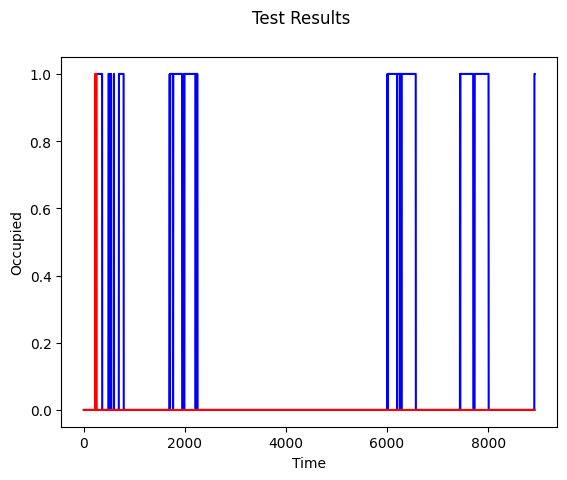

In [24]:
# put it all together for other models

# make a prediction
pred = model.predict(X_test)# the pred
print(pred) # round them!

pred = np.round(pred,0)
print(pred) # run all if you get an error...

# confusion matrix - put this at the top!
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
print(confusion_matrix(y_test, pred)) # looks pretty good!
print(classification_report(y_test, pred))

# show timeseries plot on the train and validation data
plt.plot(np.arange(X_test.shape[0]), y_test, color='blue') # actual data
plt.plot(np.arange(X_test.shape[0]), pred, color='red') # predicted data
plt.suptitle('Test Results')
plt.xlabel('Time')
plt.ylabel('Occupied')
plt.show()

## Save the model and use it again

Reproducibility means more than a seed: **save the fitted model** so you (or a teammate, or your future self) can reload it and predict without retraining. Keras 3 saves to a single `.keras` file. The reloaded model must give *identical* predictions - we check.

In [25]:
from keras.models import load_model

model.save('Multivariate_Occupancy_RNN_AdvancedTopics.keras')                 # one file: architecture + weights + optimizer state
reloaded = load_model('Multivariate_Occupancy_RNN_AdvancedTopics.keras')

# same inputs, same answers?
import numpy as np
same = np.allclose(model.predict(X_test[:5], verbose=0), reloaded.predict(X_test[:5], verbose=0))
print('reloaded model reproduces the predictions:', same)
reloaded.summary()

reloaded model reproduces the predictions: True


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 48, 128)        │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 24, 60)         │        38,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 20)             │         4,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 135,449 (529.10 KB)

 Trainable params: 45,149 (176.36 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 90,300 (352.74 KB)